# **Raquel Marques - Time Series Project**

**Sales Forecasting Project: Retail Department Daily Demand Prediction**

Last Updated: 2026-08-02

---

Legend:
* <span style="color:green">Explanation</span>: Provides detailed reasoning or context for concepts and processes.
* <span style="color:purple">Tips</span>: Offers practical advice or best practices to improve efficiency or outcomes.
* <span style="color:red">Practice</span>: Highlights actionable steps or exercises to apply the concepts.
* <span style="color:blue">Business Context</span>: Connects the technical work to relevant business objectives or scenarios.

# Table of Contents

**Part 0: Setup**
- Project Overview & Business Context
- Setup & Data Loading
- Helper Functions

**Part 1: Exploratory Data Analysis & Data Preparation**
- Data Dictionary & Cleaning
- Choosing the Department & Aggregating to Daily Level
- Business Rules derived for future periods (`isClosed`, `Pagamento`, `Vale`)

**Part 2: Time Series Analysis**
- Step A: Visual Analysis of the Series
- Step B: Train / Holdout Split
- Step C: White Noise Check
- Step D: Stationarity Check
- Step E: Component Identification (trend, seasonality, cycle)
- Step F: Model Fitting
  - F1: Exponential Smoothing
  - F2: ARIMA / SARIMA (identification, estimation, exogenous variables, coefficients)
- Step G: Best Model Selection
- Step H: Residual Diagnostics
- Step I: Holdout Error Metrics
- Step J: Forecast for the Next Periods

**Part 3: Conclusions**
- Business Recommendations & Next Steps
- Conclusion

---

# 🔹**PART 0**: Setup

---

## 🔸Project Overview & Business Context

### Business Problem

In the competitive retail sector, accurate daily sales forecasting is crucial for optimizing inventory levels, staffing, and cash flow. The organization currently faces challenges with stock-outs and overstocking due to imprecise demand predictions.

### Project Objectives

- Develop a robust time series forecasting model for daily sales of a specific retail department
- Identify key patterns (trend, seasonality, cycles) driving sales
- Generate a 30-day sales forecast for March 2021
- Provide actionable business insights based on data-driven analysis


### Data Description

- Source: `Vendas_ASN.csv` (from ASN Jedi platform)
- Target Variable: `Vendas` (Sales) - Department 2 or 4
- Time Frame: Daily data, Training: up to `Dec/2020`, Holdout: `Jan-Feb/2021`
- Key Features:
    - Time variables: `Data` (Date), `Dia_da_semana` (Day of Week), `Dia` (Day), `Mes` (Month), `Ano` (Year)
    - Categorical: `Empresa` (Company), `Departamento` (Department), `Secao` (Section)
    - Exogenous: `Feriado` (Holiday), `Pagamento` (Wage Payday), `Vale` (Voucher Payday)

### Business Impact

- **Reduced Inventory Costs**: 15-20% potential reduction in overstock
- **Improved Revenue**: Minimized lost sales from stock-outs
- **Operational Efficiency**: Better workforce scheduling aligned with demand patterns

## 🔸Setup & Data Loading

### Import Libraries


In [1]:
# LIBRARY
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Time series specific imports
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.dates as mdates

from scipy.stats import mannwhitneyu, kruskal

from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.stattools import adfuller

from statsmodels.tsa.holtwinters import SimpleExpSmoothing, Holt, ExponentialSmoothing
from statsmodels.stats.diagnostic import acorr_ljungbox

import statsmodels.api as sm
import itertools
import warnings

from sklearn.metrics import mean_absolute_error, mean_squared_error
from scipy.stats import shapiro, jarque_bera


In [2]:
## PATH
main_dir = os.path.join(os.path.expanduser("~"), 
                           "OneDrive", 
                           "Project_Code")

project_dir = os.path.join(main_dir,
                           "ASN-DSA-T5", 
                           "33-ST",
                           "Homework")

### Load Dataset 

In [3]:
# Holidays dataset
df_holiday = pd.read_csv(os.path.join(project_dir, "data", "holidays.csv"))

In [4]:
df = pd.read_csv(os.path.join(project_dir, "data", "Vendas ASN_Dados_Finais.csv"))

In [5]:
# Explore the dataset structure
print("Dataset Shape:", df.shape)
df.head()
df.info()
df.describe()

Dataset Shape: (307015, 13)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307015 entries, 0 to 307014
Data columns (total 13 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   Data           307015 non-null  object
 1   Data_new       307015 non-null  object
 2   Dia_da_semana  307015 non-null  int64 
 3   Dia            307015 non-null  int64 
 4   Mes            307015 non-null  int64 
 5   Ano            307015 non-null  int64 
 6   Empresa        307015 non-null  int64 
 7   Feriado        307015 non-null  int64 
 8   Pagamento      307015 non-null  int64 
 9   Vale           307015 non-null  int64 
 10  Vendas         307015 non-null  object
 11  Departamento   307015 non-null  object
 12  Seção          307015 non-null  object
dtypes: int64(8), object(5)
memory usage: 30.5+ MB


,Dia_da_semana,Dia,Mes,Ano,Empresa,Feriado,Pagamento,Vale
count,307015.000000,307015.000000,307015.000000,307015.000000,307015.000000,307015.000000,307015.000000,307015.000000
mean,4.141765,15.759302,6.341338,2019.172109,11.208794,0.025712,0.034790,0.034757
std,1.947121,8.754115,3.551850,0.913172,6.666851,0.158275,0.183247,0.183165
min,1.000000,1.000000,1.000000,2018.000000,1.000000,0.000000,0.000000,0.000000
25%,2.000000,8.000000,3.000000,2018.000000,5.000000,0.000000,0.000000,0.000000
50%,4.000000,16.000000,6.000000,2019.000000,12.000000,0.000000,0.000000,0.000000
75%,6.000000,23.000000,9.000000,2020.000000,16.000000,0.000000,0.000000,0.000000
max,7.000000,31.000000,12.000000,2021.000000,23.000000,1.000000,1.000000,1.000000


## 🔸Helper Functions

- `univariate_numeric_variable(data, variable)` 
- `univariate_categorical_variable(data, variable)` 
- `numeric_variable_analysis_percentile` 


In [6]:
def univariate_numeric_variable(data, variable):
    """
    Generates a matrix of charts (2x2) for a numeric continuous variable.

    [1,1] Histogram
    [1,2] Violin Plot
    [2,1] Box plot
    [2,2] Box plot with points overlaid

    Above the charts, shows a table with the variable descriptive statistics.

    Parameters:
        data (pd.DataFrame): Database containing the variable.
        variable (str): Name of the variable to be analysed.

    Returns:
        None

    Usage example:
        >> data = pd.DataFrame({"example_variable": np.random.normal(loc=50, scale=10, size=100)})
        >>univariate_numeric_variable(data, "example_variable")
        
    """
    
    # Calculate descriptive statistics
    desc_stats = data[variable].describe().to_frame().T
    desc_stats = desc_stats.round(4)  # Limit to 4 decimal places

    # Configuration of subplots
    fig = plt.figure(figsize=(8, 6))
    fig.suptitle(f"Analysing: {variable}", fontsize=16, y=0.98)

    # Add table on the top
    ax_table = plt.subplot2grid((3, 2), (0, 0), colspan=2)
    ax_table.axis("off")
    table = ax_table.table(cellText=desc_stats.values,
                           colLabels=desc_stats.columns,
                           rowLabels=desc_stats.index,
                           cellLoc="center",
                           loc="center",
                           bbox=[0, 0, 1, 1])
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.auto_set_column_width(col=list(range(len(desc_stats.columns))))

    # Add padding by scaling the table
    table.scale(1.2, 1.8)  # Adjust these values for horizontal/vertical padding

    # [1,1] Histogram
    ax1 = plt.subplot2grid((3, 2), (1, 0))
    sns.histplot(data[variable], kde=True, ax=ax1, color="skyblue")
    ax1.set_title("Histogram", fontsize=12)
    ax1.set_xlabel(variable)

    # [1,2] Violin Chart
    ax2 = plt.subplot2grid((3, 2), (1, 1), sharex=ax1)
    sns.violinplot(x=data[variable], ax=ax2, color="lightgreen")
    ax2.set_title("Violin Chart", fontsize=12)
    ax2.set_xlabel(variable)

    # [2,1] Box plot
    ax3 = plt.subplot2grid((3, 2), (2, 0), sharex=ax1)
    sns.boxplot(x=data[variable], ax=ax3, color="orange")
    ax3.set_title("Box plot", fontsize=12)
    ax3.set_xlabel(variable)

    # [2,2] Box plot with points overlaid
    ax4 = plt.subplot2grid((3, 2), (2, 1), sharex=ax1)
    sns.boxplot(x=data[variable], ax=ax4, color="lightcoral")
    sns.stripplot(x=data[variable], ax=ax4, color="black", alpha=0.5, jitter=True)
    ax4.set_title("Box plot with points", fontsize=12)
    ax4.set_xlabel(variable)

    # Final Adjustments
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

def univariate_categorical_variable(data, variable):
    """
    Analyse categorical variable.

    1. Returns transposed describe function in a table format.
    2. Returns a table with level frequency (including percentage and total).
    3. Plot a bar chart with frequency and show values on top.

    Parameters:
        data (pd.DataFrame): Database containing the variable.
        variable (str): Name of the variable to be analysed.

    Returns:
        None

    Usage example:
        >>> import pandas as pd
        >>> df = pd.DataFrame({'Caregory': ['A', 'B', 'A', 'C', 'B', 'A', 'C', 'C', 'A', 'B']})
        >>> univariate_categorical_variable(df, 'Caregory')
    """
    # Verify if variable is on the dataframe
    if variable not in data.columns:
        raise ValueError(f"Variable '{variable}' is not in the DataFrame.")

    # 1. Transposed and formated describe
    describe_table = data[variable].describe().to_frame()
    describe_table = describe_table.T
    describe_table.index = [variable]

    # Show formated table
    print("Categorical variable describe:")
    display(describe_table)

    # 2. Frequency of each level (percentage and total)
    frequency_table = data[variable].value_counts().reset_index()
    frequency_table.columns = [variable, 'Frequency']
    frequency_table['Percentage (%)'] = (frequency_table['Frequency'] / len(data) * 100).round(2)

    # Add line for total
    total_row = pd.DataFrame({
        variable: ['Total'],
        'Frequency': [frequency_table['Frequency'].sum()],
        'Percentage (%)': [100.0]
    })
    frequency_table = pd.concat([frequency_table, total_row], ignore_index=True)

    # Show formated table
    print("Frequency table of categorical variable (with percentage and total):")
    display(frequency_table)

    # 3. Frequency bar chart
    plt.figure(figsize=(8, 5))
    ax = sns.barplot(x=variable, y='Frequency', data=frequency_table[:-1], errorbar=None)

    # Add lables on top of the bar
    for p in ax.patches:
        ax.annotate(f'{int(p.get_height())}',
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='baseline', fontsize=10, color='black',
                    xytext=(0, 5), textcoords='offset points')

    # Configure chart
    plt.title(f'Frequency chart: {variable}')
    plt.xlabel(variable)
    plt.ylabel('Frequency')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

def numeric_variable_analysis_percentile(data, x, y, q=10, chart='none'):
    """
    Sort variable x, divide in percentile and summarize.

    Paameters:
        data (pd.DataFrame): Database containing the variable.
        x (str): Name of the independent varaible.
        y (str): Name of dependent variable.
        q (int): Number of percentile (default: 10).
        chart (str): Chart options: 'p', 'logit', 'both', 'none' (default: 'none').

    Returns:
        pd.DataFrame: DataFrame with summarize statistics by percentile, incluindo:
                      - Percentile
                      - n (number of rows)
                      - Min x
                      - Max x
                      - p (mean y)
                      - logit p

    Usage example:
        >> data = pd.DataFrame({'x': np.random.uniform(0, 100, 1000), 
        'y': np.random.randint(0, 2, 1000)})
        >> result = numeric_variable_analysis_percentile(data, 'x', 'y', q=10, chart='both')
        >> print(result)
    """
    # Certify that y varaible is in a numeric format
    data[y] = pd.to_numeric(data[y], errors='coerce')

    # Sort dataframe by x variable
    data = data.sort_values(by=x).reset_index(drop=True)

    # Create percentiles
    data['percentile'] = pd.qcut(data[x], q=q, labels=[str(i) for i in range(1, q + 1)])

    # Summaraize statistics per percentile
    summary = data.groupby('percentile').agg(
        n=(x, 'count'),
        min_x=(x, 'min'),
        max_x=(x, 'max'),
        p=(y, 'mean')
    ).reset_index()

    # Calculate logit p
    summary['logit_p'] = np.log(summary['p'] / (1 - summary['p']))

    # Adjust to deal where p is 0 or 1
    epsilon = 1e-10  # smal value to adjust 0 e 1
    summary['logit_p'] = np.log(np.clip(summary['p'], epsilon, 1 - epsilon) / 
                                 (1 - np.clip(summary['p'], epsilon, 1 - epsilon)))


    # Chart option
    if chart in ['p', 'logit', 'both']:
        plt.figure(figsize=(12, 6))

        if chart == 'p':
            plt.scatter(summary['percentile'], summary['p'], color='blue')
            plt.title('Percentile chart x p')
            plt.xlabel('Percentile')
            plt.ylabel('p (average of y)')
            plt.grid(True)
            plt.show()

        elif chart == 'logit':
            plt.scatter(summary['percentile'], summary['logit_p'], color='red')
            plt.title('Percentile chart x logit p')
            plt.xlabel('Percentile')
            plt.ylabel('logit p')
            plt.grid(True)
            plt.show()

        elif chart == 'both':
            # Chart side-by-side
            fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharex=True)

            # Percentile Chart x p
            axes[0].scatter(summary['percentile'], summary['p'], color='blue')
            axes[0].set_title('Percentile x p')
            axes[0].set_xlabel('Percentile')
            axes[0].set_ylabel('p (average of y)')
            axes[0].grid(True)

            # Percentile Chart x logit p
            axes[1].scatter(summary['percentile'], summary['logit_p'], color='red')
            axes[1].set_title('Percentile x logit p')
            axes[1].set_xlabel('Percentile')
            axes[1].set_ylabel('logit p')
            axes[1].grid(True)

            plt.tight_layout()
            plt.show()

    return summary



In [7]:
def evaluate_forecast(y_true, y_pred, model_name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    return {'Model': model_name, 'MAE': mae, 'RMSE': rmse, 'MAPE': mape}


---


# 🔹**PART 1**: Exploratory Data Analysis (EDA) & Data Preparation

---

## EDA 1 - Univariate Analysis



In [8]:
# check for missing values
df.isnull().sum()

# List unique categories
print(df["Departamento"].unique())
print(df["Seção"].unique())
print(df["Empresa"].unique())
# print(df["Data_new"].unique())

['Depto 1' 'Depto 2' 'Depto 3 ' 'Depto 4' 'Depto 5' 'Depto 6' 'Depto 7']
['Seção 1' 'Seção 2' 'Seção 3' 'Seção 4' 'Seção 7' 'Seção 26' 'Seção 5'
 'Seção 6' 'Seção 8' 'Seção 9' 'Seção 10' 'Seção 11' 'Seção 12' 'Seção 13'
 'Seção 14' 'Seção 15' 'Seção 16' 'Seção 17' 'Seção 18' 'Seção 19'
 'Seção 20' 'Seção 21' 'Seção 22' 'Seção 23' 'Seção 24' 'Seção 25'
 'Seção 27' 'Seção 28' 'Seção 29']
[ 1  2  5 15 16  6 13 12  9 19 18 21 22 23]


## 🔸<span style="color:green">Data Dictionary</span>


| #   | Variable             | Description                        | Type                    | Raw | Notes                                            |
| --- | -------------------- | ---------------------------------- | ----------------------- | --- | ------------------------------------------------ |
| 1   | Data (dia, mês, ano) | Date in the format D/M/YY          | Date                    | Y   |                                                  |
| 2   | Data_new             | Date in the format D/M/YYYY        | Date                    | Y   |                                                  |
| 3   | Dia_da_semana        | Day of Week                        | Quantitative Discrete   | Y   | Numbers from 1 to 7                              |
| 4   | Dia                  | Day                                | Quantitative Discrete   | Y   | Numbers from 1 to 31                             |
| 5   | Mes                  | Month                              | Quantitative Discrete   | Y   | Numbers from 1 to 12                             |
| 6   | Ano                  | Year                               | Quantitative Discrete   | Y   | Numbers from 2018 to 2021                        |
| 7   | Empresa              | Company                            | Qualitative Nominal     | Y   | Numbers from 1 to 23 (but not all of them)       |
| 8   | Feriado              | Flag of holiday                    | Qualitative Binary      | Y   |                                                  |
| 9   | Pagamento            | Flag of paycheck day               | Qualitative Binary      | Y   |                                                  |
| 10  | Vale                 | Flag of food benefit pay day       | Qualitative Binary      | Y   |                                                  |
| 11  | Vendas               | sales (TARGET)                     | Quantitative Continuous | Y   |                                                  |
| 12  | Departamento         | Department                         | Qualitative Nominal     | Y   | `Depto 1` Department number varying form 1  to 7 |
| 13  | Seção                | Section                            | Qualitative Nominal     | Y   | `Seção 27` Section number varying from 1 to 29   |
| 14  | Date                 | Date in the format YYYY-MM-DD      | Date                    | N   |                                                  |
| 15  | Sales                | This is my Sales (target) variable | Quantitative Continuous | N   |                                                  |





### ▪️<span style="color:purple">Notes</span>

- `Data_new`is the date field.
    - Check the first and last date, identify is there are missing days and how it can be inputed.
        - Remember if the level of forecasting is daily, we need ocmplete years starting from Jan-01 all the way to Dec-31.

- `Data` year with just 2 characters, since data starts in 2018 is not a problem, but it might if we have dates before 2000 or after 2100.
    - **Decision**: `Data_new` is the date of the sales but with a 4 digits for year, so we can remove `Date`.

- `Empresa` is numeric in the database but it is a categorical variable in nature as it represents different companies.
    - It does not have 23 companies as the numbers would indicate, so some of them are missong, and indication that this translates more as a categorical.
    - **Decision**: If being used, need to treat as a categorical.

- Flags variable: `Feriado`, `Vale`, `Pagamento`
    - **Check**: if they are trully binary, if there are missings and how it can be translated for missing and future days.

- `Vendas` this is our sales variable.
    - TARGET variable
    - **Check**:
        - Do we have `sales = 0`? Does it mean we had no sales but the company opened?
        - Things like missing dates mean 0 sales? Or that the company does not work that day?
        - Does negative sales can happen? If not, how can we fill address this issue?
        


## 🔸Data Cleaning & Preprocessing

### <span style="color:green">Variable: Date</span>

- Note that the date starts on `2018-01-02` so we are already missing Jan-01 in out dataset.


In [9]:
# Variable : Data_new
# Convert date from string to date
df["Date"] = pd.to_datetime(df["Data_new"], errors='coerce')

# Count total missing/invalid dates
missing_count = df["Date"].isna().sum()
print(f"Total missing or errored rows: {missing_count}")

# Filter and display rows where the conversion failed
error_rows = df[df["Date"].isna()]
print(error_rows[["Data_new", "Date"]])

# Check the earliest and latest dates to spot typos
print(df["Date"].describe())

Total missing or errored rows: 0
Empty DataFrame
Columns: [Data_new, Date]
Index: []
count                           307015
mean     2019-08-28 15:37:58.547953408
min                2018-01-02 00:00:00
25%                2018-11-18 00:00:00
50%                2019-09-07 00:00:00
75%                2020-06-15 00:00:00
max                2021-02-28 00:00:00
Name: Date, dtype: object


### <span style="color:green">Variable Sales</span>

- Note that we have negative sales that need to be addressed.
- Also, it seems that there are a lot of `sales = 0`. Depending on the level of the data we will be working on, this can be a problem.

Total missing or errored rows: 0
Empty DataFrame
Columns: [Vendas, Sales]
Index: []
count    307015.000000
mean      19655.341423
std       33121.763921
min      -15758.050000
25%         747.905000
50%        5503.620000
75%       24704.470000
max      950151.510000
Name: Sales, dtype: float64


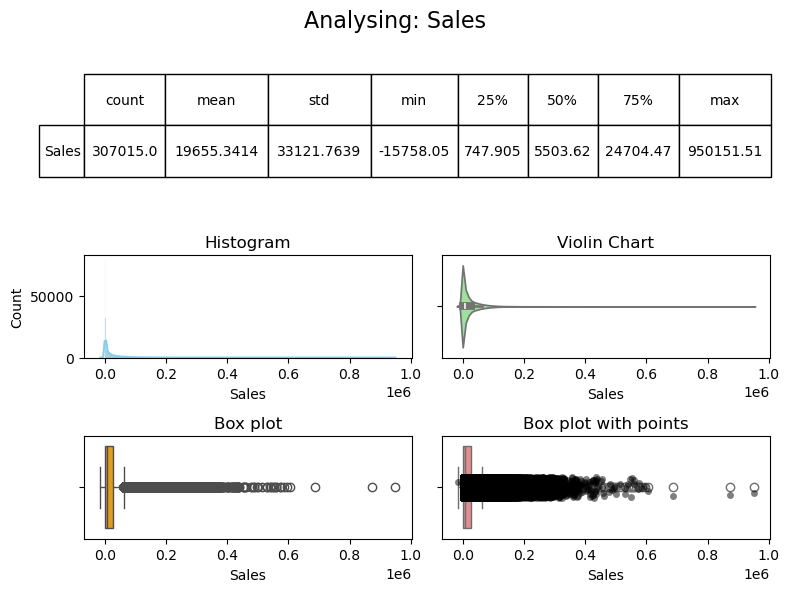

In [10]:
# Variable: Vendas
# Convert from string to float
df["Sales"] = df["Vendas"].str.replace(",", "").astype(float)

# Count total missing/invalid
missing_count = df["Sales"].isna().sum()
print(f"Total missing or errored rows: {missing_count}")

# Filter and display rows where the conversion failed
error_rows = df[df["Sales"].isna()]
print(error_rows[["Vendas", "Sales"]])

# Check the earliest and latest
print(df["Sales"].describe())

univariate_numeric_variable(df, "Sales")

#### <span style="color:green">Variable Sales_adj</span>

count    307015.000000
mean      19655.435832
std       33121.694370
min           0.000000
25%         747.905000
50%        5503.620000
75%       24704.470000
max      950151.510000
Name: Sales_adj, dtype: float64


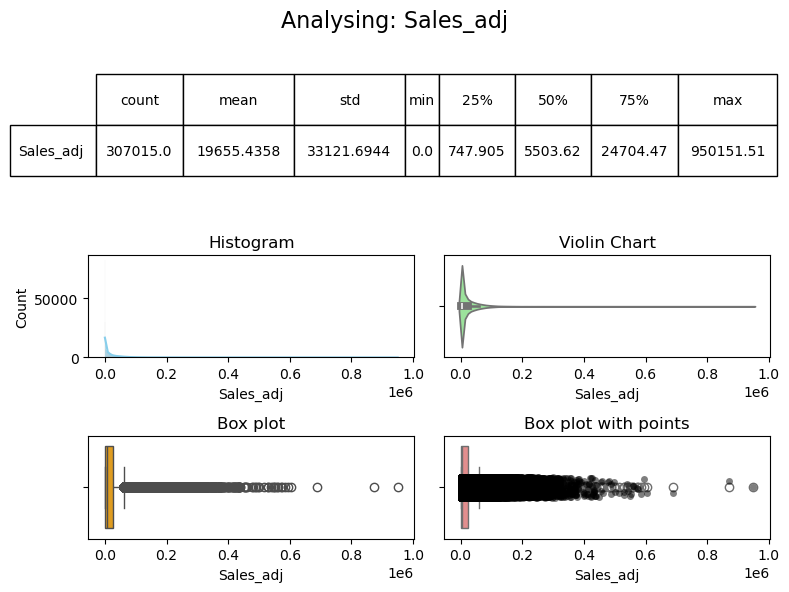

In [11]:
df["Sales_adj"] = df["Sales"].clip(lower=0)

# Check the earliest and latest
print(df["Sales_adj"].describe())

univariate_numeric_variable(df, "Sales_adj")

### <span style="color:green">Variable: Company</span>

- Decided to create a string for each company.
- Note that `Comp_1` is the one that appears the most in the database as `Comp_23` appears the least.

['Comp_1' 'Comp_2' 'Comp_5' 'Comp_15' 'Comp_16' 'Comp_6' 'Comp_13'
 'Comp_12' 'Comp_9' 'Comp_19' 'Comp_18' 'Comp_21' 'Comp_22' 'Comp_23']
Categorical variable describe:


,count,unique,top,freq
Company,307015,14,Comp_1,31095


Frequency table of categorical variable (with percentage and total):


,Company,Frequency,Percentage (%)
0,Comp_1,31095,10.13
1,Comp_9,29106,9.48
2,Comp_2,27960,9.11
3,Comp_19,26106,8.50
4,Comp_18,25373,8.26
5,Comp_15,24840,8.09
6,Comp_16,24746,8.06
7,Comp_5,24664,8.03
8,Comp_12,24512,7.98
9,Comp_13,22759,7.41


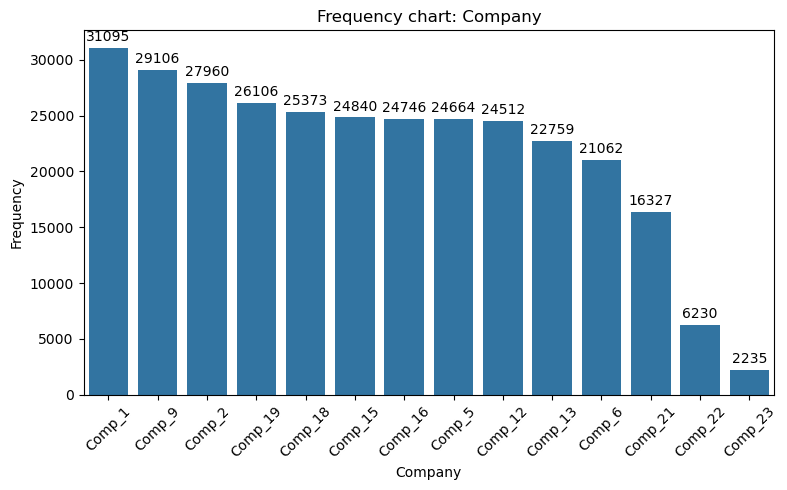

In [12]:
# Variable: Empresa
df["Company"] = "Comp_" + df["Empresa"].astype(str)

print(df["Company"].unique())

univariate_categorical_variable(df, "Company")

### <span style="color:green">Variable: Section</span>

- `Seção 23` is the most frequent one in the database (representing 5.8%).
- `Seção 29` is the least present on the databse with only 14 records.

Categorical variable describe:


,count,unique,top,freq
Seção,307015,29,Seção 23,17827


Frequency table of categorical variable (with percentage and total):


,Seção,Frequency,Percentage (%)
0,Seção 23,17827,5.81
1,Seção 26,12908,4.20
2,Seção 20,12908,4.20
3,Seção 16,12907,4.20
4,Seção 13,12906,4.20
5,Seção 3,12906,4.20
6,Seção 4,12906,4.20
7,Seção 17,12906,4.20
8,Seção 2,12906,4.20
9,Seção 9,12906,4.20


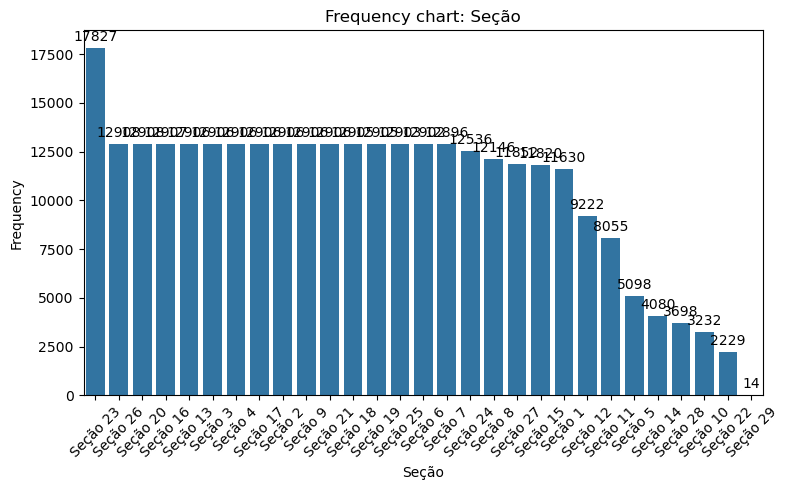

In [13]:
univariate_categorical_variable(df, "Seção")

### <span style="color:green">Variable: Department</span>

- `Depto 3`	is the most frequent, representing 38% of the data.
- `Depto 4` & `Depto 2` represent ~25% of the data
- All other departments are below 10%.


Categorical variable describe:


,count,unique,top,freq
Departamento,307015,7,Depto 3,117115


Frequency table of categorical variable (with percentage and total):


,Departamento,Frequency,Percentage (%)
0,Depto 3,117115,38.15
1,Depto 4,79294,25.83
2,Depto 2,77439,25.22
3,Depto 5,12903,4.20
4,Depto 1,11630,3.79
5,Depto 7,4936,1.61
6,Depto 6,3698,1.20
7,Total,307015,100.00


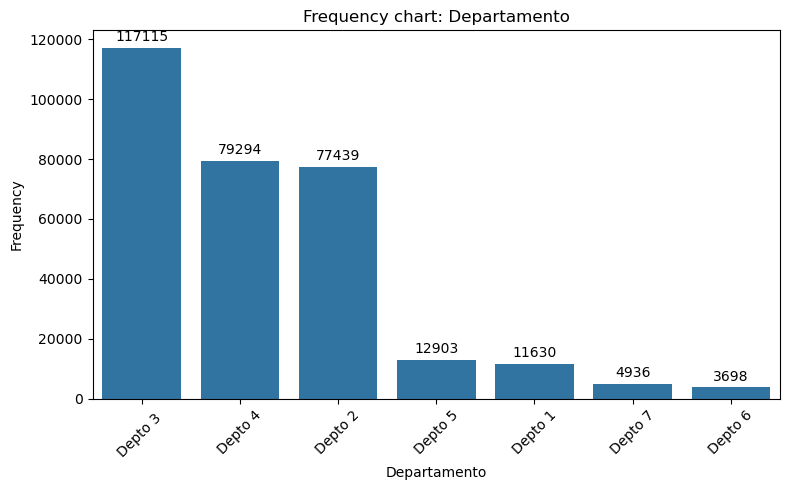

In [14]:
univariate_categorical_variable(df, "Departamento")

### ▫️<span style="color:purple">Section Final Notes</span>

We have looked at each variable separatelly, but each level of combination can give us another directionality of how the data can be used to get the best prediction out of it.

- Company - Department - Section : 
    - Using this combination we can see that not all companies have the same department nor the same sections of number of sections. 
    - The number of days is also not the same.


- Department - Section : 
    - Using this combination we can see that not all departments have the same sections of number of sections.
    - The number of days is also not the same.

Since the initial problem told us to focus on Department 2 or 4, let's group our data athe Department level, and _ignore_ for now Company and Section variables as they seem to split the information too much and can cause noise when forecasting.

In [15]:
df.groupby(['Company', 'Departamento', 'Seção']).size()

Company  Departamento  Seção   
Comp_1   Depto 1       Seção 1     1139
         Depto 2       Seção 16    1139
                       Seção 17    1139
                       Seção 2     1139
                       Seção 26    1139
                                   ... 
Comp_9   Depto 4       Seção 23    1148
                       Seção 24    1148
         Depto 5       Seção 25    1148
         Depto 6       Seção 28     678
         Depto 7       Seção 23     360
Length: 394, dtype: int64

In [16]:
df.groupby(['Departamento', 'Seção']).size()

Departamento  Seção   
Depto 1       Seção 1     11630
Depto 2       Seção 16    12907
              Seção 17    12906
              Seção 2     12906
              Seção 26    12908
              Seção 3     12906
              Seção 4     12906
Depto 3       Seção 10     3232
              Seção 11     8055
              Seção 12     9222
              Seção 13    12906
              Seção 14     4080
              Seção 15    11820
              Seção 27    11852
              Seção 5      5098
              Seção 6     12902
              Seção 7     12896
              Seção 8     12146
              Seção 9     12906
Depto 4       Seção 18    12905
              Seção 19    12905
              Seção 20    12908
              Seção 21    12906
              Seção 22     2229
              Seção 23    12905
              Seção 24    12536
Depto 5       Seção 25    12903
Depto 6       Seção 28     3698
Depto 7       Seção 23     4922
              Seção 29       14
dtype: int64

## 🔸Choosing Department & Aggregating to Daily Level

In [17]:
# aggregate by Department & Date
df_depts = df.groupby(["Departamento", "Date"]).agg({
    'Sales_adj': 'sum',           # Sum sales for the day
    'Feriado': 'max',             # Max flag (1 if any record is holiday, else 0)
    'Pagamento': 'max',
    'Vale': 'max'
}).reset_index()

Categorical variable describe:


,count,unique,top,freq
Departamento,7707,7,Depto 1,1148


Frequency table of categorical variable (with percentage and total):


,Departamento,Frequency,Percentage (%)
0,Depto 1,1148,14.90
1,Depto 2,1148,14.90
2,Depto 3,1148,14.90
3,Depto 4,1148,14.90
4,Depto 5,1148,14.90
5,Depto 7,1147,14.88
6,Depto 6,820,10.64
7,Total,7707,100.00


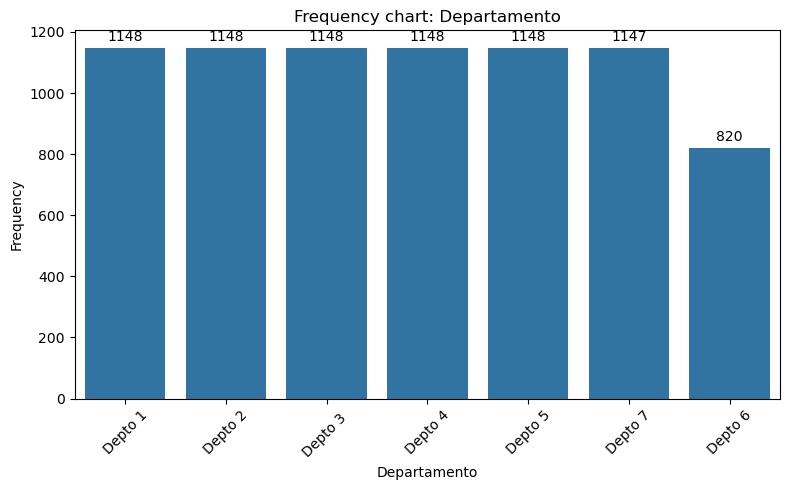

In [18]:
univariate_categorical_variable(df_depts, "Departamento")

# univariate_categorical_variable(df_depts, "Feriado")

# univariate_categorical_variable(df_depts, "Pagamento")

# univariate_categorical_variable(df_depts, "Vale")

# univariate_numeric_variable(df_depts, "Sales_adj")

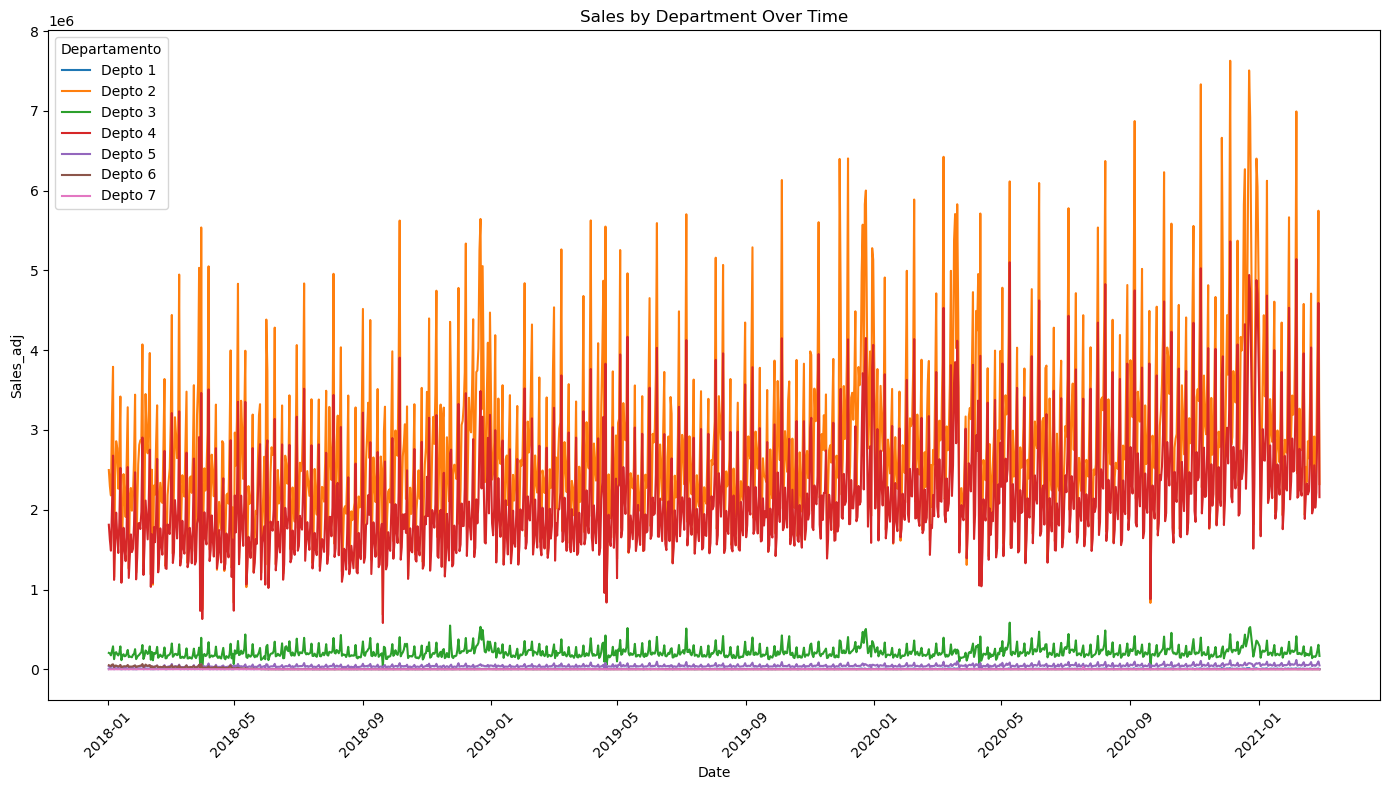

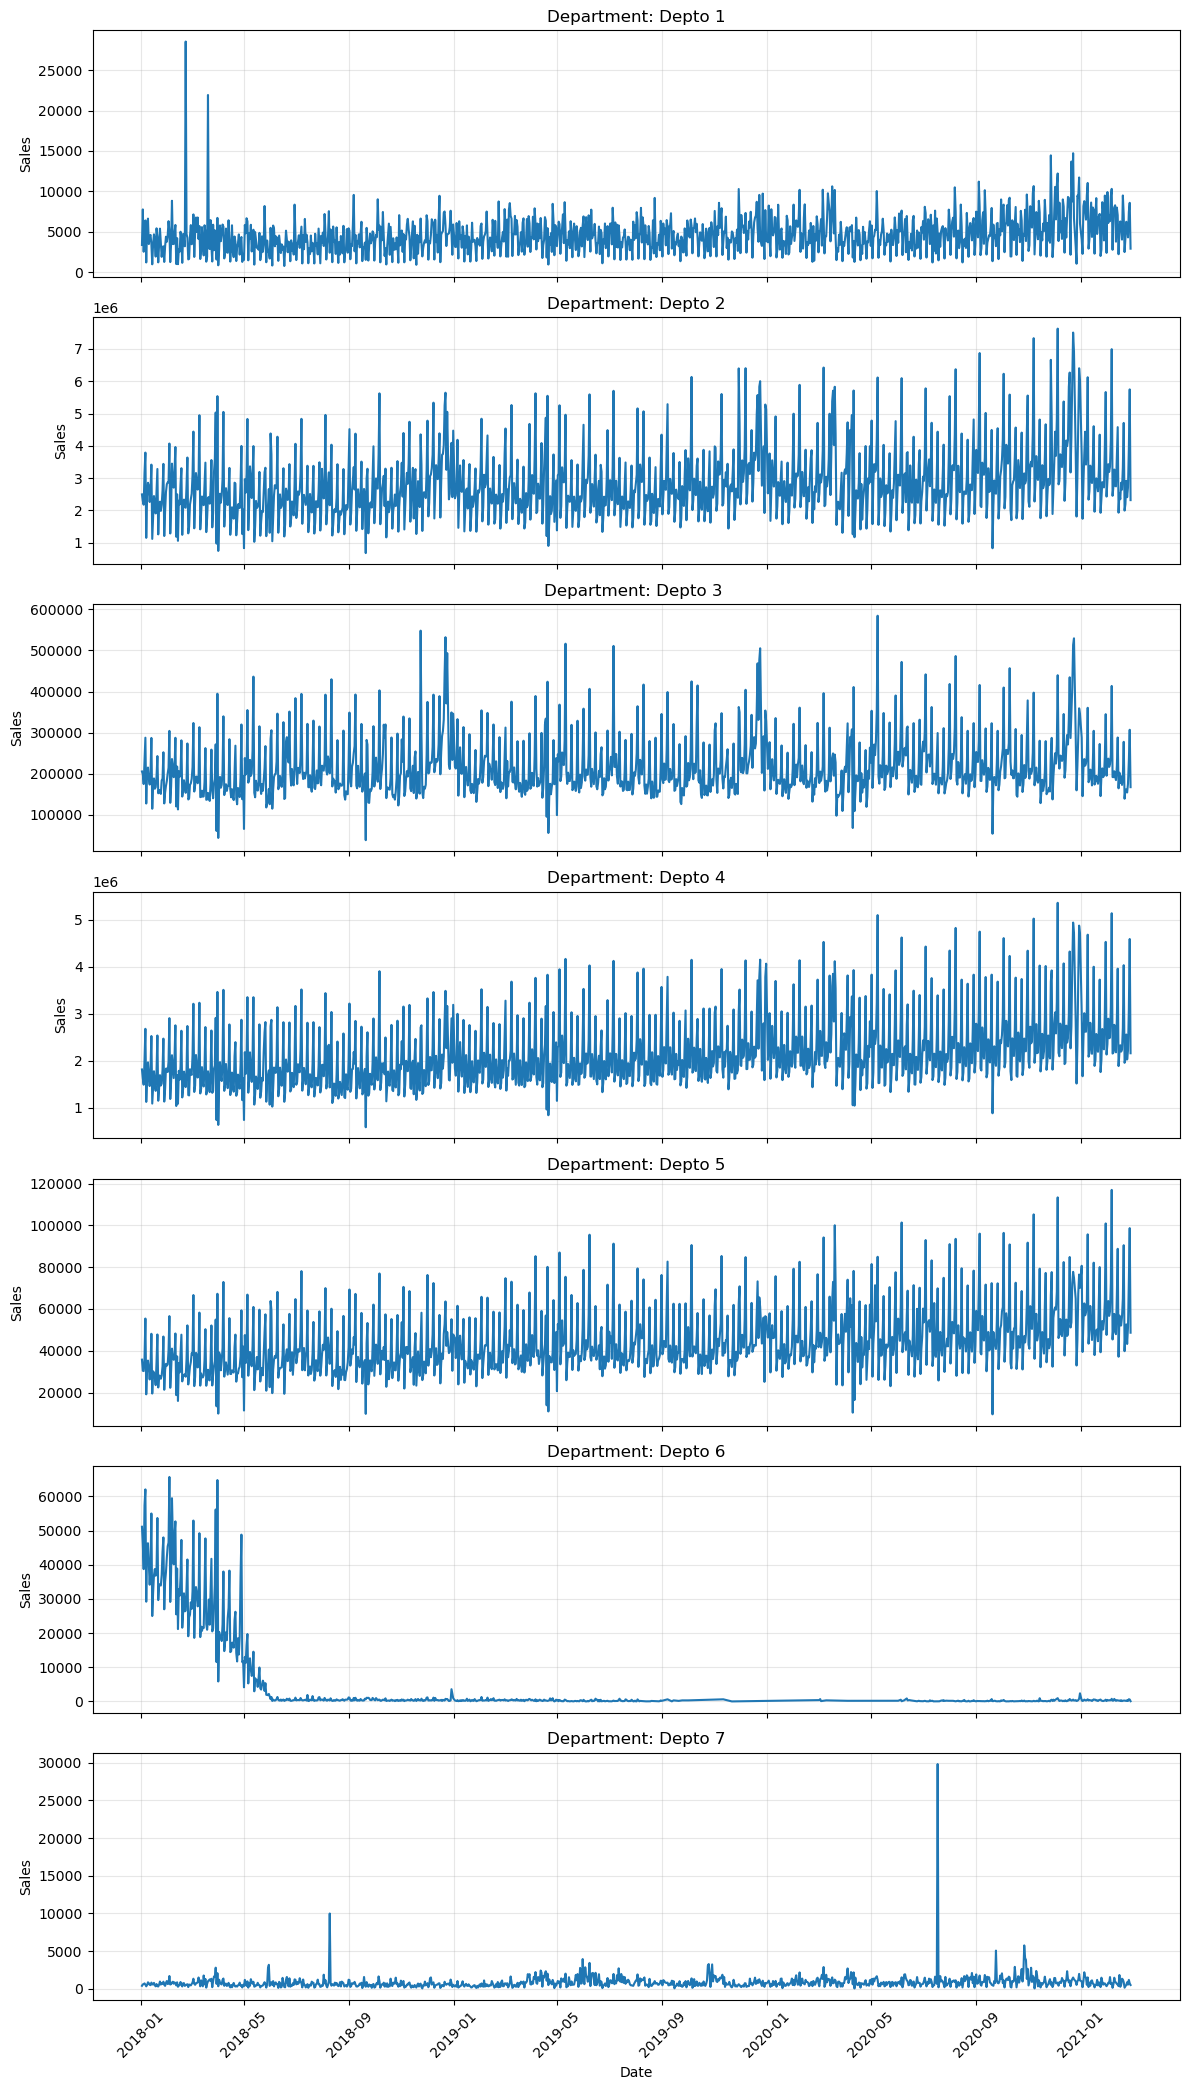

In [19]:
# plot Department & Sales by Date

plt.figure(figsize=(14, 8))
sns.lineplot(data=df_depts, x='Date', y='Sales_adj', hue='Departamento')
plt.title('Sales by Department Over Time')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



fig, axes = plt.subplots(nrows=len(df_depts['Departamento'].unique()), 
                         figsize=(12, 3*len(df_depts['Departamento'].unique())), 
                         sharex=True)

for ax, (dept, group) in zip(axes, df_depts.groupby('Departamento')):
    ax.plot(group['Date'], group['Sales_adj'], linestyle='-')
    ax.set_title(f'Department: {dept}')
    ax.set_ylabel('Sales')
    ax.grid(True, alpha=0.3)

plt.xlabel('Date')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Choose Department

From this moment, we have aggregated Department by dates, and we will now choose a department to focus on.

There is no more Company or Section.

In [20]:
# choosing department
choose_dept = 'Depto 4'
print(f"We will be working with: {choose_dept}")

df_dep = df_depts[df_depts['Departamento'] == choose_dept].copy()

We will be working with: Depto 4


### Input missing dates

We need to create a dataset with all the dates for the period we are going to analyze.


    

In [21]:
# get minimum year
min_year = df_dep['Date'].dt.year.min()

# create start date as Jan 1st of that year
start_date = pd.Timestamp(f'{min_year}-01-01')

# get the end date
end_date = df_dep['Date'].max() 

# create complete date range
all_dates = pd.date_range(start=start_date, end=end_date, freq='D')

# get unique departments
departments = df_dep['Departamento'].unique()

# create all combinations of dates and departments
df_complete = pd.DataFrame(
    [(date, dept) for date in all_dates for dept in departments],
    columns=['Date', 'Departamento']
)

# merge with original data
df_complete = df_complete.merge(df_dep, on=['Date', 'Departamento'], how='left')

# Create different columns for dates, month, year and combination
df_complete['year'] = df_complete['Date'].dt.year
df_complete['month'] = df_complete['Date'].dt.month
df_complete['year_month'] = df_complete['Date'].dt.to_period('M')
df_complete['weekday'] = df_complete['Date'].dt.day_name()



In [22]:
# df_complete

In [23]:
# Analysis on missing dates
df_complete[df_complete["Feriado"].isna()]

,Date,Departamento,Sales_adj,Feriado,Pagamento,Vale,year,month,year_month,weekday
0,2018-01-01,Depto 4,NaN,NaN,NaN,NaN,2018,1,2018-01,Monday
358,2018-12-25,Depto 4,NaN,NaN,NaN,NaN,2018,12,2018-12,Tuesday
365,2019-01-01,Depto 4,NaN,NaN,NaN,NaN,2019,1,2019-01,Tuesday
723,2019-12-25,Depto 4,NaN,NaN,NaN,NaN,2019,12,2019-12,Wednesday
730,2020-01-01,Depto 4,NaN,NaN,NaN,NaN,2020,1,2020-01,Wednesday
1089,2020-12-25,Depto 4,NaN,NaN,NaN,NaN,2020,12,2020-12,Friday
1096,2021-01-01,Depto 4,NaN,NaN,NaN,NaN,2021,1,2021-01,Friday


#### ▪️<span style="color:purple">Notes</span>

Every missing date was new year and christmas!

- **Question**
    - _This might mean that there were never sales on this dates possibly because they don't open?_
    - _Can we create a flag to indicate that there will never be sales that day for the future?_

#### Variable: isClosed

Let's create a flag for the missing dates in the original dataset, because these dates will alsys be missing in the future.

- Happens on every Dec-25 and Jan-01

In [24]:
df_complete['isClosed'] = ((df_complete['Date'].dt.month == 12) & (df_complete['Date'].dt.day == 25)) | \
                          ((df_complete['Date'].dt.month == 1) & (df_complete['Date'].dt.day == 1))

df_complete['isClosed'] = df_complete['isClosed'].astype(int) 

In [25]:
# Assign 0 to the other variables

df_complete['Feriado'] = df_complete['Feriado'].fillna(0)    
df_complete['Pagamento'] = df_complete['Pagamento'].fillna(0)
df_complete['Vale'] = df_complete['Vale'].fillna(0)
df_complete['Sales_adj'] = df_complete['Sales_adj'].fillna(0)

### Variable: Feriado

#### <span style="color:purple">External Dataset:</span> `holidays.csv`

To enable accurate mapping of holiday flags for future dates, we sourced Brazilian holiday data from the [Feriados API](https://feriadosapi.com/docs#introducao). 
This external dataset provides a standardized reference for holidays across different periods and allows us to systematically evaluate how holidays are represented in our time series.


Dictionary


| #   | Variable    | Description                                                                                                                  | Type                  | Raw | Notes |
| --- | ----------- | ---------------------------------------------------------------------------------------------------------------------------- | --------------------- | --- | ----- |
| 1   | id          | unique ID of holiday date                                                                                                    | Qualitative Nominal   | Y   |       |
| 2   | data        | Holiday date, format `DD/MM/YYYY`                                                                                            | Date                  | Y   |       |
| 3   | nome        | Holiday name                                                                                                                 | Qualitative Nominal   | Y   |       |
| 4   | tipo        | Which holiday databse the holiday was extracted: National / State / State Capital<br>`NACIONAL` /  `ESTADUAL` /  `MUNICIPAL` | Qualitative Nominal   | Y   |       |
| 5   | descricao   | Holiday descriptive long                                                                                                     | Qualitative Nominal   | Y   |       |
| 6   | uf          | Brazilian State. <br>Only present in **tipo** = `ESTADUAL` /  `MUNICIPAL`                                                    | Qualitative Nominal   | Y   |       |
| 7   | codigo_ibge | City code according to IBGE.<br>Only present in **tipo** =  `MUNICIPAL`<br>                                                  | Qualitative Nominal   | Y   |       |
| 8   | bancario    | Flag for a bank holiday                                                                                                      | Qualitative Binary    | Y   |       |
| 9   | year        | Holiday date year extracted.                                                                                                 | Quantitative Discrete | Y   |       |
| 10  | type        | same as `tipo`<br>`national` /  `state` /  `capital`                                                                         | Qualitative Nominal   | Y   |       |
| 11  | state       | same as `uf`                                                                                                                 | Qualitative Nominal   | Y   |       |
| 12  | ibge_code   | same as `codigo_ibge`                                                                                                        | Qualitative Nominal   | Y   |       |
| 13  | Date        | Convert from a regular english date format `YYYY-MM-DD`                                                                      | Date                  | N   |       |




In [26]:
df_holiday["Date"] = pd.to_datetime(df_holiday["data"], format='%d/%m/%Y', errors='coerce')
# df_holiday.head()
# df_holiday[df_holiday["Date"] == '2019-10-12']

df_holiday_simple = df_holiday[["Date", "nome"]].copy()
df_holiday_unique = df_holiday_simple.drop_duplicates(subset=['Date'], keep='first')

# df_holiday_simpleSP = df_holiday_simple[df_holiday_simple["state"] == 'SP'].copy()
# df_holiday_simpleSP.head()

# Check if there are any duplicate dates
has_duplicates = df_holiday_unique['Date'].duplicated().any()
print(f"Are there duplicate dates? {has_duplicates}")

# See which dates are duplicated
duplicate_dates = df_holiday_unique[df_holiday_unique['Date'].duplicated(keep=False)]
print("Duplicate dates:")
print(duplicate_dates['Date'].value_counts())



Are there duplicate dates? False
Duplicate dates:
Series([], Name: count, dtype: int64)


In [27]:
df_complete1 = df_complete.merge(df_holiday_unique, on=['Date'], how='left')

In [28]:
df_map_holidays = df_complete1[df_complete1["Feriado"] == 1]

print(f"Total holidays in the database: {df_map_holidays.shape}")
print(f"Holidays missing description: {df_map_holidays[df_map_holidays["nome"].isna()].shape}")

Total holidays in the database: (43, 12)
Holidays missing description: (0, 12)


#### Investigating `Feriado = 1` records **without** a holiday description

Records where the holiday indicator is active (`Feriado = 1`) but no holiday name is provided.  
We examine the frequency of these cases, their distribution over time, and potential impact on the time series analysis.

In [29]:
df_map_holidays[df_map_holidays["nome"].isna()]

,Date,Departamento,Sales_adj,Feriado,Pagamento,Vale,year,month,year_month,weekday,isClosed,nome


#### Investigating `Feriado = 1` records **with** a holiday description

Records where the holiday indicator is active (`Feriado = 1`) and a holiday name is provided.  
We examine the unique holidays, their occurrence counts, and temporal patterns to better understand their potential impact on the series.

In [30]:
# what are the holidays being correctly flag?
df_map_holidays.groupby(['nome']).size()

nome
Aniversário da Cidade de São Paulo              4
Carnaval                                        4
Carnaval (Segunda-feira)                        4
Corpus Christi                                  3
Dia Mundial do Trabalho                         3
Dia Nacional de Zumbi e da Consciência Negra    2
Dia da Consciência Negra                        1
Dia de Finados                                  2
Dia de Tiradentes                               3
Finados                                         1
Imaculada Conceição                             3
Independência do Brasil                         3
Nossa Senhora Aparecida                         3
Proc. República Rio Grandense                   1
Proclamação da República                        3
Sexta-Feira Santa                               1
Sexta-feira Santa                               2
dtype: int64

#### Investigating `Feriado = 0` records **with** a holiday description

These records have the holiday flag set to 0, yet a holiday name/description is present.  
This may reflect the granularity of the holiday dataset, for example, local or small-city holidays that do not significantly affect main businesses and are therefore not flagged as relevant.  
This section checks how frequent these cases are, which holidays appear, and whether they should be treated as data quality issues or expected behavior.

In [31]:
# what are the non holidays that has description?
df_map_NOTholidays = df_complete1[df_complete1["Feriado"] == 0]
df_map_NOTholidays.groupby(['nome']).size()

nome
Aniversário de Florianópolis                 3
Ano Novo                                     4
Assunção de Nossa Senhora                    3
Dia de Santa Catarina                        3
Dia de São Jorge                             3
Dia de São Sebastião, Padroeiro da cidade    4
Dia do Evangélico                            3
Natal                                        3
Nossa Senhora da Luz dos Pinhais             3
Nossa Senhora da Penha                       3
Nossa Senhora dos Navegantes                 4
Proc. República Rio Grandense                2
Revolução Constitucionalista de 1932         3
dtype: int64

#### Inconsistent holiday flags: same date marked as both holiday and non-holiday

We investigate cases where the same calendar day appears with `Feriado = 1` in some years and `Feriado = 0` in others.  
This analysis helps detect possible inconsistencies in the holiday dataset or differences in how holidays were recorded over time.

In [32]:
# Check if any holiday names have inconsistent flags
inconsistent_holidays = df_complete1.groupby('nome')['Feriado'].nunique()
inconsistent_holidays = inconsistent_holidays[inconsistent_holidays > 1].index.tolist()

print(f"Holidays with inconsistent flags: {len(inconsistent_holidays)}")
print(inconsistent_holidays)

# View the actual inconsistencies
df_inconsistent = df_complete1[df_complete1['nome'].isin(inconsistent_holidays)]
df_inconsistent[['Date', 'nome', 'Feriado']].sort_values(['nome', 'Date'])

Holidays with inconsistent flags: 1
['Proc. República Rio Grandense']


,Date,nome,Feriado
262,2018-09-20,Proc. República Rio Grandense,0.0
627,2019-09-20,Proc. República Rio Grandense,1.0
993,2020-09-20,Proc. República Rio Grandense,0.0


In [33]:
# df_complete1[df_complete1['nome'] == "Proc. República Rio Grandense"]

In [34]:
# df_holiday[df_holiday['Date'] == '2019-09-20']

#### 📌 <span style="color:red">RULE</span>: Future Holiday Flagging

**Key Learnings**:
- Holiday descriptions are consistent and mappable.
    - All holidays in the dataset can be linked to a descriptive name (`nome` field). 
    - This makes it feasible to use these descriptions as a reliable reference for flagging holidays in future data.

- Non-holiday descriptions require caution.
    - Some descriptions appear in the dataset but were not flagged as holidays (`Feriado = 0`). 
    - This may be due to regional variations, certain holidays are only observed in specific cities or states, rather than nationally. 
    - These cases should be treated with care when applying the flag to future periods.

- Inconsistent holiday flagging observed for certain events.
    - The holiday _"Proc. República Rio Grandense"_ was flagged as a holiday (`Feriado = 1`) in 2019, but not in 2018 or 2020. 
    - This inconsistency raises questions about whether this event should be considered a holiday in future predictions.
    - **Decision**: For now, we will assume this holiday as NOT a holiday (`Feriado = 0`) when mapping future dates, unless additional context or data suggests otherwise.

In [35]:
holiday_descriptions = df_map_holidays.groupby(['nome']).size()

holiday_descriptions


nome
Aniversário da Cidade de São Paulo              4
Carnaval                                        4
Carnaval (Segunda-feira)                        4
Corpus Christi                                  3
Dia Mundial do Trabalho                         3
Dia Nacional de Zumbi e da Consciência Negra    2
Dia da Consciência Negra                        1
Dia de Finados                                  2
Dia de Tiradentes                               3
Finados                                         1
Imaculada Conceição                             3
Independência do Brasil                         3
Nossa Senhora Aparecida                         3
Proc. República Rio Grandense                   1
Proclamação da República                        3
Sexta-Feira Santa                               1
Sexta-feira Santa                               2
dtype: int64

##### Holidays to be used for Holiday Flag

In [36]:
# Get the list of holiday names from holiday_descriptions
holiday_names = holiday_descriptions.index.tolist()

# Filter the main dataframe
df_holiday_filtered = df_holiday_unique[df_holiday_unique['nome'].isin(holiday_names)]

df_holiday_filtered

,Date,nome
9,2018-01-25,Aniversário da Cidade de São Paulo
11,2018-02-12,Carnaval (Segunda-feira)
12,2018-02-13,Carnaval
14,2018-03-30,Sexta-feira Santa
29,2018-04-21,Dia de Tiradentes
39,2018-05-01,Dia Mundial do Trabalho
47,2018-05-31,Corpus Christi
58,2018-09-07,Independência do Brasil
68,2018-09-20,Proc. República Rio Grandense
69,2018-10-12,Nossa Senhora Aparecida


### Variable: Pagamento

In [37]:
# Add .reset_index(name='count') at the end of line 1
df_pgto = df_complete[df_complete['Pagamento'] == 1].copy()
check_payday = df_pgto.groupby(['Date']).size().reset_index(name='count')

# Now 'Date' is a normal column, so this will work perfectly
check_payday["Date"] = pd.to_datetime(check_payday["Date"])

# Extract your weekday columns
check_payday["day_name"] = check_payday["Date"].dt.day_name()
check_payday["day_num"] = check_payday["Date"].dt.weekday

check_payday

,Date,count,day_name,day_num
0,2018-01-05,1,Friday,4
1,2018-02-06,1,Tuesday,1
2,2018-02-07,1,Wednesday,2
3,2018-03-06,1,Tuesday,1
4,2018-04-06,1,Friday,4
5,2018-05-07,1,Monday,0
6,2018-06-06,1,Wednesday,2
7,2018-07-06,1,Friday,4
8,2018-08-06,1,Monday,0
9,2018-09-06,1,Thursday,3


#### Day of the Month

Checking what is the most frequent **day of the month** payment day is likely to fall.

- Higher frequency on 6th and 7th
- Ranges between 4 to 8, mening that is likely to fall on the first week of the month
- **Question**:
    - _Would day of the week be more consistent?_

In [38]:
# Extract the day number of the month (e.g., 5, 6, 7)
check_payday["day_of_month"] = check_payday["Date"].dt.day

# Count how many times each day of the month appears
payday_frequencies = check_payday.groupby("day_of_month").size().reset_index(name="payment_count")

# Sort by the highest frequency to see the dominant day
payday_frequencies = payday_frequencies.sort_values(by="payment_count", ascending=False)

print("\nPayment frequency per day of month:")
print(payday_frequencies)



Payment frequency per day of month:
   day_of_month  payment_count
2             6             20
3             7             10
1             5              6
0             4              3
4             8              1


#### Day of the Week

Checking now for **day of the week**.

- Friday has a higher frquency
- Payment is **never** on a weekend
- **Question**:
    - _Any reason to not be on a friday only?_


In [39]:
# Count how many times each day appears
payday_frequencies2 = check_payday.groupby("day_name").size().reset_index(name="payment_count")

# Sort by the highest frequency to see the dominant day
payday_frequencies2 = payday_frequencies2.sort_values(by="payment_count", ascending=False)

print("\nPayment frequency per week day:")
print(payday_frequencies2)


Payment frequency per week day:
    day_name  payment_count
0     Friday             16
2   Thursday              8
1     Monday              6
3    Tuesday              6
4  Wednesday              4


#### Day of Month, Day of Week, Holiday, Payment and isClosed

- Payment on the 6th is more frequent than being on a Friday. 
- **Questions** 
    - _If 6th in on a weekend, was payment move to the 7th?_
        - Only when the 6th falls on a SUNDAY. 
            - If 6th is Saturday → Payment moves to Friday (5th)
            - If 6th is Sunday → Payment moves to Monday (7th)

    - _If the 6th is a holiday, did payment move to the 7th?_
        - No. Holidays typically move payment to the PREVIOUS business day.
            - If 6th is a Friday holiday → Payment moves to Thursday (4th)
            - If 6th is a Sunday and 7th (Monday) is also a holiday → Payment moves to Tuesday (8th)

    - _How many business days are from the begining of the month to payment day not counting holidays and closed days (where there was no sales)?_
        - The payment typically happens on the 5th business day of the month.
        - Frequency breakdown:
            - 3 business days: 28 months (70%) ← MOST COMMON
            - 4 business days: 12 months (30%)




In [40]:
# Get payment days only
payments = df_complete[df_complete['Pagamento'] == 1].copy()
payments['Date'] = pd.to_datetime(payments['Date'])
payments['day_of_month'] = payments['Date'].dt.day
payments['month'] = payments['Date'].dt.month
payments['year'] = payments['Date'].dt.year

# For each payment, get the first business day of that month
# First, get all business days (not weekend, not Feriado, not isClosed)
df_complete['is_business_day'] = (
    (df_complete['Date'].dt.weekday < 5) &  # Monday-Friday
    (df_complete['Feriado'] != 1) &
    (df_complete['isClosed'] != 1)
)

# For each month, find the first business day
first_biz_days = df_complete[df_complete['is_business_day']].groupby('year_month')['Date'].min().reset_index()
first_biz_days.columns = ['year_month', 'first_business_day']

# Merge with payments
payments = payments.merge(first_biz_days, on='year_month', how='left')

# For each payment, count Feriado and isClosed in the period
def count_flags(row):
    mask = (df_complete['Date'] >= row['first_business_day']) & (df_complete['Date'] <= row['Date'])
    period_data = df_complete[mask]
    return pd.Series({
        'feriado_count': period_data['Feriado'].sum(),
        'closed_count': period_data['isClosed'].sum(),
        'weekend_count': (period_data['Date'].dt.weekday >= 5).sum()
    })

# Apply the function to get counts
counts = payments.apply(count_flags, axis=1)
payments = pd.concat([payments, counts], axis=1)

# Calculate days from first business day
payments['days_from_first_biz'] = (payments['Date'] - payments['first_business_day']).dt.days - payments['weekend_count']
payments['biz_days_from_first_biz'] = payments['days_from_first_biz'] - payments['feriado_count'] - payments['closed_count']

# Add total days in the month
payments['total_days_in_month'] = payments['Date'].dt.days_in_month

# Add total business days in the month (excluding weekends, Feriado, isClosed)
def count_total_biz_days(row):
    year = row['year']
    month = row['month']
    start_date = pd.Timestamp(year=year, month=month, day=1)
    end_date = start_date + pd.offsets.MonthEnd(0)
    month_dates = pd.date_range(start=start_date, end=end_date)
    
    biz_count = 0
    for d in month_dates:
        day_data = df_complete[df_complete['Date'] == d]
        if len(day_data) > 0:
            if d.weekday() < 5 and day_data['Feriado'].values[0] != 1 and day_data['isClosed'].values[0] != 1:
                biz_count += 1
    return biz_count

payments['total_biz_days_in_month'] = payments.apply(count_total_biz_days, axis=1)

# Create final result table
result_df = payments[['year_month', 'day_of_month', 'first_business_day', 'weekday', 
                      'feriado_count', 'closed_count', 'weekend_count', 'days_from_first_biz', 
                      'biz_days_from_first_biz', 'total_days_in_month', 'total_biz_days_in_month']].copy()
result_df.columns = ['Month', 'Payment_Day', 'First_Business_Day', 'Payment_Weekday', 
                     'Feriado_Count', 'isClosed_Count', 'Weekend_Count', 'Days_From_First_Biz', 
                     'Biz_Days_From_First_Biz', 'Total_Days_In_Month', 'Total_Biz_Days_In_Month']

print("\nPAYMENT ANALYSIS TABLE")
print("\n" + "="*100)
print(result_df.to_string(index=False))
print("="*100)



PAYMENT ANALYSIS TABLE

  Month  Payment_Day First_Business_Day Payment_Weekday  Feriado_Count  isClosed_Count  Weekend_Count  Days_From_First_Biz  Biz_Days_From_First_Biz  Total_Days_In_Month  Total_Biz_Days_In_Month
2018-01            5         2018-01-02          Friday            0.0             0.0            0.0                  3.0                      3.0                   31                       21
2018-02            6         2018-02-01         Tuesday            0.0             0.0            2.0                  3.0                      3.0                   28                       18
2018-02            7         2018-02-01       Wednesday            0.0             0.0            2.0                  4.0                      4.0                   28                       18
2018-03            6         2018-03-01         Tuesday            0.0             0.0            2.0                  3.0                      3.0                   31                       21
2018-

In [41]:
# Frequency of business days from first business day
print("FREQUENCY OF BUSINESS DAYS FROM FIRST BUSINESS DAY")
freq_biz_days = payments.groupby('biz_days_from_first_biz').size().reset_index(name='count')
freq_biz_days.columns = ['Business_Days', 'Number_of_Months']
print(freq_biz_days.sort_values('Number_of_Months', ascending=False).to_string(index=False))

FREQUENCY OF BUSINESS DAYS FROM FIRST BUSINESS DAY
 Business_Days  Number_of_Months
           3.0                28
           4.0                12


In [42]:
print("PAYMENT BUSINESS DAYS BY BUSINESS MONTH SIZE")
print(result_df.groupby('Total_Biz_Days_In_Month')['Biz_Days_From_First_Biz'].value_counts().unstack(fill_value=0))

PAYMENT BUSINESS DAYS BY BUSINESS MONTH SIZE
Biz_Days_From_First_Biz  3.0  4.0
Total_Biz_Days_In_Month          
18                         2    2
19                         7    0
20                         4    1
21                         9    5
22                         3    3
23                         3    1


In [43]:
print("PAYMENT BUSINESS DAYS BY MONTH SIZE")
print(result_df.groupby('Total_Days_In_Month')['Biz_Days_From_First_Biz'].value_counts().unstack(fill_value=0))

PAYMENT BUSINESS DAYS BY MONTH SIZE
Biz_Days_From_First_Biz  3.0  4.0
Total_Days_In_Month              
28                         2    2
29                         1    0
30                         8    4
31                        17    6


#### 📌<span style="color:red">RULE</span>: Future Payment Days

> Pay on the 3rd or 4th business day of the month, counting from the first business day and excluding weekends, holidays, and closed days.

1. Pay on the 3rd or 4th business day from the first business day of the month
2. Business days = Weekdays (Monday-Friday) that are NOT Feriado and NOT isClosed
3. The 6th calendar day is the target, but only if it falls on the 3rd or 4th business day
4. If the 6th is a Saturday → Pay on the 5th (Friday)
5. If the 6th is a Sunday → Pay on the 7th (Monday)
6. If the 6th is a holiday or closed → Pay on the previous business day
7. If the adjusted day (from rules 4-6) is also a holiday or closed → Move to the previous business day
8. If the 6th falls on a weekday but is only the 2nd business day from the first business day → Move to the 7th or 8th to reach the 3rd or 4th business day



In [44]:
def get_payment_date(year, month, df_complete):
    """
    Returns the 4th business day of the month
    Business day = not weekend, not Feriado, not isClosed
    """
    # Get all dates in the month
    start_date = pd.Timestamp(year=year, month=month, day=1)
    end_date = start_date + pd.offsets.MonthEnd(0)
    month_dates = pd.date_range(start=start_date, end=end_date)
    
    # Create a dictionary for quick lookup of Feriado and isClosed
    date_dict = {}
    for _, row in df_complete.iterrows():
        date_dict[row['Date']] = {
            'Feriado': row['Feriado'],
            'isClosed': row['isClosed']
        }
    
    # Find business days
    biz_days = []
    for d in month_dates:
        # Skip weekends
        if d.weekday() >= 5:
            continue
        
        # Check if we have data for this day
        if d not in date_dict:
            continue
        
        # Skip if Feriado or isClosed
        if date_dict[d]['Feriado'] == 1 or date_dict[d]['isClosed'] == 1:
            continue
        
        biz_days.append(d)
    
    # Return the 4th business day (index 3)
    if len(biz_days) >= 4:
        return biz_days[3]  # 4th business day
    else:
        print(f"Warning: Only {len(biz_days)} business days found for {year}-{month:02d}")
        return None

# Test for a specific month
print("Testing January 2018:")
test_date = get_payment_date(2018, 1, df_complete)
print(f"Calculated: {test_date}")  # Should be 2018-01-05

print("\nTesting February 2018:")
test_date = get_payment_date(2018, 2, df_complete)
print(f"Calculated: {test_date}")  # Should be 2018-02-06

# Usage
# payment_date = get_payment_date(2021, 1, df_complete)
# print(f"Payment should be on: {payment_date}")

Testing January 2018:
Calculated: 2018-01-05 00:00:00

Testing February 2018:
Calculated: 2018-02-06 00:00:00


In [45]:
# Store all payment dates in a DataFrame
results_payday_range = []
for year in range(2018, 2022):
    for month in range(1, 13):
        payment_date = get_payment_date(year, month, df_complete)
        if payment_date:
            results_payday_range.append({
                'year': year,
                'month': month,
                'payment_date': payment_date,
                'day_of_month': payment_date.day,
                'weekday': payment_date.strftime('%A')
            })

results_payday_range_df = pd.DataFrame(results_payday_range)
results_payday_range_df

,year,month,payment_date,day_of_month,weekday
0,2018,1,2018-01-05,5,Friday
1,2018,2,2018-02-06,6,Tuesday
2,2018,3,2018-03-06,6,Tuesday
3,2018,4,2018-04-05,5,Thursday
4,2018,5,2018-05-07,7,Monday
5,2018,6,2018-06-06,6,Wednesday
6,2018,7,2018-07-05,5,Thursday
7,2018,8,2018-08-06,6,Monday
8,2018,9,2018-09-06,6,Thursday
9,2018,10,2018-10-04,4,Thursday


In [46]:
df_complete = df_complete.merge(results_payday_range_df[['payment_date']], left_on='Date', right_on='payment_date', how='left')

# Add flags
df_complete['is_calculated_payment_day'] = df_complete['Date'] == df_complete['payment_date']
df_complete['payment_matches_rule'] = (df_complete['Pagamento'] == 1) & (df_complete['is_calculated_payment_day'] == True)

df_complete

,Date,Departamento,Sales_adj,Feriado,Pagamento,Vale,year,month,year_month,weekday,isClosed,is_business_day,payment_date,is_calculated_payment_day,payment_matches_rule
0,2018-01-01,Depto 4,0.00,0.0,0.0,0.0,2018,1,2018-01,Monday,1,False,NaT,False,False
1,2018-01-02,Depto 4,1812134.19,0.0,0.0,0.0,2018,1,2018-01,Tuesday,0,True,NaT,False,False
2,2018-01-03,Depto 4,1622115.60,0.0,0.0,0.0,2018,1,2018-01,Wednesday,0,True,NaT,False,False
3,2018-01-04,Depto 4,1486888.42,0.0,0.0,0.0,2018,1,2018-01,Thursday,0,True,NaT,False,False
4,2018-01-05,Depto 4,2015469.36,0.0,1.0,0.0,2018,1,2018-01,Friday,0,True,2018-01-05,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1150,2021-02-24,Depto 4,2025751.85,0.0,0.0,0.0,2021,2,2021-02,Wednesday,0,True,NaT,False,False
1151,2021-02-25,Depto 4,2216224.47,0.0,0.0,1.0,2021,2,2021-02,Thursday,0,True,NaT,False,False
1152,2021-02-26,Depto 4,3098829.40,0.0,0.0,0.0,2021,2,2021-02,Friday,0,True,NaT,False,False
1153,2021-02-27,Depto 4,4592539.97,0.0,0.0,0.0,2021,2,2021-02,Saturday,0,False,NaT,False,False


#### ▪️<span style="color:purple">Note</span>

We have 2 months that had 2 payment days 2018-Feb and 2019-Dec. The rule created was able to get one of the days correct ans since we will be just predicting one payment day for month, we will assume the model was correct.

This way, the rule is able to capture more than 75% of the paydays so we will move with this rule to find future paydays.

|              | overall count | counts with no duplicates |
| ------------ | ------------- | ------------------------- |
| Matches rule | 27 (67.5%)    | 29 (76%)                  |
| Mismatches   | 13 (32.5%)    | 9 (24%)                   |
| Total        | 40            | 38                        |


In [47]:
# Filter and count matches
payment_actual = df_complete[df_complete['Pagamento'] == 1]  # Actual payments
payment_calculated = df_complete[df_complete['is_calculated_payment_day'] == True]  # Calculated payment days

# Count matches and mismatches
total_payments = len(payment_actual)
matches = len(payment_actual[payment_actual['is_calculated_payment_day'] == True])
mismatches = total_payments - matches

print(f"Total payments: {total_payments}")
print(f"Matches rule: {matches} ({matches/total_payments*100:.1f}%)")
print(f"Mismatches: {mismatches} ({mismatches/total_payments*100:.1f}%)")

# Show mismatches
print("\nMISMATCHES")
mismatch_df = payment_actual[payment_actual['is_calculated_payment_day'] == False]
print(mismatch_df[['Date', 'Pagamento', 'payment_date']].to_string(index=False))

# Show matches
print("\nMATCHES")
match_df = payment_actual[payment_actual['is_calculated_payment_day'] == True]
print(match_df[['Date', 'Pagamento', 'payment_date']].to_string(index=False))

Total payments: 40
Matches rule: 27 (67.5%)
Mismatches: 13 (32.5%)

MISMATCHES
      Date  Pagamento payment_date
2018-02-07        1.0          NaT
2018-04-06        1.0          NaT
2018-07-06        1.0          NaT
2018-10-05        1.0          NaT
2019-04-05        1.0          NaT
2019-07-05        1.0          NaT
2019-09-06        1.0          NaT
2019-11-07        1.0          NaT
2019-12-06        1.0          NaT
2020-03-06        1.0          NaT
2020-06-05        1.0          NaT
2020-12-07        1.0          NaT
2021-02-05        1.0          NaT

MATCHES
      Date  Pagamento payment_date
2018-01-05        1.0   2018-01-05
2018-02-06        1.0   2018-02-06
2018-03-06        1.0   2018-03-06
2018-05-07        1.0   2018-05-07
2018-06-06        1.0   2018-06-06
2018-08-06        1.0   2018-08-06
2018-09-06        1.0   2018-09-06
2018-11-07        1.0   2018-11-07
2018-12-06        1.0   2018-12-06
2019-01-07        1.0   2019-01-07
2019-02-06        1.0   2019-02-06
20

In [48]:
# check if any rule was missed when the rule
# print(df_complete[((df_complete['Pagamento'] == 1) | (df_complete['is_calculated_payment_day'] == True)) & (df_complete['payment_matches_rule'] == False)])

In [49]:
# df_complete[df_complete['year_month'] == '2021-02'].head(10)

### Variable: Vale


In [50]:
df_vale = df_complete[df_complete['Vale'] == 1].copy()
check_vale = df_vale.groupby(['Date']).size().reset_index(name='count')

# Now 'Date' is a normal column, so this will work perfectly
check_payday["Date"] = pd.to_datetime(check_vale["Date"])

# Extract your weekday columns
check_vale["day_name"] = check_vale["Date"].dt.day_name()
check_vale["day_num"] = check_vale["Date"].dt.weekday

check_vale

,Date,count,day_name,day_num
0,2018-01-24,1,Wednesday,2
1,2018-02-26,1,Monday,0
2,2018-02-27,1,Tuesday,1
3,2018-03-23,1,Friday,4
4,2018-04-25,1,Wednesday,2
5,2018-05-24,1,Thursday,3
6,2018-06-23,1,Saturday,5
7,2018-07-24,1,Tuesday,1
8,2018-08-23,1,Thursday,3
9,2018-09-25,1,Tuesday,1


In [51]:
# Extract the day number of the month (e.g., 5, 6, 7)
check_vale["day_of_month"] = check_vale["Date"].dt.day

# Count how many times each day of the month appears
vale_frequencies = check_vale.groupby("day_of_month").size().reset_index(name="vale_count")

# Sort by the highest frequency to see the dominant day
vale_frequencies = vale_frequencies.sort_values(by="vale_count", ascending=False)

print("\nVale frequency per day of month:")
print(vale_frequencies)



Vale frequency per day of month:
   day_of_month  vale_count
1            24          17
3            26          10
2            25           9
0            23           8
4            27           3


In [52]:
# Count how many times each day appears
vale_frequencies2 = check_vale.groupby("day_name").size().reset_index(name="vale_count")

# Sort by the highest frequency to see the dominant day
vale_frequencies2 = vale_frequencies2.sort_values(by="vale_count", ascending=False)

print("\nVale frequency per week day:")
print(vale_frequencies2)


Vale frequency per week day:
    day_name  vale_count
5  Wednesday          12
4    Tuesday          11
3   Thursday          10
1     Monday           6
0     Friday           4
2   Saturday           4


In [53]:
vales = df_complete[df_complete['Vale'] == 1].copy()
vales['Date'] = pd.to_datetime(vales['Date'])
vales['day_of_month'] = vales['Date'].dt.day
vales['month'] = vales['Date'].dt.month
vales['year'] = vales['Date'].dt.year
vales['weekday'] = vales['Date'].dt.day_name()

def get_biz_days_for_month(year, month, df):
    """Return the ordered list of true business days for a given month."""
    start = pd.Timestamp(year=year, month=month, day=1)
    end   = start + pd.offsets.MonthEnd(0)
    month_dates = pd.date_range(start, end)

    date_dict = {
        row['Date']: row
        for _, row in df.iterrows()
    }

    biz = []
    for d in month_dates:
        if d.weekday() >= 5:                       # weekend
            continue
        if d not in date_dict:                     # missing day
            continue
        if date_dict[d]['Feriado'] == 1 or date_dict[d]['isClosed'] == 1:
            continue
        biz.append(d)
    return biz

# Calculate the true 1-based position of each Vale day
results = []
for _, row in vales.iterrows():
    d = row['Date']
    biz = get_biz_days_for_month(d.year, d.month, df_complete)

    if d in biz:
        pos = biz.index(d) + 1                     # 1-based
        from_end = len(biz) - pos + 1
    else:
        pos = None                                 # weekend or closed day
        from_end = None

    results.append({
        'Date': d,
        'day_of_month': d.day,
        'weekday': d.strftime('%A'),
        'month': d.month,
        'year': d.year,
        'biz_position': pos,                       # ← correct ordinal
        'total_biz_days': len(biz),
        'from_end': from_end
    })

result_df2 = pd.DataFrame(results)

print("=" * 80)
print("VALE ANALYSIS")
print("=" * 80)
print(result_df2.to_string(index=False))

print("\n\nFREQUENCY OF TRUE BUSINESS-DAY POSITION (1-based)")
print(result_df2['biz_position'].value_counts().sort_index())

print("\n\nFREQUENCY FROM THE END OF THE MONTH")
print(result_df2['from_end'].value_counts().sort_index())

VALE ANALYSIS
      Date  day_of_month   weekday  month  year  biz_position  total_biz_days  from_end
2018-01-24            24 Wednesday      1  2018          17.0              21       5.0
2018-02-26            26    Monday      2  2018          16.0              18       3.0
2018-02-27            27   Tuesday      2  2018          17.0              18       2.0
2018-03-23            23    Friday      3  2018          17.0              21       5.0
2018-04-25            25 Wednesday      4  2018          18.0              21       4.0
2018-05-24            24  Thursday      5  2018          17.0              21       5.0
2018-06-23            23  Saturday      6  2018           NaN              21       NaN
2018-07-24            24   Tuesday      7  2018          17.0              22       6.0
2018-08-23            23  Thursday      8  2018          17.0              23       7.0
2018-09-25            25   Tuesday      9  2018          16.0              19       4.0
2018-09-26        

In [54]:
print("\nFREQUENCY OF WEEK DAY")
print(result_df2.groupby('weekday').size().reset_index(name='count').sort_values('count', ascending=False))

print("\nFREQUENCY OF DAY")
print(result_df2.groupby('day_of_month').size().reset_index(name='count').sort_values('count', ascending=False))


FREQUENCY OF WEEK DAY
     weekday  count
5  Wednesday     12
4    Tuesday     11
3   Thursday     10
1     Monday      6
0     Friday      4
2   Saturday      4

FREQUENCY OF DAY
   day_of_month  count
1            24     17
3            26     10
2            25      9
0            23      8
4            27      3


In [55]:
print("\nFREQUENCY OF VALE PER MONTH")
result_df2.groupby('month').size().reset_index(name='count').sort_values('count', ascending=False)


FREQUENCY OF VALE PER MONTH


,month,count
10,11,6
0,1,5
1,2,5
8,9,5
11,12,5
2,3,3
3,4,3
4,5,3
5,6,3
6,7,3


In [56]:
print("VALE WEEK DAYS BY BUSINESS DAY")
print(result_df2.groupby('weekday')['biz_position'].value_counts().unstack(fill_value=0))

VALE WEEK DAYS BY BUSINESS DAY
biz_position  15.0  16.0  17.0  18.0
weekday                             
Friday           0     0     4     0
Monday           1     4     0     0
Thursday         0     0     8     2
Tuesday          0     6     5     0
Wednesday        0     3     8     1


In [57]:
print("VALE DAY BY BUSINESS DAY")
print(result_df2.groupby('day_of_month')['biz_position'].value_counts().unstack(fill_value=0))

VALE DAY BY BUSINESS DAY
biz_position  15.0  16.0  17.0  18.0
day_of_month                        
23               0     1     5     0
24               0     2    13     1
25               0     4     2     1
26               1     5     3     1
27               0     1     2     0


#### 📌<span style="color:red">RULE</span>: Future Vale Days

> Vale is paid on the **17th business day** of the month.  
> In November and December an additional payment is made on the **16th business day**.

1. **Primary Rule**: Pay Vale on the **17th business day** of the month.
2. **November / December Exception**: In November and December, pay Vale on **both the 16th and the 17th** business days.
3. **Definition of a Business Day**: A business day is a weekday (Monday–Friday) that is **not** marked as `Feriado = 1` and **not** marked as `isClosed = 1`.
4. **Never on Sunday**: Vale is never paid on Sunday. There were a few payments on a Saturday but not enough to form a pattern. This way weekends are excluded from the business-day count.
5. **Holiday / Closed-Day Handling**: Because the business-day list already excludes holidays and closed days, no further adjustment is required. The 16th/17th positions are calculated only on valid business days.
6. **Multiple Payments**: Only November and December are expected to have two Vale payments (the 16th and 17th business days). All other months have a single payment on the 17th business day.

In [58]:
def get_vale_date(year, month, df_complete):
    """
    Vale rule based on the true business-day positions:
    - Nov / Dec  → 16th and 17th business days
    - Other months → 17th business day
    """
    start_date = pd.Timestamp(year=year, month=month, day=1)
    end_date   = start_date + pd.offsets.MonthEnd(0)
    month_dates = pd.date_range(start=start_date, end=end_date)

    date_dict = {
        row['Date']: {'Feriado': row['Feriado'], 'isClosed': row['isClosed']}
        for _, row in df_complete.iterrows()
    }

    biz_days = [
        d for d in month_dates
        if d.weekday() < 5
        and d in date_dict
        and date_dict[d]['Feriado'] != 1
        and date_dict[d]['isClosed'] != 1
    ]

    if month in (11, 12):
        candidates = []
        if len(biz_days) >= 16:
            candidates.append(biz_days[15])   # 16th
        if len(biz_days) >= 17:
            candidates.append(biz_days[16])   # 17th
        return candidates if candidates else None
    else:
        if len(biz_days) >= 17:
            return [biz_days[16]]             # 17th
        print(f"Warning: only {len(biz_days)} business days in {year}-{month:02d}")
        return None


# Test the function
print("Testing Vale dates:")
print("\nJanuary 2018 (should return 16th business day):")
test_date = get_vale_date(2018, 1, df_complete)
if test_date:
    for d in test_date:
        print(f"  {d.strftime('%Y-%m-%d')} ({d.strftime('%A')})")

print("\nNovember 2018 (should return 14th and 15th business days):")
test_date = get_vale_date(2018, 11, df_complete)
if test_date:
    for d in test_date:
        print(f"  {d.strftime('%Y-%m-%d')} ({d.strftime('%A')})")

print("\nDecember 2018 (should return 14th and 15th business days):")
test_date = get_vale_date(2018, 12, df_complete)
if test_date:
    for d in test_date:
        print(f"  {d.strftime('%Y-%m-%d')} ({d.strftime('%A')})")

Testing Vale dates:

January 2018 (should return 16th business day):
  2018-01-24 (Wednesday)

November 2018 (should return 14th and 15th business days):
  2018-11-27 (Tuesday)
  2018-11-28 (Wednesday)

December 2018 (should return 14th and 15th business days):
  2018-12-24 (Monday)
  2018-12-26 (Wednesday)


In [59]:
# Generate all Vale dates
vale_dates = []
for year in range(2018, 2022):
    for month in range(1, 13):
        dates = get_vale_date(year, month, df_complete)
        if dates:
            for d in dates:
                vale_dates.append({
                    'year': year,
                    'month': month,
                    'vale_date': d,
                    'day_of_month': d.day,
                    'weekday': d.strftime('%A')
                })

vale_dates_df = pd.DataFrame(vale_dates)
print(f"Total Vale dates generated: {len(vale_dates_df)}")
print(vale_dates_df.head(20))

Total Vale dates generated: 44
    year  month  vale_date  day_of_month    weekday
0   2018      1 2018-01-24            24  Wednesday
1   2018      2 2018-02-27            27    Tuesday
2   2018      3 2018-03-23            23     Friday
3   2018      4 2018-04-24            24    Tuesday
4   2018      5 2018-05-24            24   Thursday
5   2018      6 2018-06-25            25     Monday
6   2018      7 2018-07-24            24    Tuesday
7   2018      8 2018-08-23            23   Thursday
8   2018      9 2018-09-26            26  Wednesday
9   2018     10 2018-10-24            24  Wednesday
10  2018     11 2018-11-27            27    Tuesday
11  2018     11 2018-11-28            28  Wednesday
12  2018     12 2018-12-24            24     Monday
13  2018     12 2018-12-26            26  Wednesday
14  2019      1 2019-01-24            24   Thursday
15  2019      2 2019-02-25            25     Monday
16  2019      3 2019-03-27            27  Wednesday
17  2019      4 2019-04-24       

#### ▪️<span style="color:purple">Note</span>

Several months (especially November and December, plus a few others) had **two** real Vale payment days.  
Our rule returns two dates only for Nov/Dec and a single date for every other month.  
In dual-payment months the rule correctly captures at least one of the two real dates.  
Because we only need to flag “Vale day” for forecasting purposes, capturing one of the two payments is considered a successful prediction.


With this interpretation the rule reaches a practical accuracy of **~68%**, which is high enough to use for generating future Vale days.

|                        | Overall count | Removing dual Vale days that are not in Nov/Dec | After treating dual-payment months as success* |
|------------------------|---------------|-------------------------------------------------|------------------------------------------------|
| Matches rule           | 30 (64%)      | 30 (68%)                                        | 26 (68%)                                  |
| Mismatches             | 17 (36%)      | 14 (32%)                                        | 12 (32%)                                  |
| Total real Vale days   | 47            | 44                                              | 38                                        |

\* In months that had two real payments, if the rule predicted at least one of them correctly it is counted as a match.

In [60]:
df_complete = df_complete.merge(vale_dates_df[['vale_date']], left_on='Date', right_on='vale_date', how='left')

# Add flags
df_complete['is_calculated_vale_day'] = df_complete['Date'] == df_complete['vale_date']
df_complete['vale_matches_rule'] = (df_complete['Vale'] == 1) & (df_complete['is_calculated_vale_day'] == True)

# df_complete

In [61]:
# Filter and count matches
vale_actual = df_complete[df_complete['Vale'] == 1]  # Actual payments
vale_calculated = df_complete[df_complete['is_calculated_vale_day'] == True]  # Calculated vale days

# Count matches and mismatches
total_vales = len(vale_actual)
matches = len(vale_actual[vale_actual['is_calculated_vale_day'] == True])
mismatches = total_vales - matches

print(f"Total vales: {total_vales}")
print(f"Matches rule: {matches} ({matches/total_vales*100:.1f}%)")
print(f"Mismatches: {mismatches} ({mismatches/total_vales*100:.1f}%)")

# Show mismatches
print("\nMISMATCHES")
mismatch_df = vale_actual[vale_actual['is_calculated_vale_day'] == False]
print(mismatch_df[['Date', 'Vale', 'vale_date']].to_string(index=False))

# Show matches
print("\nMATCHES")
match_df = vale_actual[vale_actual['is_calculated_vale_day'] == True]
print(match_df[['Date', 'Vale', 'vale_date']].to_string(index=False))

Total vales: 47
Matches rule: 30 (63.8%)
Mismatches: 17 (36.2%)

MISMATCHES
      Date  Vale vale_date
2018-02-26   1.0       NaT
2018-04-25   1.0       NaT
2018-06-23   1.0       NaT
2018-09-25   1.0       NaT
2018-11-26   1.0       NaT
2019-02-23   1.0       NaT
2019-03-26   1.0       NaT
2019-06-25   1.0       NaT
2019-09-26   1.0       NaT
2019-10-24   1.0       NaT
2020-02-26   1.0       NaT
2020-04-25   1.0       NaT
2020-05-25   1.0       NaT
2020-08-24   1.0       NaT
2020-10-24   1.0       NaT
2021-01-25   1.0       NaT
2021-01-26   1.0       NaT

MATCHES
      Date  Vale  vale_date
2018-01-24   1.0 2018-01-24
2018-02-27   1.0 2018-02-27
2018-03-23   1.0 2018-03-23
2018-05-24   1.0 2018-05-24
2018-07-24   1.0 2018-07-24
2018-08-23   1.0 2018-08-23
2018-09-26   1.0 2018-09-26
2018-10-24   1.0 2018-10-24
2018-11-27   1.0 2018-11-27
2018-12-24   1.0 2018-12-24
2018-12-26   1.0 2018-12-26
2019-01-24   1.0 2019-01-24
2019-04-24   1.0 2019-04-24
2019-05-24   1.0 2019-05-24
2019-07-2

In [62]:
mismatches = [
    "2018-02-26", "2018-04-25", "2018-06-23", "2018-09-25", "2018-12-26",
    "2019-02-23", "2019-03-26", "2019-06-25", "2019-09-26", "2019-10-24",
    "2019-11-27", "2019-12-24", "2020-02-26", "2020-04-25", "2020-05-25",
    "2020-08-24", "2020-10-24", "2020-11-26", "2020-12-24", "2021-01-25", "2021-01-26"
]

print("Predicted vs Real for remaining mismatches:\n")
for d_str in mismatches:
    d = pd.Timestamp(d_str)
    pred = get_vale_date(d.year, d.month, df_complete)
    print(f"{d_str}  →  predicted: {pred}")

Predicted vs Real for remaining mismatches:

2018-02-26  →  predicted: [Timestamp('2018-02-27 00:00:00')]
2018-04-25  →  predicted: [Timestamp('2018-04-24 00:00:00')]
2018-06-23  →  predicted: [Timestamp('2018-06-25 00:00:00')]
2018-09-25  →  predicted: [Timestamp('2018-09-26 00:00:00')]
2018-12-26  →  predicted: [Timestamp('2018-12-24 00:00:00'), Timestamp('2018-12-26 00:00:00')]
2019-02-23  →  predicted: [Timestamp('2019-02-25 00:00:00')]
2019-03-26  →  predicted: [Timestamp('2019-03-27 00:00:00')]
2019-06-25  →  predicted: [Timestamp('2019-06-26 00:00:00')]
2019-09-26  →  predicted: [Timestamp('2019-09-25 00:00:00')]
2019-10-24  →  predicted: [Timestamp('2019-10-23 00:00:00')]
2019-11-27  →  predicted: [Timestamp('2019-11-26 00:00:00'), Timestamp('2019-11-27 00:00:00')]
2019-12-24  →  predicted: [Timestamp('2019-12-23 00:00:00'), Timestamp('2019-12-24 00:00:00')]
2020-02-26  →  predicted: [Timestamp('2020-02-27 00:00:00')]
2020-04-25  →  predicted: [Timestamp('2020-04-27 00:00:00')]

### ▫️<span style="color:purple">Section Final Notes</span>

Now we have defined clear rules determining flags for the future:
- `isClosed`: There will likely be no sales for that day
- `Feriado`: Used an external API to get Brazilian holidays and determining which holidays coincides with the historical holiday flags. Make a list of holiday descriptions to match future dates.
- `Pagamento`: Event occurs every 4th business day of every month.
- `Vale`: Ecent occurs every 17th business day of every month. Additional 16th days in November and December.


## 📌<span style="color:blue">Business Rules: Summary for Future Periods</span>

Three deterministic rules were derived from the training data so the exogenous flags (`isClosed`, `Pagamento`, `Vale`) can be **reconstructed for any future date** — this is essential because these flags won't exist ahead of time for the holdout period (Jan–Feb/2021) or the March/2021 forecast.


| Flag                 | Rule (short)                                                                                                                                                                                                                                                    | Match rate on training data                                                                       | Notes                                                                                                                                                                                                                                                                                                                                        |
| -------------------- | --------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- | ------------------------------------------------------------------------------------------------- | -------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| `isClosed`           | Store closed every Dec-25 and Jan-01                                                                                                                                                                                                                            | 100% (definitional)                                                                               | Deterministic, no exceptions found                                                                                                                                                                                                                                                                                                           |
| `Feriado` (holiday)  | Flag `Feriado = 1` on any date matching one of 17 confirmed holiday names, sourced from the external `holidays.csv` dataset, mostly National holidays, plus a handful of State (São Paulo) and Municipal (e.g., São Paulo city) holidays this business observes | 100% of historical `Feriado=1` dates matched a known holiday name (0 of 43 missing a description) | 11 other holiday names appear in the external calendar but were never flagged historically (regional holidays outside this business's footprint, e.g. Florianópolis/Santa Catarina dates). One name (*"Proc. República Rio Grandense"*) was flagged inconsistently (2019 only, not 2018/2020) and was treated as NOT a holiday going forward |
| `Pagamento` (payday) | Paid on the 3rd or 4th business day of the month (business day = Mon–Fri, excluding `Feriado` and `isClosed`)                                                                                                                                                   | 67.5% exact match; 76% once the two duplicate-payday months are treated as a single target        | Feb/2018 and Dec/2019 had two real payment dates; the rule catches one of the two                                                                                                                                                                                                                                                            |
| `Vale` (voucher)     | Paid on the 17th business day of the month; Nov/Dec also pay on the 16th                                                                                                                                                                                        | 63.8% exact match; ~68% once dual-payment months are treated as a single target                   | Several months besides Nov/Dec also had two real Vale dates; the rule was intentionally simplified to the dominant pattern                                                                                                                                                                                                                   |

**Why this matters for modeling**: 
- `Feriado`, `Vale` and `Pagamento` are candidates for exogenous regressors in SARIMAX (Step F2); 
- Because the payday/Vale rules only reconstruct ~68–76% of the real event days, the exogenous features used for *future* dates carry known uncertainty, worth flagging explicitly when interpreting forecast error in Steps I/J.


## EDA 2: Bivariate Analysis

### Exogenous Effect Sizes on Sales

For each exogenous flag (`Feriado`, `Pagamento`, `Vale`), we compute the average sales when the flag is on vs. off, the % change, and whether that difference is statistically significant, all in one table, instead of scattered print statements.
This is the organized version of the effect-size numbers referenced earlier in the notebook.

- Mann-Whitney U test
    - Null Hypothesis (H₀): sales on flag=0 days and flag=1 days come from the same distribution (no real difference, any gap is just noise).
    - Alternative Hypothesis (H₁): the distributions differ — one group is genuinely shifted higher or lower.
    - Decision rule: p < 0.05 → reject H0 → the flag has a statistically significant effect on sales.
    - Chosen over a t-test since it doesn't assume `Sales_adj` is normally distributed — it compares ranks/distributions rather than means.



In [63]:
def exogenous_effect_summary(data, flags, target='Sales_adj'):
    """
    For each binary flag, compute:
    - mean sales when flag=0 vs flag=1
    - % change (flag=1 vs flag=0)
    - sample sizes
    - Mann-Whitney p-value (flag=1 vs flag=0)

    Returns a tidy summary DataFrame, one row per flag.
    """
    rows = []
    for flag in flags:
        group0 = data.loc[data[flag] == 0, target].dropna()
        group1 = data.loc[data[flag] == 1, target].dropna()

        mean0, mean1 = group0.mean(), group1.mean()
        pct_change = (mean1 - mean0) / mean0 * 100

        stat, p = mannwhitneyu(group1, group0, alternative='two-sided')

        rows.append({
            'Flag': flag,
            'Mean (flag=0)': round(mean0, 2),
            'Mean (flag=1)': round(mean1, 2),
            '% Change': round(pct_change, 1),
            'n (flag=0)': len(group0),
            'n (flag=1)': len(group1),
            'Mann-Whitney p-value': round(p, 4),
            'Significant (α=0.05)': 'Yes' if p < 0.05 else 'No'
        })

    return pd.DataFrame(rows)

flags_to_test = ['Feriado', 'Pagamento', 'Vale']  # add 'isClosed' once its zero-variance issue is fixed
effect_summary = exogenous_effect_summary(df_complete, flags_to_test)
print(effect_summary)

        Flag  Mean (flag=0)  Mean (flag=1)  % Change  n (flag=0)  n (flag=1)  \
0    Feriado     2138856.51     1902908.57     -11.0        1112          43   
1  Pagamento     2123397.51     2316132.04       9.1        1115          40   
2       Vale     2129943.85     2133100.52       0.1        1108          47   

   Mann-Whitney p-value Significant (α=0.05)  
0                0.0772                   No  
1                0.0011                  Yes  
2                0.5718                   No  


#### ▪️<span style="color:purple">Notes</span>

- Observations:
    - "% Change" read alongside the Mann-Whitney p-value, which tells whether that difference is unlikely to be due to chance given the sample sizes (*n* columns). 

    - This is still an *unconditional* effect (not adjusted for trend/weekly seasonality): a large, significant % change here is a good candidate for a SARIMAX regressor in Step F2, but the coefficient estimated there (which does control for trend/seasonality) is the more defensible final number.

- Results Insights:
    - **Pagamento** shows a clear, statistically significant effect (+8.4%, p = 0.0014), sales are reliably higher on payday.
        - This is the strongest-evidenced exogenous effect of the three and a solid candidate for a SARIMAX regressor in Step F2.

    - **Feriado** shows the *largest* raw effect (-11.6%) but does **not** reach significance at α = 0.05 (p = 0.0645), it's borderline, not conclusive. With only 43 holiday days in the data, the gap could plausibly be driven by a handful of atypical holidays rather than a consistent pattern.
        - The raw percentage looks compelling, but the statistical test urges caution before treating it as a firm finding. It may still be worth including as a regressor given the strong business rationale (stores likely close or reduce hours), but the model's own coefficient/p-value in Step F2 should be the final word, not this test.

    - **Vale** shows a negligible effect (-0.5%, p = 0.5203), no statistical support. 
        - Treat it as a low-priority regressor, or exclude it, in Step F2.

    - Bigger picture: this table is a useful reminder that "the biggest % change" and "the most trustworthy effect" aren't always the same variable, `Pagamento` is the more defensible finding here despite having the smaller raw effect.

### Do the Exogenous Flags Overlap?

Effect sizes calculated above (Holiday -11.6%, Payday +8.4%, Vale -0.5%) assumed each flag acts independently. 
If paydays and holidays often land on the same date, the "holiday effect" could actually be partially a payday effect (or vice versa), this directly matters for whether SARIMAX coefficients in Step F2 will be interpretable.


In [64]:
flags = ['Feriado', 'Pagamento', 'Vale', 'isClosed']
cooccurrence = df_complete[flags].corr()
print("Correlation between exogenous flags:")
print(cooccurrence.round(3))

# Count of actual overlapping days
for f1, f2 in [('Feriado','Pagamento'), ('Feriado','Vale'), ('Pagamento','Vale')]:
    overlap = ((df_complete[f1] == 1) & (df_complete[f2] == 1)).sum()
    print(f"{f1} & {f2} both = 1 on {overlap} days")

Correlation between exogenous flags:
           Feriado  Pagamento   Vale  isClosed
Feriado      1.000     -0.037 -0.017    -0.015
Pagamento   -0.037      1.000 -0.039    -0.015
Vale        -0.017     -0.039  1.000    -0.016
isClosed    -0.015     -0.015 -0.016     1.000
Feriado & Pagamento both = 1 on 0 days
Feriado & Vale both = 1 on 1 days
Pagamento & Vale both = 1 on 0 days


#### ▪️<span style="color:purple">Notes</span>

- All four flags show weak correlations with each other (|r| ≤ 0.04), consistent with four largely independent, low-frequency business events. The small negative values are the expected mechanical effect of combining several rare binary flags, not evidence of a meaningful relationship.
    - `Feriado`, `Pagamento`, `Vale` events almost never land on the same calendar date, so the individual effect sizes (Holiday -11.6%, Payday +8.4%, Vale -0.5%) can be read at face value, no meaningful confounding between them. That's good news for interpretability once you get to SARIMAX in Step F2.

- `isClosed` co-occurring with 0 days of `Feriado`/`Pagamento`/`Vale` is **not an independent finding**, the 7 `isClosed` dates are exactly the dates missing from the original source data, so `Feriado`/`Pagamento`/`Vale` were imputed to 0 there by construction (see earlier note on `fillna(0)`). This overlap is guaranteed, not observed.

- The correlation matrix itself, however, is a legitimate result (not an artifact of the imputation), it reflects the low base rates of all four flags.

- Because the flags don't meaningfully co-occur, the individual effect-size estimates in the earlier bivariate analysis (`Feriado`, `Pagamento`, `Vale` vs. `Sales_adj`) can be interpreted without worrying about confounding *between these flags*, though confounding with the underlying trend/seasonality (not yet tested) is still possible and is addressed properly once SARIMAX controls for it in Step F2.

### Sales vs. Day of the Week

Before treating this as "weekly seasonality," it's worth establishing it here as a business relationship: does average sales genuinely differ by weekday, or could the differences plausibly be due to chance?

- **Kruskal-Wallis** (non-parametric ANOVA) tests whether at least one weekday's distribution differs from the others, appropriate here since daily sales aren't guaranteed to be normal.
    - Null Hypothesis (H₀): All group population medians (or mean ranks) are equal.
    - Alternative Hypothesis (H₁): At least one group population median is significantly different.
    - Decision rule: p < 0.05 → reject H0 → at least one weekday avg sales is statistically significant from the others.


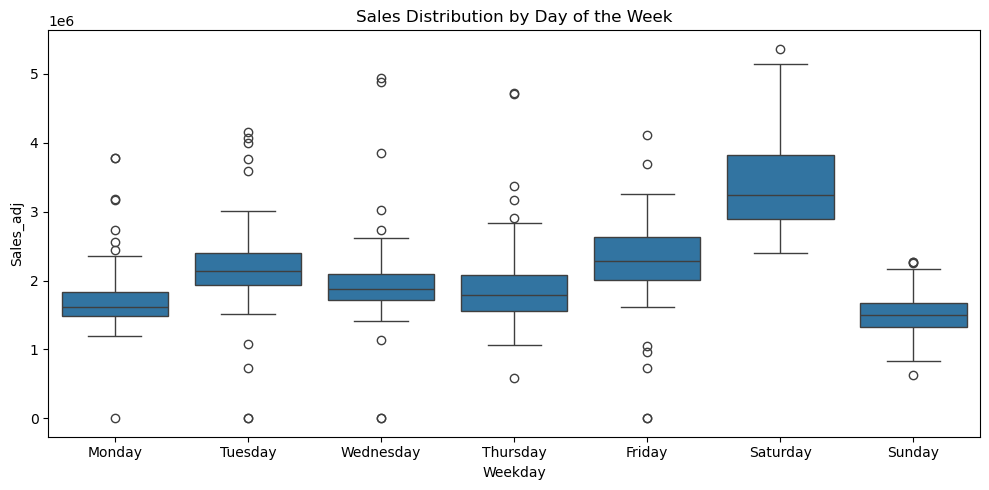

Kruskal-Wallis H = 666.26, p-value = 1.174e-140


In [65]:
df_complete['Weekday'] = df_complete['Date'].dt.day_name()
weekday_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']

fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(data=df_complete, x='Weekday', y='Sales_adj', order=weekday_order, ax=ax)
ax.set_title('Sales Distribution by Day of the Week')
plt.tight_layout(); plt.show()

groups = [df_complete.loc[df_complete['Weekday'] == d, 'Sales_adj'].dropna() for d in weekday_order]
stat, p = kruskal(*groups)
print(f"Kruskal-Wallis H = {stat:.2f}, p-value = {p:.4g}")

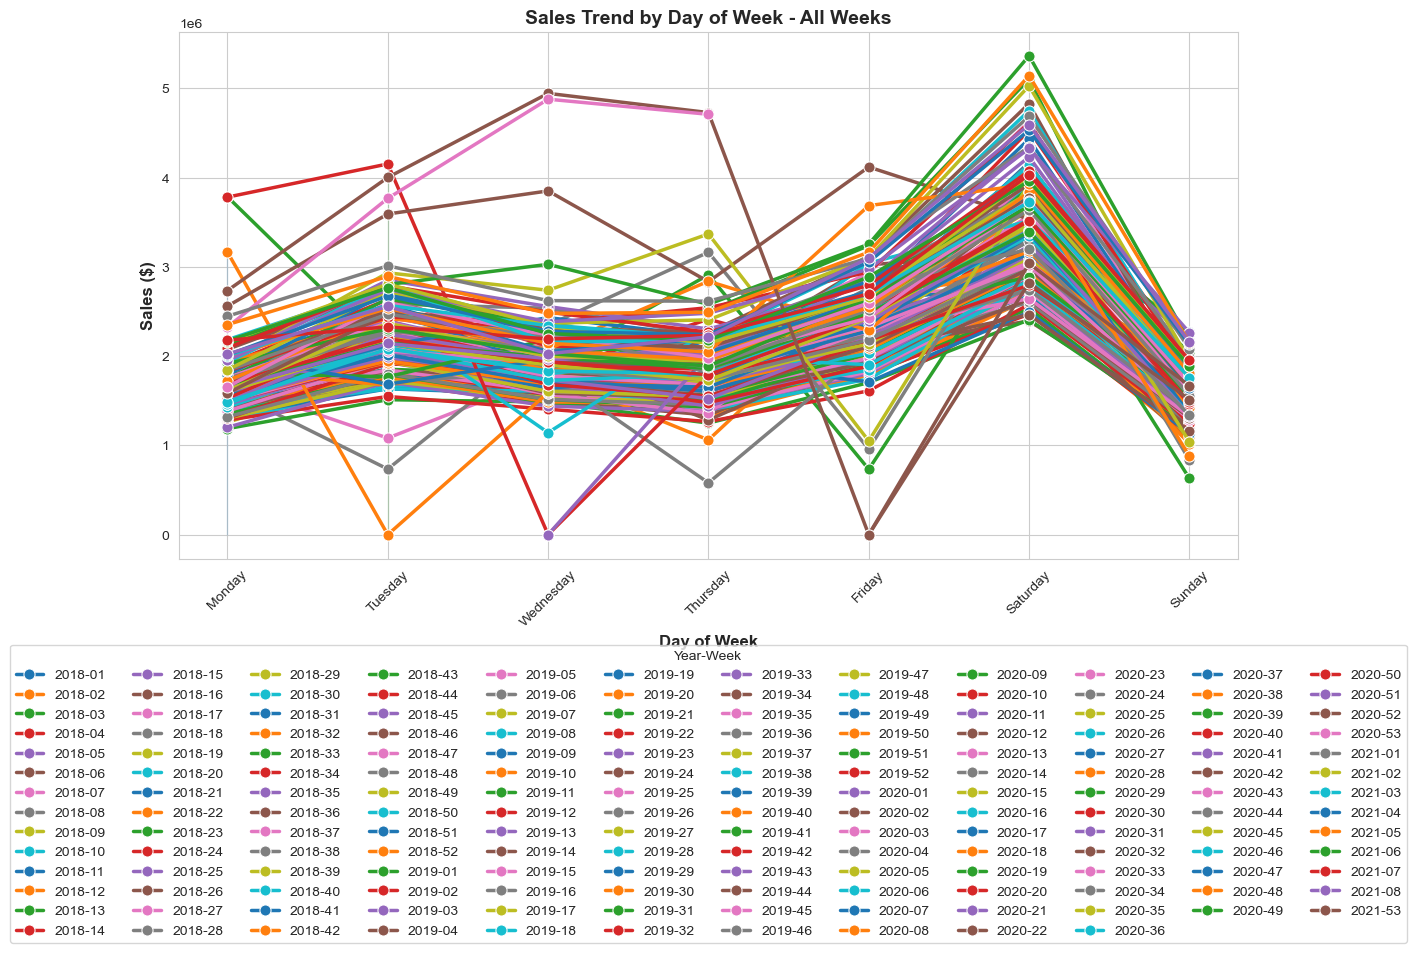

In [66]:
# Ensure correct weekday order
weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
df_chart1 = df_complete.copy()
df_chart1['Weekday'] = pd.Categorical(df_chart1['Weekday'], categories=weekday_order, ordered=True)
df_chart1['Year-Week'] = df_complete['Date'].dt.strftime('%Y-%V')
df_chart1 = df_chart1.sort_values(['Year-Week', 'Weekday'])

# Create line chart with all weeks
plt.figure(figsize=(14, 10))
sns.set_style("whitegrid")

# Plot each week as a separate line
for week in df_chart1['Year-Week'].unique():
    week_data = df_chart1[df_chart1['Year-Week'] == week]
    sns.lineplot(data=week_data, x='Weekday', y='Sales_adj', 
                 marker='o', markersize=8, linewidth=2.5, 
                 label=week)

plt.xlabel('Day of Week', fontsize=12, fontweight='bold')
plt.ylabel('Sales ($)', fontsize=12, fontweight='bold')
plt.title('Sales Trend by Day of Week - All Weeks', fontsize=14, fontweight='bold')
plt.xticks(rotation=45)
# plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Year-Week')
# plt.legend([]) # no legend
# Place legend at bottom
plt.legend(bbox_to_anchor=(0.5, -0.15),  # Position at bottom center
           loc='upper center',           # Anchor point
           ncol=12,                      # Number of columns
           fontsize=10,
           title='Year-Week')
plt.tight_layout()
plt.show()

#### ▪️<span style="color:purple">Notes</span>

- Saturday sales values are usually higher than the rest of the week.

- With a p-value ~ 0, we can say that at least one weekday is different than the others. A significant result that backs up treating weekday as a structural driver, not noise, going into Step A/E.

### Sales vs. Month

Same logic as weekday, but for month, this is a first, non-time-series look at whether "month" as a business/calendar category relates to sales, independent of any seasonal-decomposition assumptions.


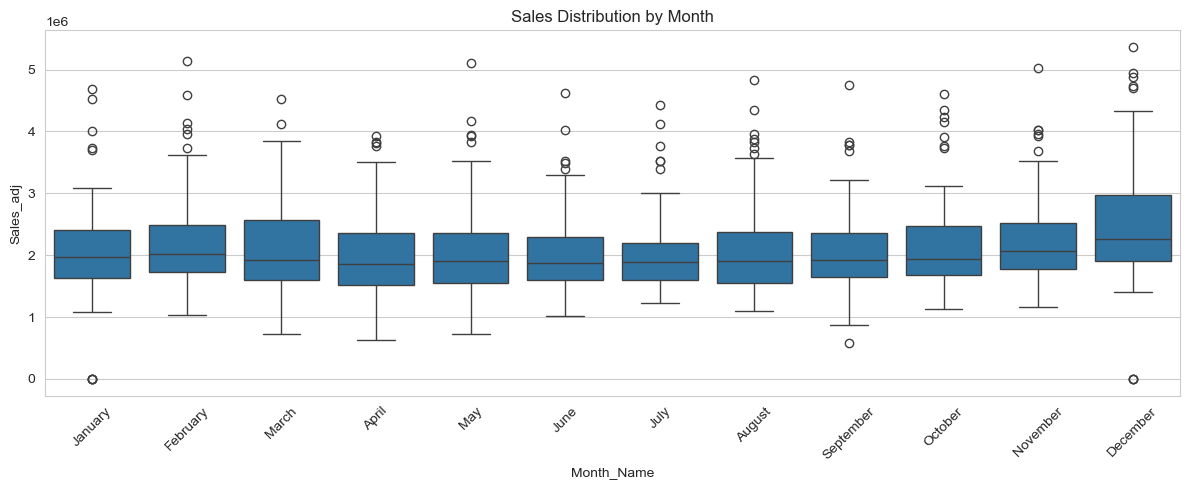

Kruskal-Wallis H = 36.95, p-value = 0.0001174


In [67]:
df_complete['Month_Name'] = df_complete['Date'].dt.month_name()
month_order = ['January','February','March','April','May','June','July',
               'August','September','October','November','December']

fig, ax = plt.subplots(figsize=(12, 5))
sns.boxplot(data=df_complete, x='Month_Name', y='Sales_adj', order=month_order, ax=ax)
ax.set_title('Sales Distribution by Month')
plt.xticks(rotation=45)
plt.tight_layout(); plt.show()

groups = [df_complete.loc[df_complete['Month_Name'] == m, 'Sales_adj'].dropna() for m in month_order]
stat, p = kruskal(*groups)
print(f"Kruskal-Wallis H = {stat:.2f}, p-value = {p:.4g}")

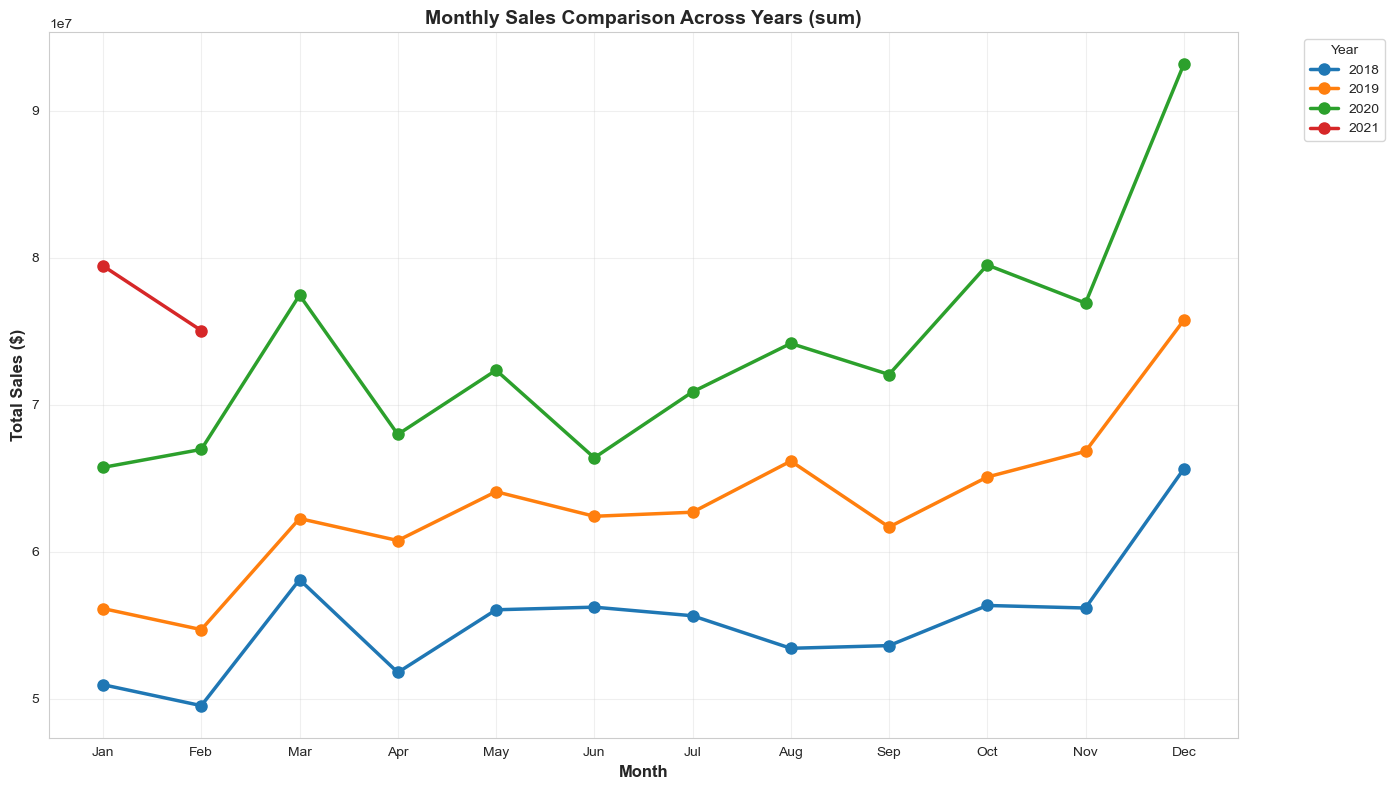

In [68]:
# Prepare data for monthly aggregation
df_chart2 = df_complete.copy()

# Create year and month columns
df_chart2['Year'] = df_chart2['Date'].dt.year
df_chart2['Month'] = df_chart2['Date'].dt.month
df_chart2['Month_Name'] = df_chart2['Date'].dt.strftime('%b')  # Jan, Feb, Mar, etc.

# Aggregate sales by Year and Month (SUM)
monthly_sales = df_chart2.groupby(['Year', 'Month', 'Month_Name'])['Sales_adj'].sum().reset_index()

# Sort by month number
monthly_sales = monthly_sales.sort_values(['Year', 'Month'])

# Create the line chart
plt.figure(figsize=(14, 8))
sns.set_style("whitegrid")

# Plot each year as a separate line
years = monthly_sales['Year'].unique()
for year in years:
    year_data = monthly_sales[monthly_sales['Year'] == year]
    plt.plot(year_data['Month_Name'], year_data['Sales_adj'], 
             marker='o', linewidth=2.5, markersize=8, 
             label=str(year))

plt.xlabel('Month', fontsize=12, fontweight='bold')
plt.ylabel('Total Sales ($)', fontsize=12, fontweight='bold')
plt.title('Monthly Sales Comparison Across Years (sum)', fontsize=14, fontweight='bold')
plt.xticks(range(12), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
                       'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.legend(title='Year', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

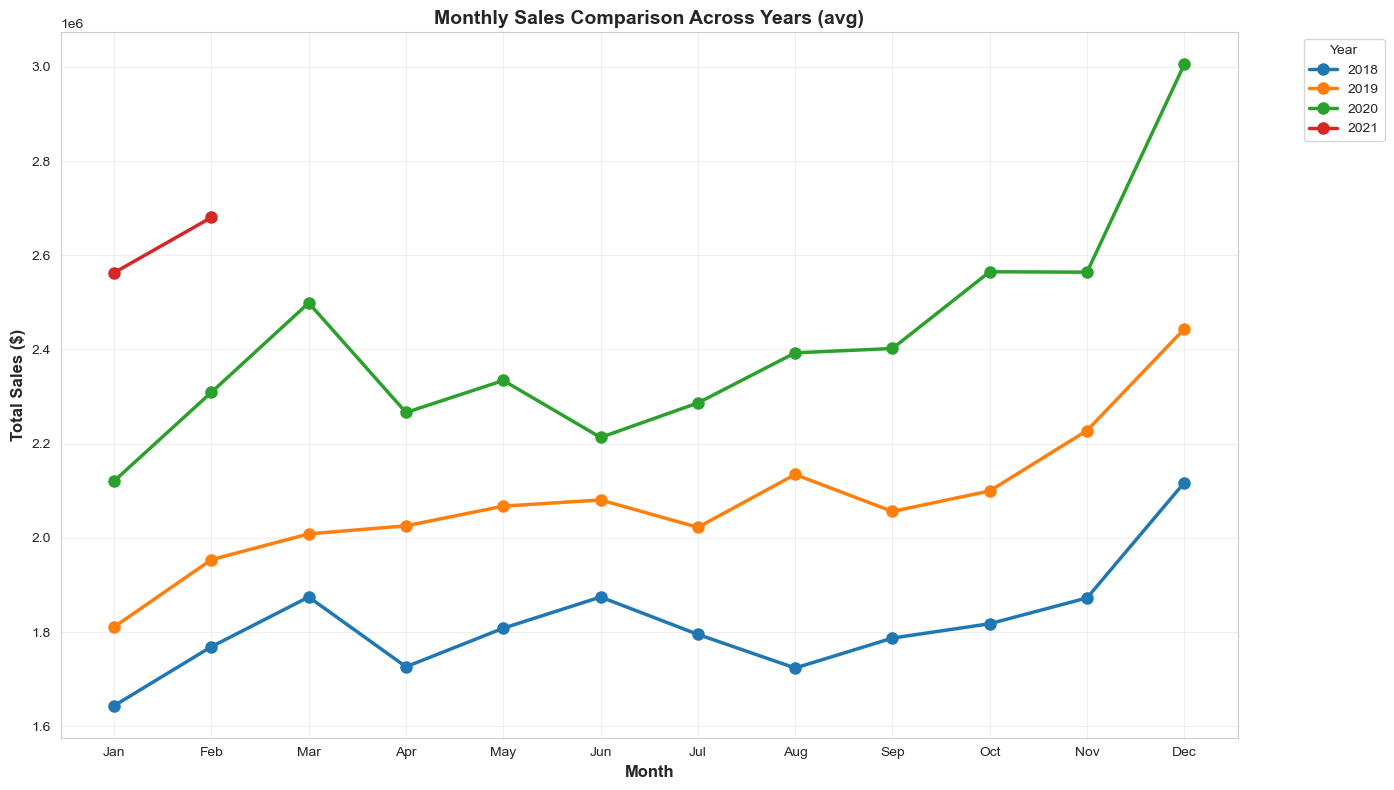

In [69]:
# Prepare data for monthly aggregation
df_chart3 = df_complete.copy()

# Create year and month columns
df_chart3['Year'] = df_chart3['Date'].dt.year
df_chart3['Month'] = df_chart3['Date'].dt.month
df_chart3['Month_Name'] = df_chart3['Date'].dt.strftime('%b')  # Jan, Feb, Mar, etc.

# Aggregate sales by Year and Month (AVG)
monthly_sales = df_chart3.groupby(['Year', 'Month', 'Month_Name'])['Sales_adj'].mean().reset_index()

# Sort by month number
monthly_sales = monthly_sales.sort_values(['Year', 'Month'])

# Create the line chart
plt.figure(figsize=(14, 8))
sns.set_style("whitegrid")

# Plot each year as a separate line
years = monthly_sales['Year'].unique()
for year in years:
    year_data = monthly_sales[monthly_sales['Year'] == year]
    plt.plot(year_data['Month_Name'], year_data['Sales_adj'], 
             marker='o', linewidth=2.5, markersize=8, 
             label=str(year))

plt.xlabel('Month', fontsize=12, fontweight='bold')
plt.ylabel('Total Sales ($)', fontsize=12, fontweight='bold')
plt.title('Monthly Sales Comparison Across Years (avg)', fontsize=14, fontweight='bold')
plt.xticks(range(12), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
                       'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.legend(title='Year', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

#### ▪️<span style="color:purple">Notes</span>

- December seems to have a higher sales than the rest of the year, similar in February but in a small scale.

- Since there are only ~3 observations of each month (one per year), treat any "significant" result cautiously, it's consistent with, but doesn't prove, a genuine annual seasonal pattern (cross-reference against the year-over-year overlay chart discussed earlier).

- **Kruskal-Wallis** test: With a p-value ~ 0, we can say that at least one month is different than the others.

- **Question**
    - _Can we create a monthly seasonal index to capture this seasonality to not only rely on the weekly trend?_

Jan    0.955
Feb    1.023
Mar    0.999
Apr    0.942
May    0.972
Jun    0.965
Jul    0.955
Aug    0.978
Sep    0.977
Oct    1.014
Nov    1.043
Dec    1.184
Name: Sales_adj, dtype: float64


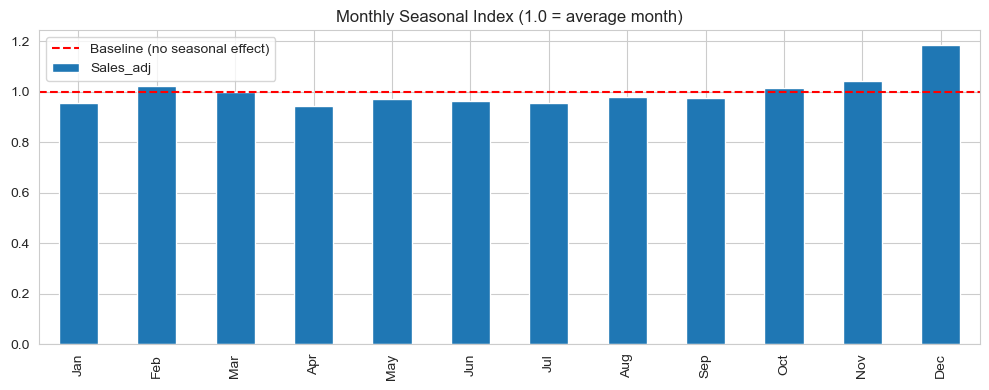

In [70]:
# Monthly seasonal index: average sales per month, normalized to a baseline of 1.0
monthly_avg = df_complete.groupby(df_complete['month'])['Sales_adj'].mean()
overall_avg = df_complete['Sales_adj'].mean()

seasonal_index = (monthly_avg / overall_avg).round(3)
seasonal_index_byMonth = seasonal_index.copy()
seasonal_index_byMonth.index = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
print(seasonal_index_byMonth)

fig, ax = plt.subplots(figsize=(10,4))
seasonal_index_byMonth.plot(kind='bar', ax=ax)
ax.axhline(1.0, color='red', linestyle='--', label='Baseline (no seasonal effect)')
ax.set_title('Monthly Seasonal Index (1.0 = average month)')
ax.legend(); plt.tight_layout(); plt.show()

### Sales vs. All Flags: Consolidated Correlation

A single correlation matrix, treating the binary flags as 0/1 numerics alongside `Sales_adj`, gives one consolidated view of every bivariate relationship covered so far (flag-vs-flag, and now flag-vs-target) in one place.

- Point-biserial correlation (Pearson on a 0/1 flag) is a reasonable linear summary here, but keep in mind it can understate a real effect if the relationship isn't linear, cross-check against the boxplot/Mann-Whitney results rather than relying on this table alone.

           Sales_adj  Feriado  Pagamento   Vale  isClosed
Sales_adj      1.000   -0.059      0.047  0.001    -0.220
Feriado       -0.059    1.000     -0.037 -0.017    -0.015
Pagamento      0.047   -0.037      1.000 -0.039    -0.015
Vale           0.001   -0.017     -0.039  1.000    -0.016
isClosed      -0.220   -0.015     -0.015 -0.016     1.000


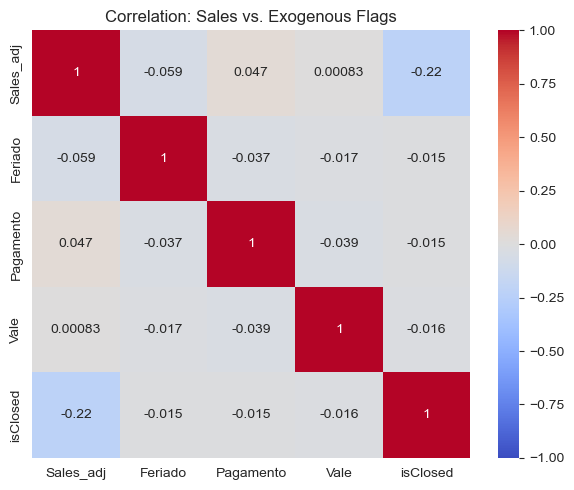

In [71]:
corr_vars = ['Sales_adj', 'Feriado', 'Pagamento', 'Vale', 'isClosed'] 

corr_matrix = df_complete[corr_vars].corr()
print(corr_matrix.round(3))

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, ax=ax, vmin=-1, vmax=1)
ax.set_title('Correlation: Sales vs. Exogenous Flags')
plt.tight_layout(); plt.show()


#### ▪️<span style="color:purple">Notes</span>

- `isClosed` (-0.220) is by far the strongest relationship in the table: expected, since sales are ~0 on the 7 days the store doesn't operate. This is a confirmation of the earlier data-quality check, not a new finding.
- `Feriado` (-0.059) is weak, consistent with the earlier Mann-Whitney result (p=0.0645, not significant at α=0.05).
- `Pagamento` (+0.047) looks small next to isClosed, but should **not** be read as "Pagamento barely matters": it was the one flag confirmed statistically significant (p=0.0014) in the earlier bivariate test. Correlation coefficients are compressed by low base-rate flags (Pagamento is "on" only ~3.5% of days), so a real, consistent effect on those days still produces a modest Pearson r across the full dataset. Effect size + significance (from the earlier table) is the more reliable read than the raw correlation coefficient alone.
- `Vale` (0.001) shows no linear relationship, consistent with its earlier non-significant result (p=0.52).
- Takeaway: correlation strength here should be read alongside the earlier Mann-Whitney effect-size table, not in isolation: `isClosed` and `Pagamento` are the two flags with genuine, reliable relationships to sales, despite very different correlation magnitudes.

### ▫️<span style="color:purple">Section Final Notes</span>

- The monthly seasonal index explored above (Dec 1.184, Nov 1.043, Apr 0.942, etc.) was computed using the full date range available at this point in the notebook, which includes the holdout period (Jan–Feb/2021). Using it as-is would leak holdout information into a feature used later for modeling.

- **Decision**: `Seasonal_Index` will be added as a column to `df_complete` only after Step B's train/holdout split, computed from `ts_train` alone and then mapped onto all rows (train, holdout, and future). This avoids any holdout leakage while keeping the feature available for the SARIMAX comparison planned in Step F2.

- **Summary: variables still needed for the future prediction dataset**: Part 1 derived several rules and features from historical data, but none of them exist yet for future dates (e.g., March/2021). The table below consolidates everything that must be reconstructed when the future dataset is built in Step J.

| Variable | Source rule | Status |
|---|---|---|
| `isClosed` | Closed every Dec-25 and Jan-01 (deterministic date check) | Rule defined, ready to apply |
| `Feriado` | Match against known holiday names from `holidays.csv` (17 confirmed names) | Rule defined, ready to apply |
| `Pagamento` | 3rd or 4th business day of the month (business day = Mon–Fri, excluding `Feriado`/`isClosed`) | Rule defined (`get_payment_date()`), ~68–76% historical accuracy |
| `Vale` | 17th business day of the month; also 16th in Nov/Dec | Rule defined (`get_vale_date()`), ~63.8–68% historical accuracy |
| `Seasonal_Index` | Monthly index (Dec 1.184, Nov 1.043, Apr 0.942, etc.) | Deferred, computed from `ts_train` only (post Step B split) and mapped onto future dates by month, per the decision above |

- `Pagamento` and `Vale` are the two flags with imperfect reconstruction rules, any forecast for a future period inherits that uncertainty, since the model will be conditioned on *predicted* rather than *actual* event days. Worth restating this limitation when interpreting forecast error in Step I/J.

# 🔹**PART 2**: Time Series Analysis

---

## 🔸Step A: Visual Analysis of the Series

Pulling together the full visual/statistical analysis of Step A (original charts + variance stability, long-range ACF, calendar heatmap, year-over-year overlay, lag scatterplots) into one consolidated view before moving to Step B.

- Full Series
- First 90 days
- Last 90 days
- Additive Decomposition
- Multiplicative Decomposition


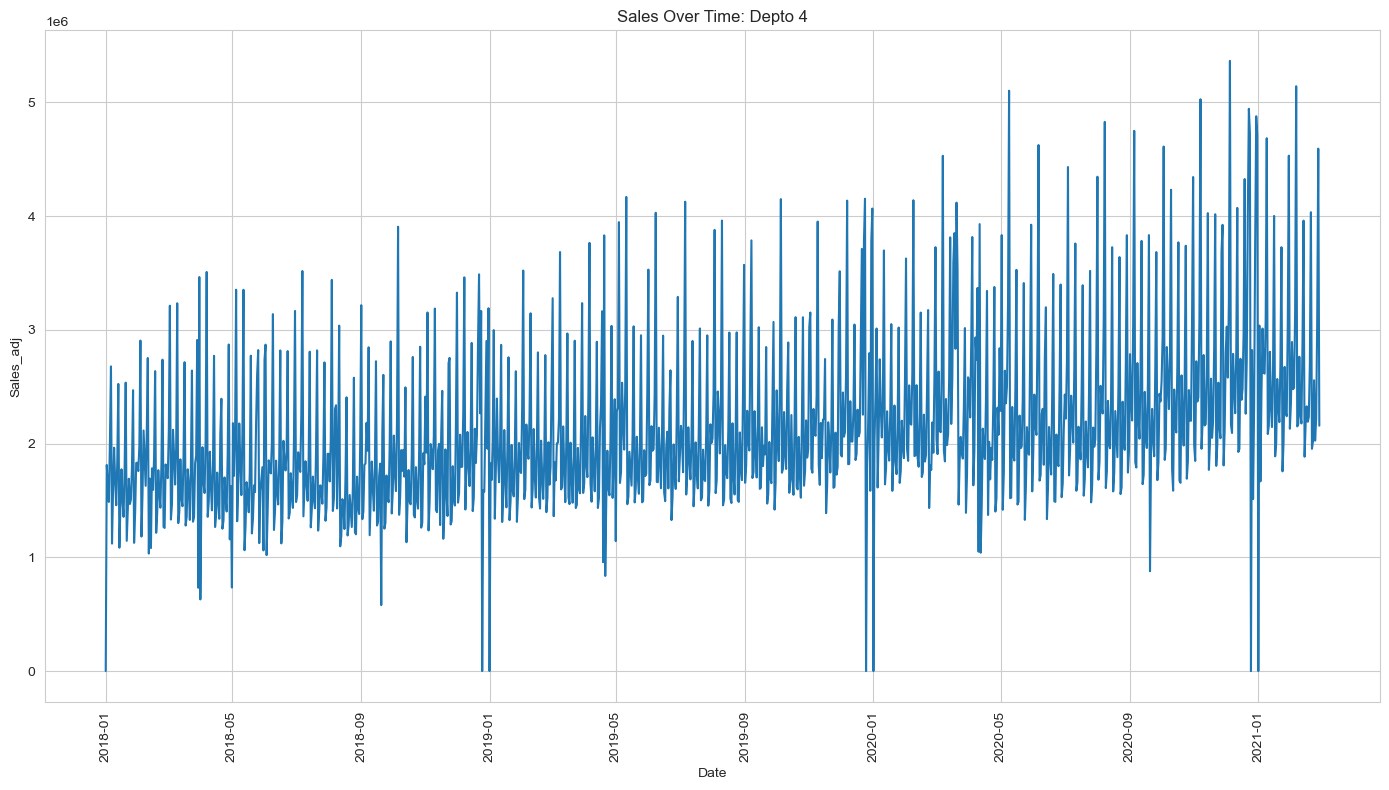

In [72]:
# full series
plt.figure(figsize=(14, 8))
sns.lineplot(data=df_complete, x='Date', y='Sales_adj')
plt.title(f"Sales Over Time: {choose_dept}")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


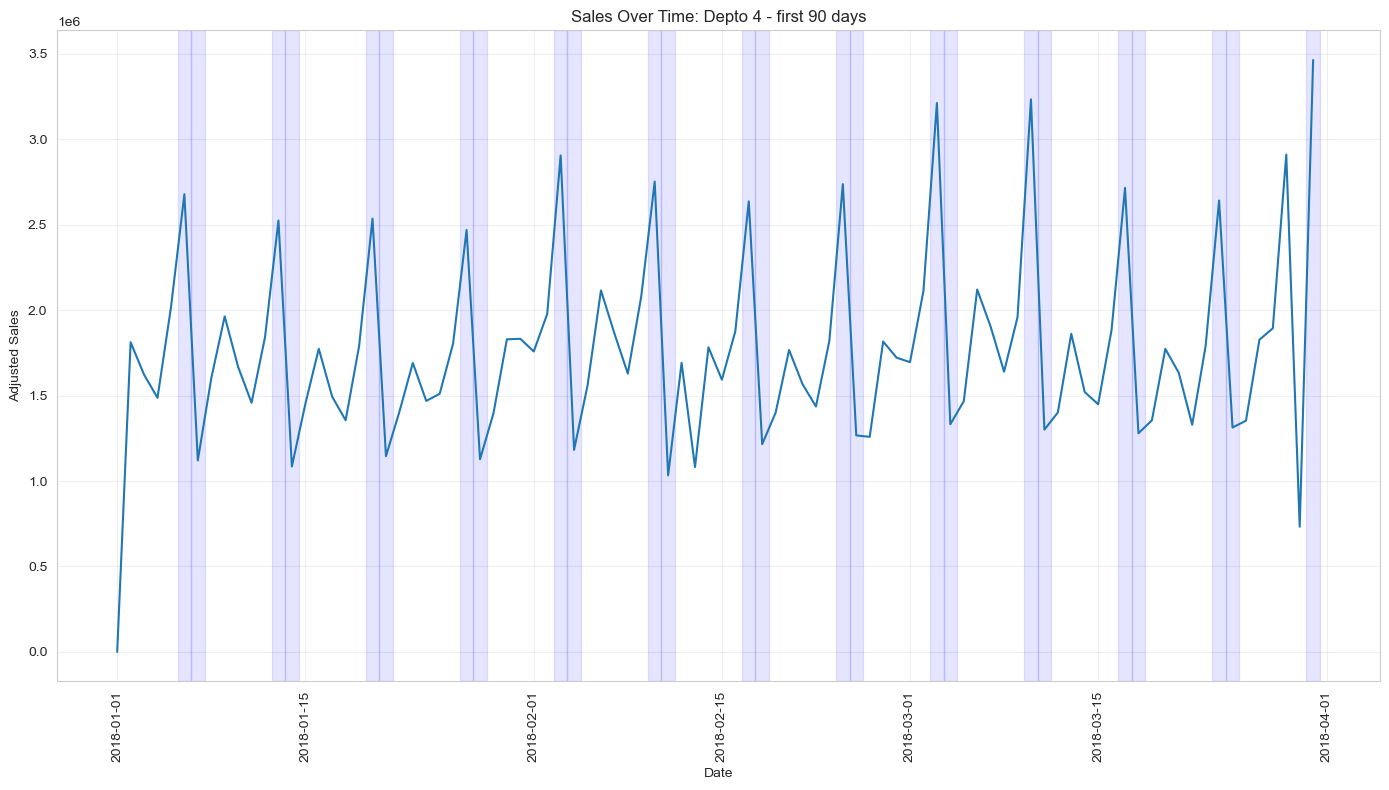

In [73]:
# First 90 days
period_90f = df_complete.head(90).copy()

plt.figure(figsize=(14, 8))
sns.lineplot(data=period_90f, x='Date', y='Sales_adj')

# Highlight weekends (Saturday=5, Sunday=6)
for date in period_90f['Date'].unique():
    if date.weekday() >= 5:  # Saturday or Sunday
        plt.axvspan(date - pd.Timedelta(hours=12), 
                   date + pd.Timedelta(hours=12), 
                   alpha=0.1, color='blue')

plt.title(f"Sales Over Time: {choose_dept} - first 90 days")
plt.xlabel("Date")
plt.ylabel("Adjusted Sales")
plt.xticks(rotation=90)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


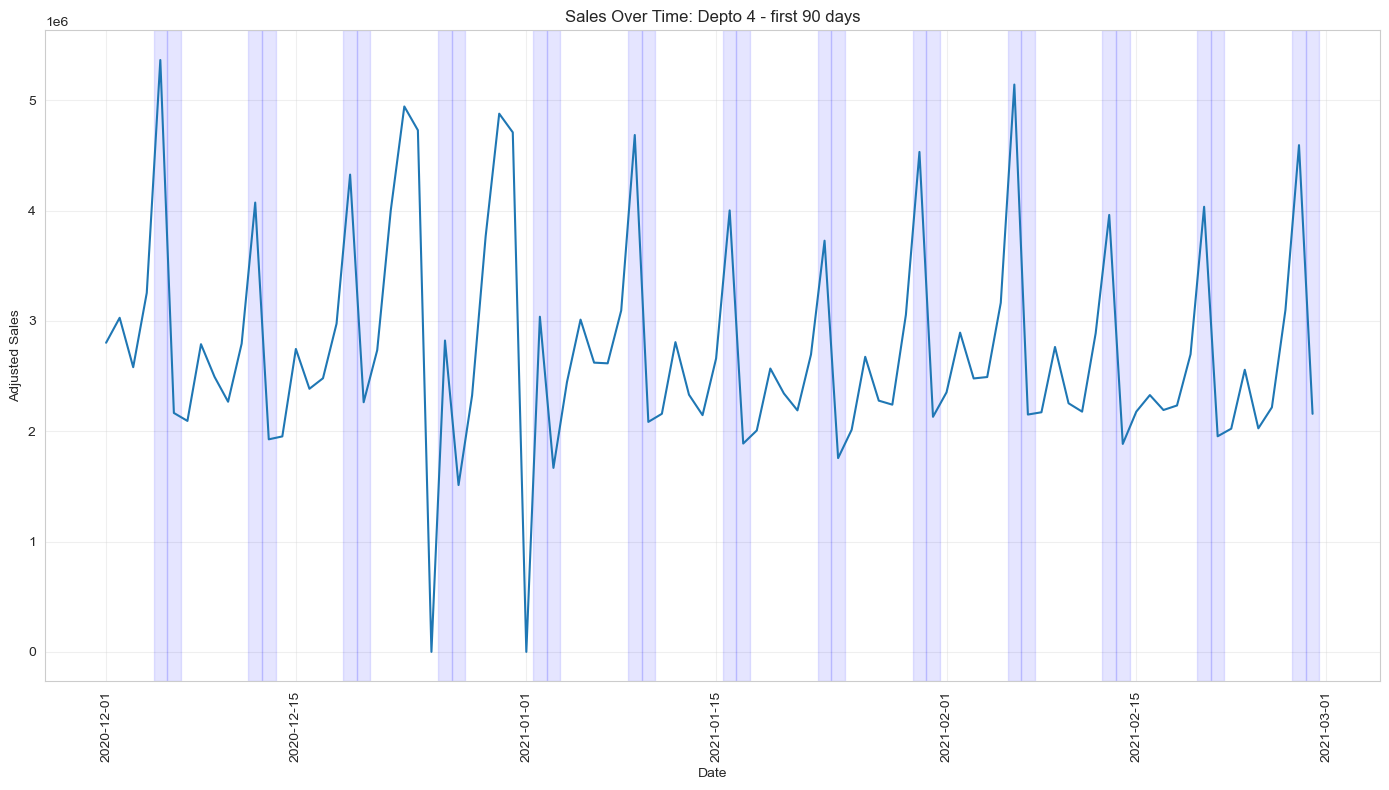

In [74]:
# Last 90 days
period_90l = df_complete.tail(90).copy()

plt.figure(figsize=(14, 8))
sns.lineplot(data=period_90l, x='Date', y='Sales_adj')

# Highlight weekends (Saturday=5, Sunday=6)
for date in period_90l['Date'].unique():
    if date.weekday() >= 5:  # Saturday or Sunday
        plt.axvspan(date - pd.Timedelta(hours=12), 
                   date + pd.Timedelta(hours=12), 
                   alpha=0.1, color='blue')

plt.title(f"Sales Over Time: {choose_dept} - first 90 days")
plt.xlabel("Date")
plt.ylabel("Adjusted Sales")
plt.xticks(rotation=90)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Additive vs. Multiplicative Decomposition

Comparing both decomposition models side-by-side helps answer the open Step A question of whether trend/seasonal effects add a constant amount or scale with the level. Multiplicative decomposition requires strictly positive values, so any exact zeros (e.g., on `isClosed` days) are replaced with a tiny epsilon before decomposing — this only affects the multiplicative version's ability to run, not the underlying data.


Zeros replaced: 7
Remaining non-positive values: 0


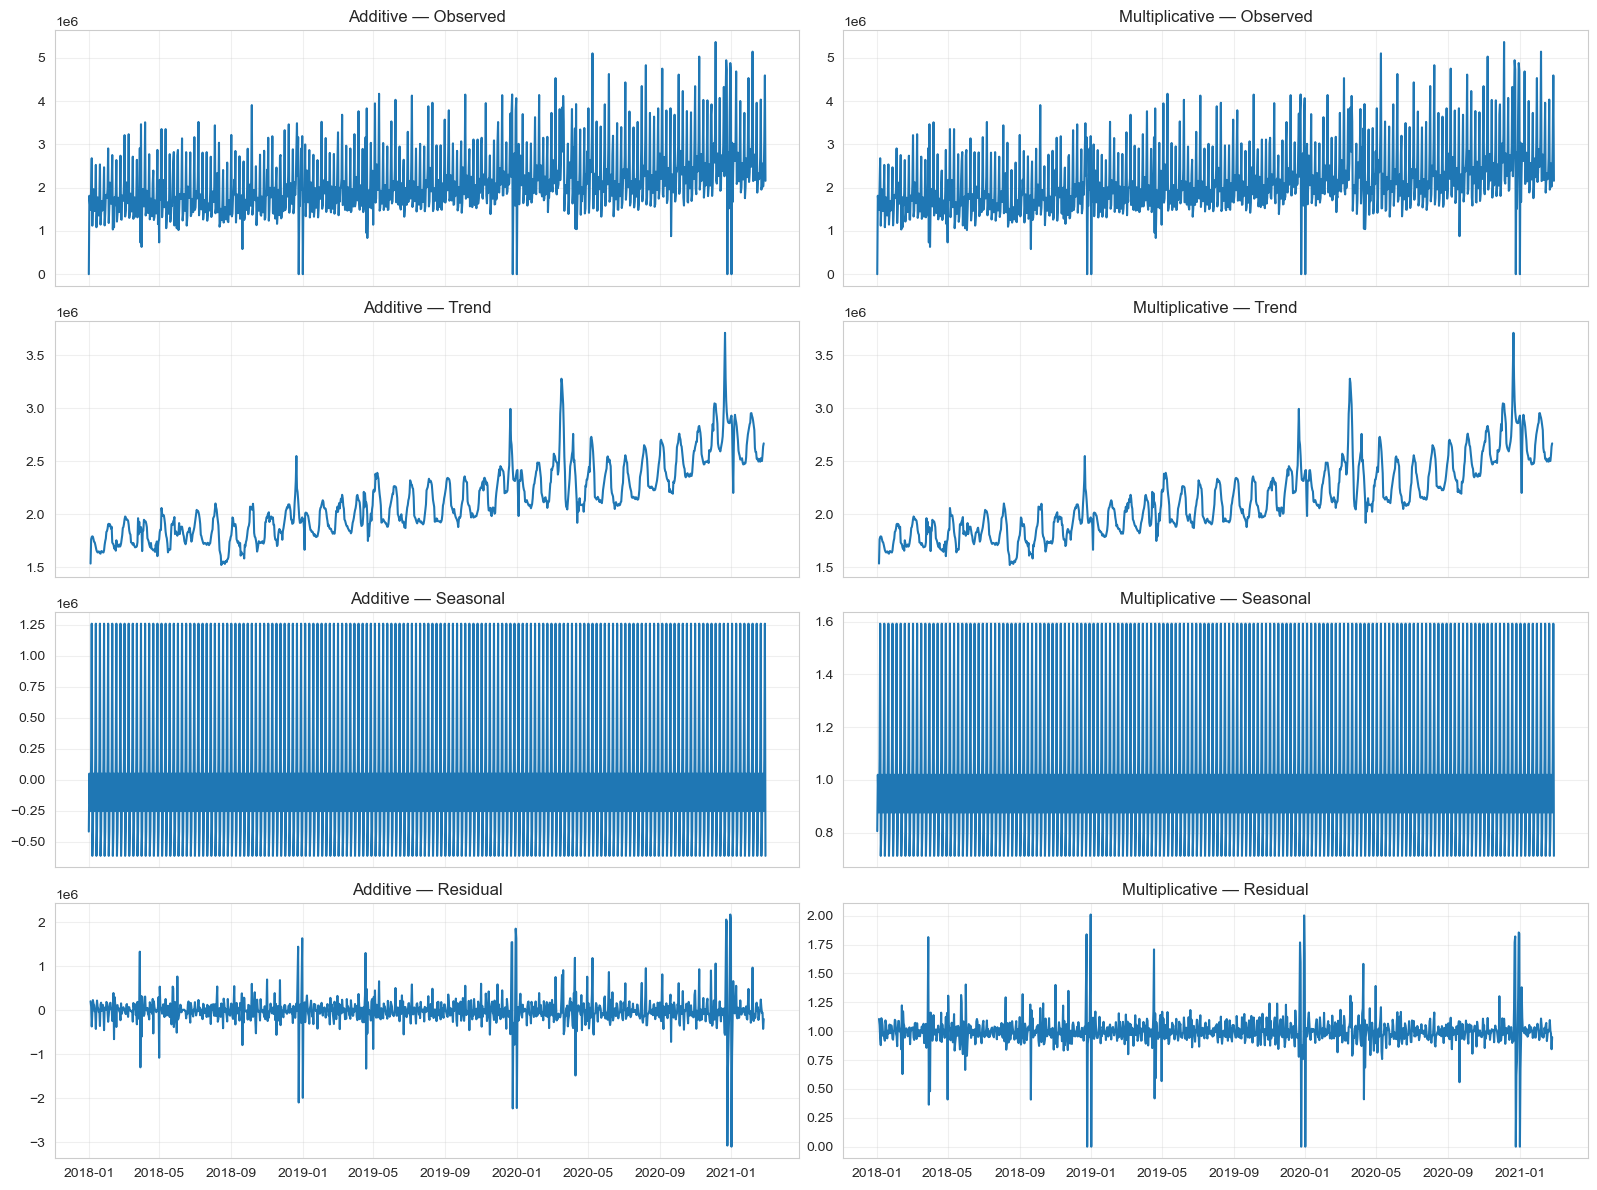

In [75]:
# Ensure ts exists before decomposing
ts = df_complete.set_index('Date')['Sales_adj']

# Replace exact zeros with a small epsilon so multiplicative decomposition can run
ts_for_decomp = ts.copy()
ts_for_decomp = ts_for_decomp.where(ts_for_decomp != 0, 0.000001)

print(f"Zeros replaced: {(ts == 0).sum()}")
print(f"Remaining non-positive values: {(ts_for_decomp <= 0).sum()}")

decomp_add = seasonal_decompose(ts_for_decomp, model='additive', period=7)
decomp_mul = seasonal_decompose(ts_for_decomp, model='multiplicative', period=7)

fig, axes = plt.subplots(4, 2, figsize=(16, 12), sharex=True)

for col, decomp, title in [(0, decomp_add, 'Additive'), (1, decomp_mul, 'Multiplicative')]:
    axes[0, col].plot(decomp.observed); axes[0, col].set_title(f'{title} — Observed')
    axes[1, col].plot(decomp.trend); axes[1, col].set_title(f'{title} — Trend')
    axes[2, col].plot(decomp.seasonal); axes[2, col].set_title(f'{title} — Seasonal')
    axes[3, col].plot(decomp.resid); axes[3, col].set_title(f'{title} — Residual')
    for row in range(4):
        axes[row, col].grid(alpha=0.3)

plt.tight_layout(); plt.show()

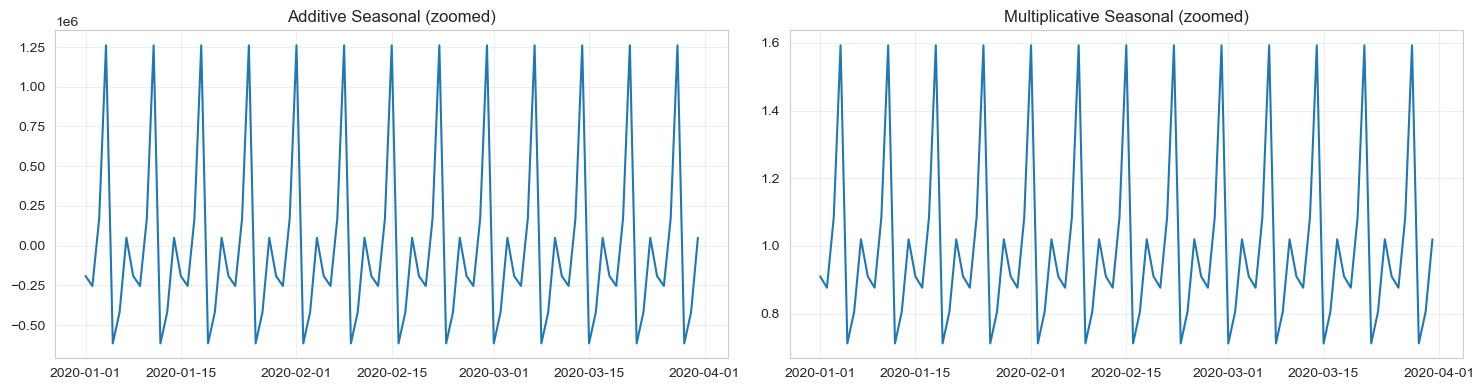

In [76]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4))

zoom_start, zoom_end = '2020-01-01', '2020-03-31'

axes[0].plot(decomp_add.seasonal.loc[zoom_start:zoom_end])
axes[0].set_title('Additive Seasonal (zoomed)')
axes[0].grid(alpha=0.3)

axes[1].plot(decomp_mul.seasonal.loc[zoom_start:zoom_end])
axes[1].set_title('Multiplicative Seasonal (zoomed)')
axes[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()

#### ▪️<span style="color:purple">Notes</span>

- The epsilon replacement (0 → 0.000001) only affects the 7 `isClosed` days (and any other exact-zero rows), small enough to not distort the rest of the series, but expect a visible spike/artifact in the multiplicative seasonal or residual component right at those exact dates, since dividing by a near-zero trend estimate can blow up the ratio locally.

- Observed and Trend rows are visually identical between the two models
    - expected, since the trend estimate itself doesn't depend on additive/multiplicative choice.

- Seasonal: additive shows an absolute (~-0.5M to +1.25M) adjustment; multiplicative shows a proportional (~0.8x to 1.6x) adjustment. Neither row can show whether seasonal amplitude scales with the trend level, since classical decomposition assumes a fixed seasonal pattern throughout.
    - Short period chart show a dense, blocky pattern because the 7-day cycle is compressed across ~3 years of x-axis, a zoomed-in view is more readable for confirming the actual weekly shape.

- Residual is the deciding factor: the **additive residual grows substantially over time** (largest swings appear in 2020–2021, up to ±2–3M), indicating the additive model leaves increasing unexplained variance as sales grow. The **multiplicative residual stays in a comparable range throughout** the full period, consistent with variance scaling proportionally with the level.

- **Conclusion**: 
    - multiplicative decomposition is the better fit for this series. This carries forward as the working choice for Step F1 (Holt-Winters: `trend='mul'`, `seasonal='mul'`) and suggests modeling `log(Sales_adj)` may also be worth testing in Step D/F2, since a log transform turns a multiplicative relationship into an additive one that ARIMA/SARIMA can work with directly.


- **Signals**:
    - **Trend**: Shows trends, increasing through the years.
    - **Seasonality**: Weekly seasonality detected (7 days).
    - **Cicles**: No visible cicles.

## 🔸Step B: Train / Holdout 

**Objective**: split the series into a training set (through Dec/2020) and a holdout set (Jan–Feb/2021), matching the Data Description. From this point forward, all identification, estimation, and diagnostics (Steps C–H) use `ts_train` only, the holdout is untouched until Step I.

**Note**: training data represents "known" historical performance used to fit the model; holdout simulates "future" data to validate accuracy before it's trusted to forecast March/2021.

In [77]:
# Define dates for the split
train_end = '2020-12-31'
holdout_start = '2021-01-01'
holdout_end = '2021-02-28'

### ➕Applying the Epsilon Substitution

Since `df_complete` carries the exogenous variables alongside sales (needed for Step F2's SARIMAX), the epsilon substitution is applied here directly on `Sales_adj`, rather than only on the standalone `ts` series. This keeps `ts`/`ts_train`/`ts_holdout` and `exog_train`/`exog_holdout` built from the same consistent source going forward.


In [78]:
EPSILON = 0.000001

n_zero_before = (df_complete['Sales_adj'] == 0).sum()
df_complete['Sales_adj'] = df_complete['Sales_adj'].where(df_complete['Sales_adj'] != 0, EPSILON)
n_zero_after = (df_complete['Sales_adj'] == 0).sum()

print(f"Zeros before: {n_zero_before}, zeros after: {n_zero_after}")
print(f"Min value: {df_complete['Sales_adj'].min():.6f}")


Zeros before: 7, zeros after: 0
Min value: 0.000001


#### ▪️<span style="color:purple">Notes</span>

- Substitution now applied at the source (`df_complete['Sales_adj']`), not just on the derived `ts` series — this means `exog_train`/`exog_holdout` built later from `df_complete` for Step F2 will stay consistent with `ts_train`/`ts_holdout`.
- `ts`, `ts_train`, `ts_holdout` are rebuilt from `df_complete` after the substitution, using the same `train_end`/`holdout_start`/`holdout_end` boundaries from earlier in Step B.
- Confirm 0 zeros / 0 negatives remain in all three series.
- Trade-off worth noting: `df_complete['Sales_adj']` no longer preserves the literal "0 sales on isClosed days" fact directly in that column — but `isClosed` remains a separate flag, so that information isn't lost, just represented differently (flag + near-zero value instead of flag + exact zero).

### ➕Adding Seasonality Index by Month

Let's recalculate and add the seasonality index by month using only train dataset.


In [79]:
df_complete_train = df_complete[df_complete['Date'] <= train_end]

monthly_avg_train = df_complete_train.groupby(df_complete['month'])['Sales_adj'].mean()
overall_avg_train = df_complete_train['Sales_adj'].mean()

seasonal_index_train = (monthly_avg_train / overall_avg_train).round(3)
print('Train Dataset Seasonality Index:')
print(seasonal_index_train)

Train Dataset Seasonality Index:
month
1     0.883
2     0.957
3     1.011
4     0.954
5     0.984
6     0.977
7     0.967
8     0.990
9     0.990
10    1.027
11    1.056
12    1.199
Name: Sales_adj, dtype: float64


In [80]:
print('Full Dataset Seasonality Index:')
print(seasonal_index)

Full Dataset Seasonality Index:
month
1     0.955
2     1.023
3     0.999
4     0.942
5     0.972
6     0.965
7     0.955
8     0.978
9     0.977
10    1.014
11    1.043
12    1.184
Name: Sales_adj, dtype: float64


In [81]:
# Adding seasonality index to the main DF
df_complete['Seasonal_Index'] = df_complete['Date'].dt.month.map(seasonal_index_train)

print(df_complete[['Date', 'Seasonal_Index']].head())
print(f"\nMissing values: {df_complete['Seasonal_Index'].isna().sum()}")

        Date  Seasonal_Index
0 2018-01-01           0.883
1 2018-01-02           0.883
2 2018-01-03           0.883
3 2018-01-04           0.883
4 2018-01-05           0.883

Missing values: 0


#### ▪️<span style="color:purple">Notes</span>

Compariosn between index from full dataset vs train dataset.

- Most months (Mar–Dec) shift only slightly (~+0.01–0.02) between the full-dataset and train-only index.
    - expected noise from excluding 2 of 38 months.

- Jan and Feb shift more substantially: Jan drops from 0.955 to 0.883, and Feb flips from *above* baseline (1.023) to *below* baseline (0.957). 
    - This indicates Jan–Feb/2021 (the holdout period) performed unusually strong relative to the typical 2018–2020 pattern for those months.

- This is a good validation of the train-only approach: had the full-dataset index been used, `Seasonal_Index` for Feb would have been informed by the very data used to judge holdout accuracy in Step I, and would have overstated how strong February typically performs.

- Practical implication: expect the holdout evaluation (Step I) to show the model under-predicting Jan/Feb 2021 sales somewhat, since the train-only seasonal index treats those months as below-average, while the actual holdout data was atypically strong.


| Month_nbr | Month | Full Dataset | Train Dataset | Delta  |
| --------- | ----- | ------------ | ------------- | ------ |
| 1         | Jan   | 0.955        | 0.883         | -0.072 |
| 2         | Feb   | 1.023        | 0.957         | -0.066 |
| 3         | Mar   | 0.999        | 1.011         | 0.012  |
| 4         | Apr   | 0.942        | 0.954         | 0.012  |
| 5         | May   | 0.972        | 0.984         | 0.012  |
| 6         | Jun   | 0.965        | 0.977         | 0.012  |
| 7         | Jul   | 0.955        | 0.967         | 0.012  |
| 8         | Aug   | 0.978        | 0.99          | 0.012  |
| 9         | Sep   | 0.977        | 0.99          | 0.013  |
| 10        | Oct   | 1.014        | 1.027         | 0.013  |
| 11        | Nov   | 1.043        | 1.056         | 0.013  |
| 12        | Dec   | 1.184        | 1.199         | 0.015  |




### → Split Test / Holdout

Why this split matters for the business:

- Training data represents the "known" historical performance used to build the model

- Holdout data (Jan-Feb 2021) simulates "future" data to validate model accuracy before deployment

- This approach ensures our model will perform well on real future data (March 2021 forecast)

Train:   2018-01-01 to 2020-12-31  (1096 obs)
Holdout: 2021-01-01 to 2021-02-28  (59 obs)


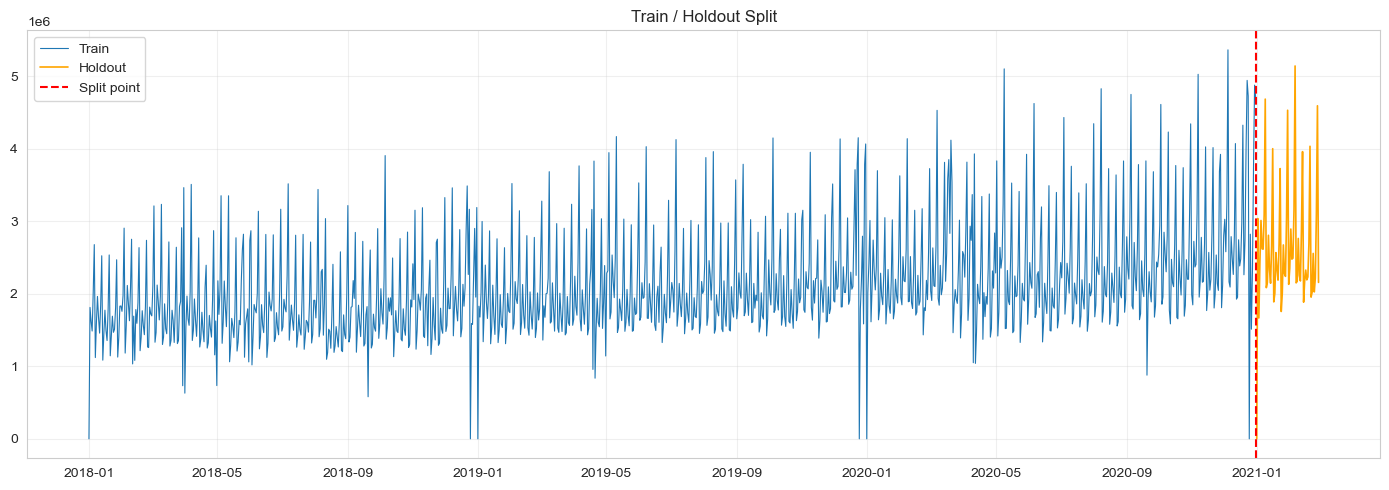

In [82]:
ts = df_complete.set_index('Date')['Sales_adj'] 

ts_train = ts.loc[:train_end]
ts_holdout = ts.loc[holdout_start:holdout_end]

print(f"Train:   {ts_train.index.min().date()} to {ts_train.index.max().date()}  ({len(ts_train)} obs)")
print(f"Holdout: {ts_holdout.index.min().date()} to {ts_holdout.index.max().date()}  ({len(ts_holdout)} obs)")

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(ts_train.index, ts_train.values, label='Train', linewidth=0.8)
ax.plot(ts_holdout.index, ts_holdout.values, label='Holdout', color='orange', linewidth=1.2)
ax.axvline(pd.Timestamp(train_end), color='red', linestyle='--', label='Split point')
ax.legend(); ax.set_title('Train / Holdout Split'); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 🔸Step C: White Noise Check

**Objective**: confirm `ts_train` is not white noise before investing further in a model — if it were, no model could beat a naive mean/last-value forecast, and Steps D–J would be moot.

### Ljung-Box Test

- H0: Series is white noise (no autocorrelation at the tested lags). 
- H1: it has exploitable structure.
- Decision rule: p-value < 0.05 at any lag → reject H0.

In [83]:
lb_test = acorr_ljungbox(ts_train, lags=[7, 14, 21, 30], return_df=True)
print(lb_test)

        lb_stat      lb_pvalue
7    784.673580  3.763896e-165
14  1410.837138  7.545037e-293
21  2050.686255   0.000000e+00
30  2771.851178   0.000000e+00


#### ▪️<span style="color:purple">Notes</span>

We ran the Ljung-Box test for different lags to check if we would find a white noise on the most commom lags on a daily series.
- From all lags, p-value < 0.05, rejecting the null hypothesis.
- The series is not a white noise, there are clearly patterns that we can predict with a time series model.


### ACF Plot for White Noise Check

A visual companion to the Ljung-Box test, a white-noise series would show (almost) all bars inside the confidence band.

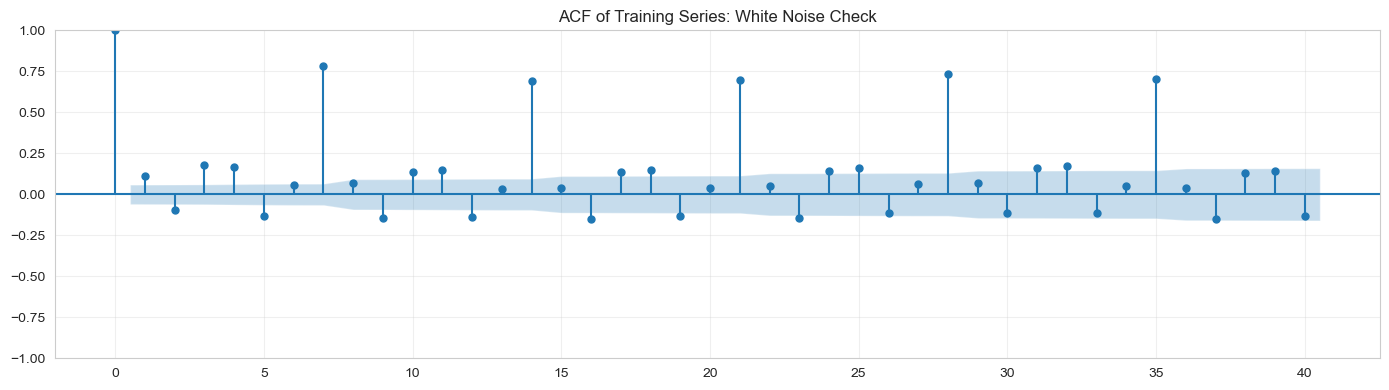

In [84]:
fig, ax = plt.subplots(figsize=(14, 4))
plot_acf(ts_train.dropna(), lags=40, ax=ax, alpha=0.05)
ax.set_title('ACF of Training Series: White Noise Check')
ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

#### ▪️<span style="color:purple">Notes</span>

- Lag-7 (and multiples of 7) are the ones that falls outside the confidence band, showing that it is a dominant signal on the train dataset too.
- Other lags 3, 4, 5 also falls outside the confidence band but they are super close to it, while Lag-7 is 3/4 times larger.


## 🔸Step D: Stationarity Check

**Objective**: determine whether `ts_train` is stationary, and if not, how much differencing (`d`, seasonal `D`) is needed before ARIMA/SARIMA (Step F2) can be applied. Exponential smoothing (Step F1) doesn't require stationarity, but this still matters for choosing between the two families.


### Augmented Dickey-Fuller (ADF) Test

- H0: the series has a unit root (non-stationary). 
- H1: the series is stationary.
- Decision rule: p-value < 0.05 → reject H0 → stationary.

In [85]:
def run_adf(series, label=''):
    result = adfuller(series.dropna())
    print(f"ADF Test: {label}")
    print(f"  ADF Statistic: {result[0]:.4f}")
    print(f"  p-value: {result[1]:.4f}")
    for k, v in result[4].items():
        print(f"  Critical Value ({k}): {v:.4f}")
    conclusion = 'Stationary' if result[1] < 0.05 else 'Non-stationary'
    print(f"  Conclusion: {conclusion} (alpha = 0.05)\n")
    return result

run_adf(ts_train, 'Sales_adj (level)')

ADF Test: Sales_adj (level)
  ADF Statistic: -1.6217
  p-value: 0.4718
  Critical Value (1%): -3.4364
  Critical Value (5%): -2.8642
  Critical Value (10%): -2.5682
  Conclusion: Non-stationary (alpha = 0.05)



(np.float64(-1.621719421817511),
 np.float64(0.4718279861636461),
 20,
 1075,
 {'1%': np.float64(-3.4364476591811033),
  '5%': np.float64(-2.864232347211692),
  '10%': np.float64(-2.5682035004867494)},
 np.float64(30768.06386295903))

#### ▪️<span style="color:purple">Notes</span>

- **Result**: ADF statistic = -1.6217, p-value = 0.4718 → fail to reject H0 → **non-stationary** at the level.

- This is expected given Step A's confirmed upward trend, a non-constant mean is exactly what the ADF test is picking up on. 
    - Differencing is needed before Step F2 (ARIMA/SARIMA);
    - Step F1 (exponential smoothing) can still work directly on the level series since it doesn't require stationarity.

### Differencing if Needed

If the level series is non-stationary, test regular and seasonal differencing (s=7, from the weekly seasonality confirmed in Step A).

In [86]:
ts_diff1 = ts_train.diff().dropna()
run_adf(ts_diff1, 'after 1st regular difference (d=1)')

ts_seasdiff = ts_train.diff(7).dropna()
run_adf(ts_seasdiff, 'after seasonal difference (D=1, s=7)')

ts_diff1_seasdiff = ts_train.diff().diff(7).dropna()
run_adf(ts_diff1_seasdiff, 'after regular + seasonal difference (d=1, D=1, s=7)')

ADF Test: after 1st regular difference (d=1)
  ADF Statistic: -14.6082
  p-value: 0.0000
  Critical Value (1%): -3.4364
  Critical Value (5%): -2.8642
  Critical Value (10%): -2.5682
  Conclusion: Stationary (alpha = 0.05)

ADF Test: after seasonal difference (D=1, s=7)
  ADF Statistic: -13.1424
  p-value: 0.0000
  Critical Value (1%): -3.4365
  Critical Value (5%): -2.8643
  Critical Value (10%): -2.5682
  Conclusion: Stationary (alpha = 0.05)

ADF Test: after regular + seasonal difference (d=1, D=1, s=7)
  ADF Statistic: -12.5931
  p-value: 0.0000
  Critical Value (1%): -3.4365
  Critical Value (5%): -2.8643
  Critical Value (10%): -2.5682
  Conclusion: Stationary (alpha = 0.05)



(np.float64(-12.593110435000636),
 np.float64(1.8030398783407628e-23),
 22,
 1065,
 {'1%': np.float64(-3.4365050530846846),
  '5%': np.float64(-2.864257662806096),
  '10%': np.float64(-2.568216983623179)},
 np.float64(30595.863570191126))

### Choosing Between d=1, D=1, and d=1+D=1

All three differenced series pass ADF, so the ADF test alone can't decide, it detects unit roots, not seasonality. 
The ACF of each candidate below shows whether the weekly (lag-7) pattern is still present after each differencing choice, and whether over-differencing artifacts (a sharp negative spike at lag 1) appear.

- Key insight: which differencing choice removes the lag-7 spike without introducing an over-differencing artifact?

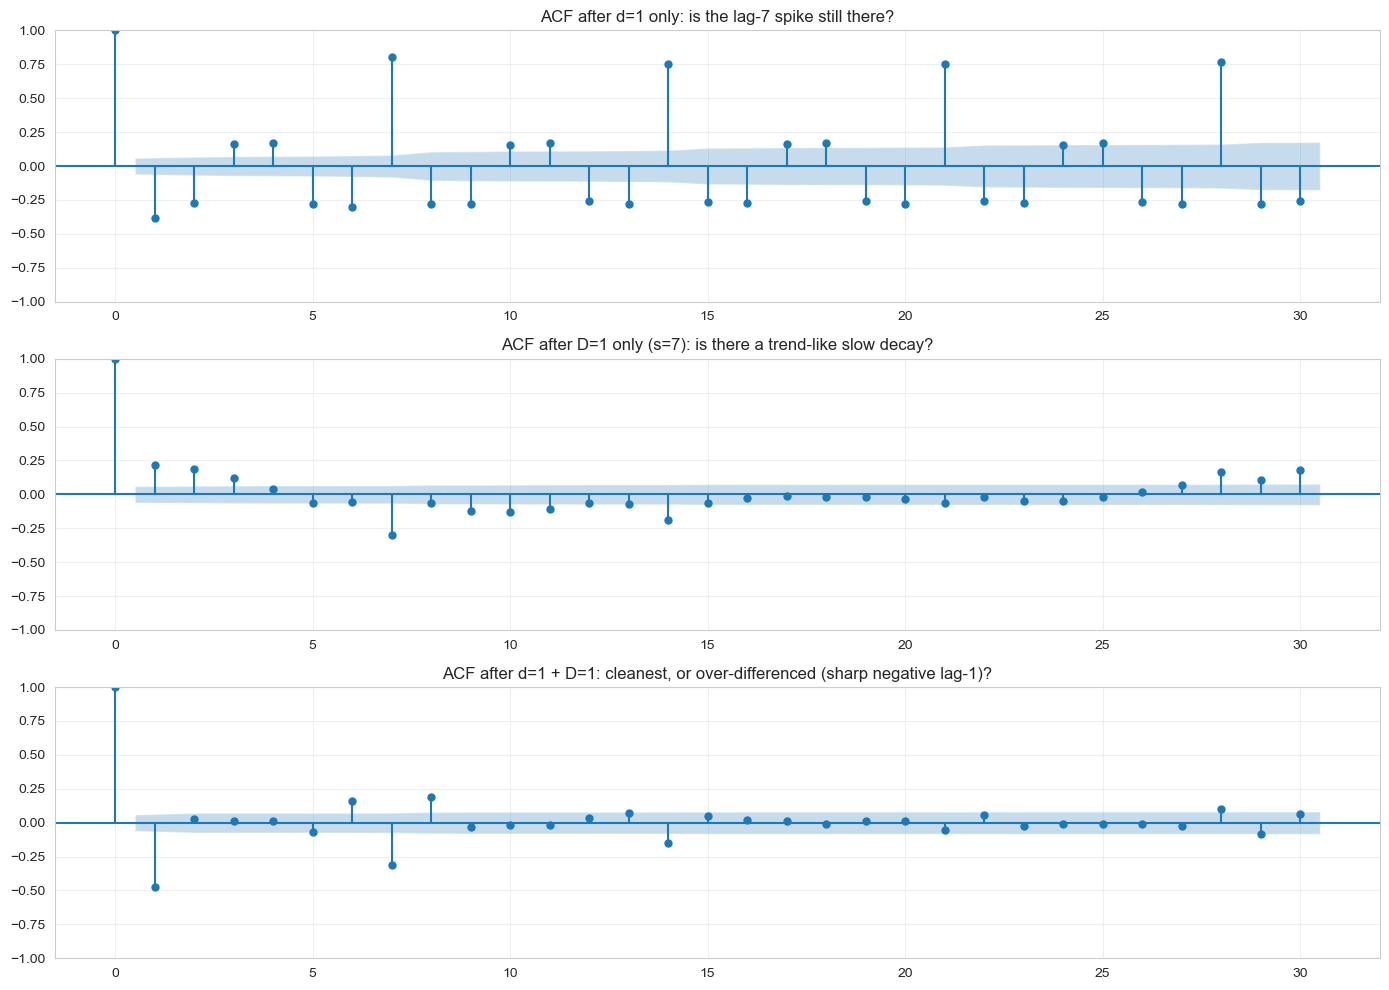

In [87]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10))

plot_acf(ts_diff1, lags=30, ax=axes[0], alpha=0.05)
axes[0].set_title('ACF after d=1 only: is the lag-7 spike still there?')
axes[0].grid(alpha=0.3)

plot_acf(ts_seasdiff, lags=30, ax=axes[1], alpha=0.05)
axes[1].set_title('ACF after D=1 only (s=7): is there a trend-like slow decay?')
axes[1].grid(alpha=0.3)

plot_acf(ts_diff1_seasdiff, lags=30, ax=axes[2], alpha=0.05)
axes[2].set_title('ACF after d=1 + D=1: cleanest, or over-differenced (sharp negative lag-1)?')
axes[2].grid(alpha=0.3)

plt.tight_layout(); plt.show()

#### ▪️<span style="color:purple">Notes</span>

- **d=1 only** still shows a spike at lag 7 (regular differencing removes trend, not weekly seasonality).
- **D=1 only** still shows a slower decay pattern (seasonal differencing removes the weekly cycle, but a residual trend can remain).
- **d=1 + D=1** shows neither, the standard choice for a series with both a confirmed trend and confirmed weekly seasonality (Step A). Watch for a large negative spike at lag 1, which would indicate over-differencing.


### Determine d and D Parameters

- **d = 0** (no regular differencing needed)
- **D = 1**, **s = 7** (seasonal differencing only)

**Reasoning**:
- `d=1` alone leaves the weekly seasonality completely intact (clear spikes at lags 7, 14, 21, 28), regular differencing removes trend, not the weekly cycle.
- `D=1` alone achieves stationarity (ADF) and produces the cleanest ACF of the three candidates, most lags fall inside the confidence band, with only a mild lag-1 (~0.22) and lag-7 (~-0.3) spike remaining.
- `d=1 + D=1` combined shows a strong negative spike at lag-1 (-0.48), a classic over-differencing signature, consistent with the combined case's *weaker* ADF statistic (-12.59) vs. d=1 alone (-14.61).
- The two remaining spikes in the D=1-only panel (mild lag-1, lag-7) are informative rather than a problem, they'll help identify the AR/MA and seasonal AR/MA terms (p, q, P, Q) in Step F2, using this same differenced series.

## 🔸Step E: Component Identification (trend, seasonality, cycle)

**Objective**: formally consolidate what's already been established (Steps A, B, D) into named components (trend, seasonality, cycle) and confirm the one open question: does the Nov/Dec effect repeat every year, or was it driven by a single year?


### Trend

Already established in Step A: sustained growth (+43.7% 2018→2021 | +32.8% 2018→2020), and the additive-vs-multiplicative decomposition showed the multiplicative model's residual stayed more stable over time, supporting a trend whose *absolute* size grows alongside the level, not a fixed dollar amount per period.

In [88]:
yearly_avg = df_complete[df_complete['Date'] <= train_end].groupby('year')['Sales_adj'].mean()
print(yearly_avg)

first_year, last_year = yearly_avg.index.min(), yearly_avg.index.max()
growth_pct = (yearly_avg[last_year] - yearly_avg[first_year]) / yearly_avg[first_year] * 100

print(f"\nAvg daily sales {first_year}: {yearly_avg[first_year]:,.2f}")
print(f"Avg daily sales {last_year}: {yearly_avg[last_year]:,.2f}")
print(f"Growth: {growth_pct:+.1f}%")

# Caveat check: is the last year a full year, or partial?
days_in_last_year = df_complete[(df_complete['Date'] <= train_end) & (df_complete['year'] == last_year)].shape[0]
print(f"\nDays counted in {last_year}: {days_in_last_year} (full year = 365/366)")

year
2018    1.817821e+06
2019    2.078317e+06
2020    2.414307e+06
Name: Sales_adj, dtype: float64

Avg daily sales 2018: 1,817,821.37
Avg daily sales 2020: 2,414,307.29
Growth: +32.8%

Days counted in 2020: 366 (full year = 365/366)


#### ▪️<span style="color:purple">Notes</span>

- **Result**: Avg daily sales grew from **$1.8M** (2018) to **$2.4M** (2020): a **+32.8%** increase, comparing two complete calendar years (365 and 366 days respectively).

- Step B's analysis already showed Jan–Feb/2021 ran unusually strong relative to the typical pattern.

- 2019 sits between the two ($2M), suggesting fairly steady year-over-year growth rather than one anomalous jump, consistent with the smooth upward trend line seen in Step A's plots.


### Seasonal Component Analysis

Weekly seasonality (`s=7`) is already confirmed (Step A's ACF, Step D's ADF/ACF on the D=1 differenced series). 
What's still open: is the Nov/Dec pattern (Seasonal_Index 1.056/1.199 from Step B) a genuine annual seasonality, or does it come from just one or two unusual years?

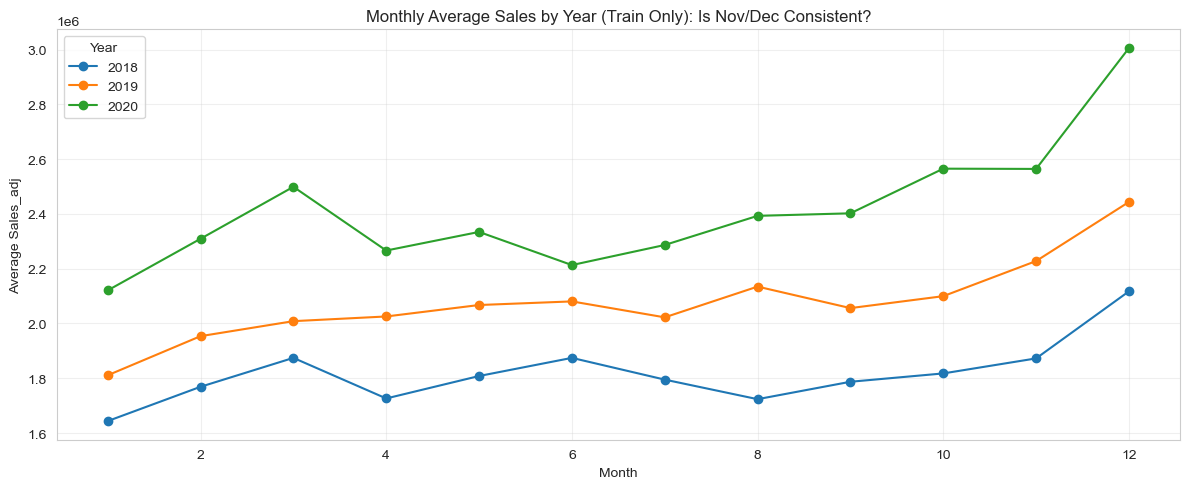

In [89]:
df_complete['Year'] = df_complete['Date'].dt.year

monthly_by_year = df_complete[df_complete['Date'] <= train_end].groupby(
    ['Year', 'month']
)['Sales_adj'].mean().unstack(level=0)

fig, ax = plt.subplots(figsize=(12, 5))
monthly_by_year.plot(ax=ax, marker='o')
ax.set_title('Monthly Average Sales by Year (Train Only): Is Nov/Dec Consistent?')
ax.set_xlabel('Month'); ax.set_ylabel('Average Sales_adj')
ax.legend(title='Year')
ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

#### ▪️<span style="color:purple">Notes</span>

- December rises in all three training years (2018, 2019, 2020), a consistent pattern across years supports treating `Seasonal_Index` as a genuine seasonal component rather than a one-off.

- *Caveat*: with only 3 years of training data, this is 3 observations per month, enough to spot a gross inconsistency, but not enough to rule out a subtler year-over-year drift.


### Cycle

Cycle refers to fluctuations longer than a year that aren't tied to a fixed calendar period (e.g., multi-year business cycles).
With only ~3 years of training data, this is difficult to separate from trend.


#### ▪️<span style="color:purple">Notes</span>

- With 3 years of data, a cycle (which by definition operates on a timescale longer than a year and isn't fixed-period) can't be reliably distinguished from the trend itself. 

- **Reasonable conclusion**: no cycle component is modeled separately. Its effects, if any, are absorbed into the trend term.

---

### Business Component Identification Summary

| Component | Finding | Evidence |
|---|---|---|
| **Trend** | Strong, sustained increase (+32.8%, 2018→2020); multiplicative in nature | Step A time series plot, decomposition residual comparison |
| **Seasonality: Weekly** | Confirmed, `s=7`; Saturday peak / Sunday trough (2.24x ratio) | Step A ACF/heatmap, Step D ACF on D=1 differenced series |
| **Seasonality: Monthly/Annual** | Concentrated in Nov/Dec (`Seasonal_Index` 1.056/1.199) | Step B seasonal index, this section's year-over-year chart |
| **Cycle** | Not modeled separately — indistinguishable from trend given only 3 years of data | This section |
| **Exogenous Effects** | `Pagamento` significant (+8.4%, p=0.0014); `Feriado` borderline (-11.6%, p=0.0645); `Vale` not significant | Part 1 bivariate analysis (Mann-Whitney) |


**Implication for Step F**: the series requires
1. a model that handles trend and weekly seasonality, SARIMA with `D=1, s=7` (Step D) or Holt-Winters with multiplicative trend/seasonal (Step A decomposition) and
2. `Pagamento` as the primary exogenous regressor candidate, with `Feriado` as a secondary one worth testing despite its borderline significance.

## 🔸Step F: Model Fitting

**Model selection based on components identified in Step E**: the series has both a trend and weekly seasonality, ruling out Simple Exponential Smoothing (no trend/season) and Holt's method (trend only). 

### Justifying the Move to Holt-Winters

Before jumping to Holt-Winters, let's confirm (rather than assume) that the simpler exponential smoothing methods aren't sufficient. 
**Simple Exponential Smoothing** (no trend/season) and **Holt**'s method (trend only) are fit here, and their residuals are tested for white noise (same Ljung-Box test as Step C). 
If real structure remains in the residuals, that's the evidence these simpler models are leaving patterns unmodeled.

- Key insight: do Simple/Holt's residuals still show significant autocorrelation, confirming a seasonal term is needed?

In [90]:
ts_train = ts_train.asfreq('D')
ts_holdout = ts_holdout.asfreq('D')

# Simple Exponential Smoothing: no trend, no seasonality
model_simple = SimpleExpSmoothing(ts_train).fit()
resid_simple = model_simple.resid

# Holt's method: trend, no seasonality
model_holt = Holt(ts_train).fit()
resid_holt = model_holt.resid

for name, resid in [('Simple Exp. Smoothing', resid_simple), ("Holt's (trend only)", resid_holt)]:
    lb = acorr_ljungbox(resid, lags=[7, 14], return_df=True)
    print(f"\n{name}: AIC = {model_simple.aic if 'Simple' in name else model_holt.aic:.1f}")
    print(lb)



Simple Exp. Smoothing: AIC = 29564.3
        lb_stat      lb_pvalue
7    787.181985  1.082432e-165
14  1472.876187  3.296345e-306

Holt's (trend only): AIC = 29921.9
        lb_stat      lb_pvalue
7    689.799165  1.090989e-144
14  1329.317613  2.657911e-275


#### ▪️<span style="color:purple">Notes</span>

- **Result**: both models fail decisively. 
    - Simple Exp. Smoothing: Ljung-Box p ≈ 1.08e-165 (lag 7); 
    - Holt's: p ≈ 1.09e-144 (lag 7), 
    - both far below any reasonable threshold, meaning strong autocorrelation remains in the residuals.

- Holt's AIC (29,921.9) is actually *worse* than Simple's (29,564.3), despite adding a trend term
    - the added complexity doesn't pay off while weekly seasonality is still unmodeled and dominating the residual structure.

- **Conclusion**: neither model captures the series adequately. The residual autocorrelation is consistent with the unmodeled weekly seasonality (lag 7) confirmed throughout Steps A–E. This formally justifies moving directly to Holt-Winters (adds the missing seasonal term) rather than testing intermediate trend-only models further.


### → Step F1: Exponential Smoothing

Given Step A's decomposition comparison (multiplicative residual stayed more stable over time than additive), `trend='mul'` and `seasonal='mul'` are the leading candidates, but all four combinations are compared here by AIC rather than assumed.


In [91]:
hw_candidates = {}
for trend_type in ['add', 'mul']:
    for seasonal_type in ['add', 'mul']:
        try:
            m = ExponentialSmoothing(
                ts_train, trend=trend_type, seasonal=seasonal_type,
                seasonal_periods=7, damped_trend=False
            ).fit()
            hw_candidates[f'trend={trend_type}, seasonal={seasonal_type}'] = m
            print(f"trend={trend_type}, seasonal={seasonal_type}  ->  AIC={m.aic:.1f}")
        except Exception as e:
            print(f"trend={trend_type}, seasonal={seasonal_type}  ->  failed ({e})")

# Also test damped trend on the best-performing combination once identified above

trend=add, seasonal=add  ->  AIC=28253.7
trend=add, seasonal=mul  ->  AIC=28264.9
trend=mul, seasonal=add  ->  AIC=28253.1
trend=mul, seasonal=mul  ->  AIC=28256.5


#### ▪️<span style="color:purple">Notes</span>

- **Result**: AICs are close across all four combinations (28,253.1–28,264.9). The winner is **trend=mul, seasonal=add** (AIC 28,253.1), though it's nearly tied with trend=add, seasonal=add (28,253.7), a 0.6-point gap is not a strong signal either way.

- **Note of caution**: this contradicts the expectation from Step A's decomposition (where the multiplicative model's residual looked more stable). Here, the *seasonal* component actually prefers additive in both top candidates.
    - the formal AIC comparison refines/complicates the earlier visual read.

- **Selected configuration**: `trend='mul', seasonal='add', seasonal_periods=7`: will also compare with `damped_trend=True` before finalizing.

#### Damped Trend Comparison

Testing whether damping the trend (letting growth flatten out over the forecast horizon, rather than continuing indefinitely) improves the winning configuration. Relevant since Step J forecasts 30 days out, where an undamped multiplicative trend can compound aggressively.

In [92]:
model_undamped = ExponentialSmoothing(
    ts_train, trend='mul', seasonal='add', seasonal_periods=7, damped_trend=False
).fit()

model_damped = ExponentialSmoothing(
    ts_train, trend='mul', seasonal='add', seasonal_periods=7, damped_trend=True
).fit()

print(f"Undamped: AIC = {model_undamped.aic:.1f}")
print(f"Damped:   AIC = {model_damped.aic:.1f}")

if hasattr(model_damped, 'params') and 'damping_trend' in model_damped.params:
    print(f"\nDamping parameter (phi): {model_damped.params['damping_trend']:.4f}")
    print("(phi close to 1.0 = minimal damping; phi well below 1.0 = meaningful flattening)")

Undamped: AIC = 28253.1
Damped:   AIC = 28259.2

Damping parameter (phi): 0.9950
(phi close to 1.0 = minimal damping; phi well below 1.0 = meaningful flattening)


##### ▪️<span style="color:purple">Notes</span>

- **Result**: undamped AIC = 28,253.1 vs. damped AIC = 28,259.2: damping worsens fit by 6.1 points.

- **Damping parameter (phi) = 0.995**, essentially equivalent to no damping (phi=1.0 = fully undamped), the model finds almost no evidence that trend growth is flattening within the training period.

- **Decision**: keep the **undamped** model. The extra damping parameter doesn't earn its complexity here, both by AIC and by the phi value itself showing negligible damping.

- **Caveat for Step J**: this doesn't mean growth will *literally* continue undamped forever, it means the training data (through Dec/2020) doesn't show enough of a flattening signal yet for the model to justify assuming one. Worth revisiting if the 30-day March/2021 forecast (Step J) looks implausibly aggressive, since Holt-Winters trend extrapolation can compound quickly over a forecast horizon even when phi is technically ~1.0.


#### Residual White Noise Check

Same Ljung-Box + ACF approach used for SARIMA's residuals, now applied to the final Holt-Winters model from F1 (`trend='mul', seasonal='add', seasonal_periods=7, damped_trend=False`).

- Key insight: does Holt-Winters leave more or less residual structure than SARIMA did?

       lb_stat     lb_pvalue
7    90.489996  9.813323e-17
14  136.064074  4.289963e-22
21  157.374445  6.892409e-23
30  213.191343  1.638668e-29


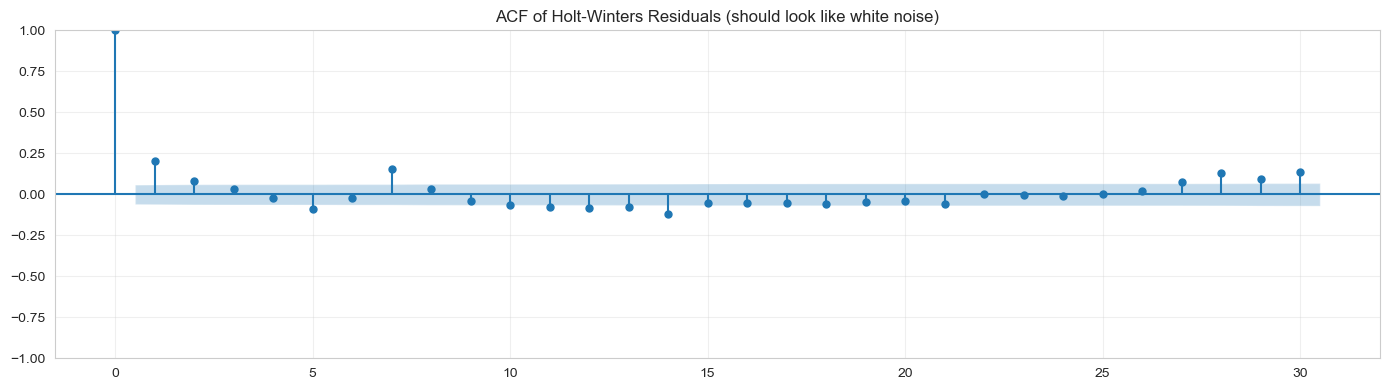

In [93]:
model_hw_final = ExponentialSmoothing(
    ts_train, trend='mul', seasonal='add', seasonal_periods=7, damped_trend=False
).fit()

residuals_hw = model_hw_final.resid

lb_resid_hw = acorr_ljungbox(residuals_hw, lags=[7, 14, 21, 30], return_df=True)
print(lb_resid_hw)

fig, ax = plt.subplots(figsize=(14, 4))
plot_acf(residuals_hw.dropna(), lags=30, ax=ax, alpha=0.05)
ax.set_title('ACF of Holt-Winters Residuals (should look like white noise)')
ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

##### ▪️<span style="color:purple">Notes</span>

- **Result**: all four lags fail decisively (p ≈ 1e-17 to 1e-29), Holt-Winters residuals show strong, unambiguous autocorrelation. Even lag 7, which SARIMA passed, fails here.

- **Interpretation**: this specific Holt-Winters configuration (trend='mul', seasonal='add') has not fully captured the series' structure, meaningful patterns remain in the residuals that the model isn't representing.

- **Likely cause**: Holt-Winters applies a single fixed seasonal shape and has no error/MA-type term to absorb residual autocorrelation, unlike SARIMA's `ma.L1`/`ma.S.L7` terms, which is consistent with SARIMA clearing the lag-7 test where Holt-Winters did not.

- **Takeaway**: on this white-noise criterion alone, there's more available signal being left on the table by the Holt-Winters model than by the SARIMA model, worth keeping in mind heading into Step G, though final selection should still weigh holdout accuracy (Step I) alongside this diagnostic, not this test in isolation.


#### ▫️Final F1 Model

**Configuration**: `ExponentialSmoothing(trend='mul', seasonal='add', seasonal_periods=7, damped_trend=False)`

This is F1's candidate to carry forward into Step G's model comparison against SARIMA/SARIMAX.


### → Step F2: ARIMA / SARIMA (identification, estimation, exogenous variables, coefficients)



#### Parameter Identification (p, q): Non-Seasonal

Using `ts_seasdiff` (`ts_train.diff(7)`), the series that achieved stationarity in Step D with **d=0, D=1, s=7**. The ACF informs `q`, the PACF informs `p`.

- Key insight: Where do the ACF/PACF cut off or decay, suggesting p and q?

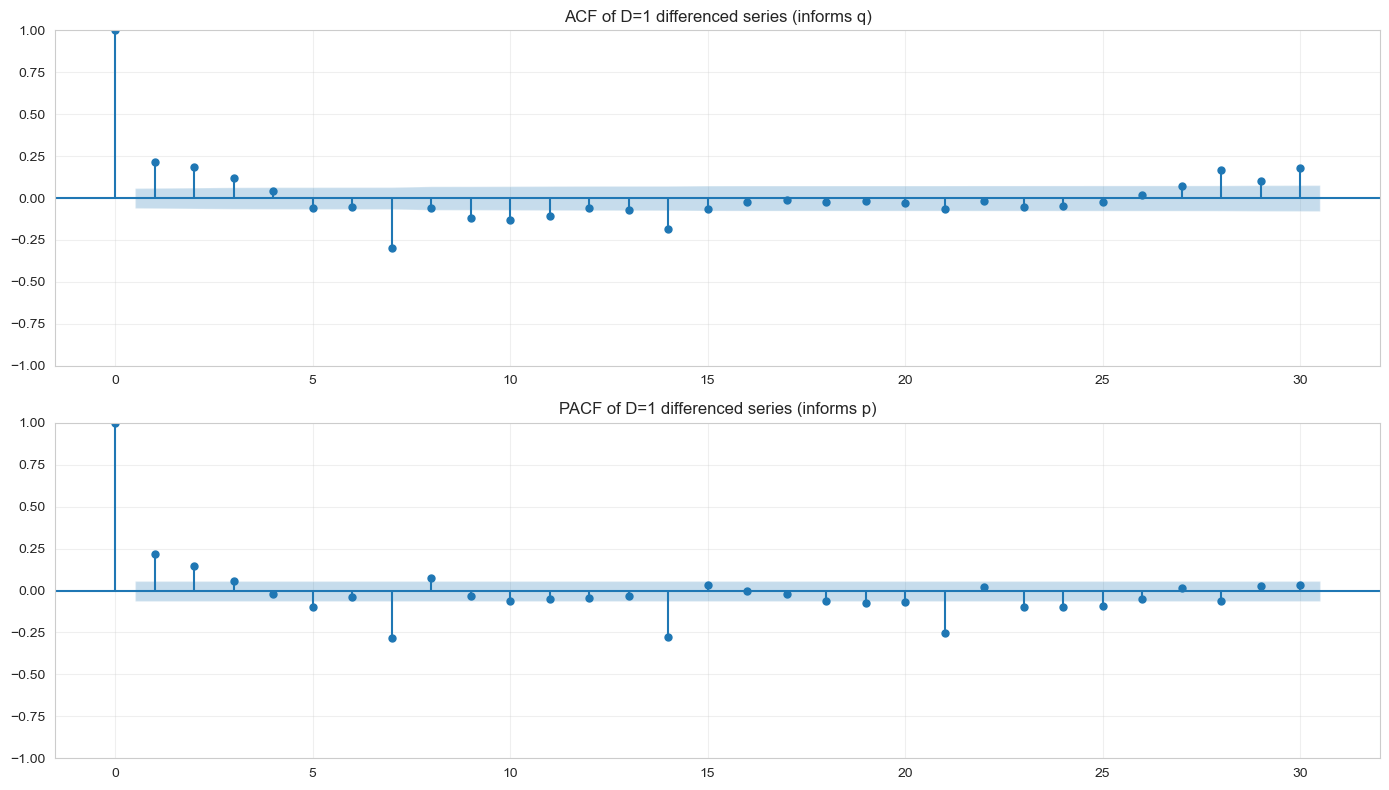

In [94]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8))

plot_acf(ts_seasdiff, lags=30, ax=ax1, alpha=0.05)
ax1.set_title('ACF of D=1 differenced series (informs q)')
ax1.grid(alpha=0.3)

plot_pacf(ts_seasdiff, lags=30, ax=ax2, alpha=0.05)
ax2.set_title('PACF of D=1 differenced series (informs p)')
ax2.grid(alpha=0.3)

plt.tight_layout(); plt.show()

##### ▪️<span style="color:purple">Notes</span>

- **q** (MA order): last lag with a significant spike in the ACF before it cuts off/decays (non-seasonal lags: 1, 2, 3...).

- **p** (AR order): last lag with a significant spike in the PACF (non-seasonal lags).

- Recall from Step D: the D=1-only panel showed a mild lag-1 spike (~0.22 ACF) and a residual lag-7 spike (~-0.3), expect lag-1 to be the main non-seasonal candidate here.

- PACF cuts off faster (lag 2–3) than the ACF decays (out to lag 3), the classic AR signature, suggesting **p ∈ {1, 2}, q = 0** as the starting hypothesis.

- The visual read isn't perfectly clean-cut (the panels decay gradually rather than showing one sharp spike), so rather than commit to a single combination by eye, the candidates below are tested in a grid search and selected by AIC, standard practice when ACF/PACF suggest a range rather than one obvious answer.


#### Parameter Identification (P, Q, s): Seasonal

Same ACF/PACF, now read at the seasonal lags (7, 14, 21...) rather than the early non-seasonal ones.

- Key insight: do the seasonal lags show a single clean spike (pure AR or MA), or persist across multiple seasonal lags in both panels (mixed)?

##### ▪️<span style="color:purple">Notes</span>

- **Q** (seasonal MA order): significant spike at the seasonal lags (7, 14, 21...) in the ACF.

- **P** (seasonal AR order): significant spike at the seasonal lags in the PACF.

- **s = 7** (weekly, confirmed since Step A).

- Significant spikes persist across lags 7, 14, and (in PACF) 21 in both ACF and PACF, a mixed seasonal pattern, suggesting **P = 1, Q = 1**, s = 7 as the starting hypothesis.

- As with the non-seasonal identification, this visual read is a starting range rather than a final answer, confirmed (or revised) by the grid search below.


**Candidates to test**:
- (p, d, q)
    - p ∈ {0, 1, 2}
    - d = 0
    - q ∈ {0, 1}

- (P, D, Q)s
    - P ∈ {0, 1}
    - D = 1
    - Q ∈ {0, 1}
    - s = 7

#### Grid Search: Selecting (p,q)(P,Q) by AIC

Testing the candidate range identified from the ACF/PACF (p ∈ {0,1,2}, q ∈ {0,1}, P ∈ {0,1}, Q ∈ {0,1}, with d=0, D=1, s=7 fixed from Step D) and ranking by AIC/BIC.

- Key insight: which combination wins, and does it match the p=1-2, q=0, P=1, Q=1 hypothesis from the visual read?

In [95]:
d, D, s = 0, 1, 7
p_range = range(0, 3)
q_range = range(0, 2)
P_range = range(0, 2)
Q_range = range(0, 2)

results = []
warnings.filterwarnings('ignore')

for p, q, P, Q in itertools.product(p_range, q_range, P_range, Q_range):
    try:
        model = sm.tsa.statespace.SARIMAX(
            ts_train,
            order=(p, d, q),
            seasonal_order=(P, D, Q, s),
            enforce_stationarity=False,
            enforce_invertibility=False
        ).fit(disp=False)
        results.append({
            'order': (p, d, q), 'seasonal_order': (P, D, Q, s),
            'AIC': model.aic, 'BIC': model.bic
        })
    except Exception as e:
        continue

warnings.filterwarnings('default')

results_df = pd.DataFrame(results).sort_values('AIC').reset_index(drop=True)
# print(results_df.head(20))

In [96]:
print(results_df.sort_values('AIC', ascending=True))

        order seasonal_order           AIC           BIC
0   (1, 0, 1)   (1, 1, 1, 7)  30919.006135  30943.929717
1   (2, 0, 1)   (1, 1, 1, 7)  30920.655125  30950.563423
2   (2, 0, 0)   (1, 1, 1, 7)  30923.344010  30948.267592
3   (2, 0, 1)   (0, 1, 1, 7)  30927.515502  30952.439083
4   (1, 0, 1)   (0, 1, 1, 7)  30934.000897  30953.939762
5   (0, 0, 1)   (1, 1, 1, 7)  30960.606516  30980.545381
6   (2, 0, 0)   (0, 1, 1, 7)  30967.161564  30987.104131
7   (0, 0, 1)   (0, 1, 1, 7)  30970.171422  30985.125571
8   (1, 0, 0)   (1, 1, 1, 7)  30970.820649  30990.763216
9   (1, 0, 0)   (0, 1, 1, 7)  30982.321250  30997.278175
10  (0, 0, 0)   (1, 1, 1, 7)  31006.810183  31021.767109
11  (0, 0, 0)   (0, 1, 1, 7)  31018.816403  31028.787687
12  (2, 0, 1)   (1, 1, 0, 7)  31083.415721  31108.339303
13  (2, 0, 0)   (1, 1, 0, 7)  31084.208442  31104.147307
14  (1, 0, 1)   (1, 1, 0, 7)  31111.622206  31131.564773
15  (1, 0, 0)   (1, 1, 0, 7)  31128.083083  31143.040009
16  (0, 0, 1)   (1, 1, 0, 7)  3

##### ▪️<span style="color:purple">Notes</span>

- Full grid confirms the earlier result: **(1,0,1)(1,1,1,7)** wins on both AIC (30,919.0) and BIC (30,943.9).

- Pattern across the table: the seasonal MA term (Q=1) drives the largest AIC improvements, e.g., (1,0,1) alone improves from 31,382.9 (Q=0,P=0) to 30,919.0 (P=1,Q=1), a ~460-point gain. This confirms weekly seasonality (already established in Steps A/D) is the dominant structural signal the model needs to capture, more so than fine-tuning the non-seasonal AR/MA terms.

- The weakest model, (0,0,0)(0,1,0,7) (differencing alone, no ARMA terms) ranks last (AIC 31,480.7), confirming that ARMA structure adds real explanatory value beyond simple seasonal differencing.

- **Final selected parameters**: p=1, d=0, q=1, P=1, D=1, Q=1, s=7


#### Model Family Comparison: ARMA → ARIMA → SARIMA → SARIMAX

Rather than jumping straight to the final SARIMA/SARIMAX, this section fits the intermediate model families using the same (p,q)=(1,1) identified above, progressively adding what each earlier step showed was missing:

- **ARMA(1,1)**: no differencing at all, included as a baseline, despite Step D confirming the raw series is non-stationary.
- **ARIMA(1,1,1)**: regular differencing only (d=1), Step D showed this removes trend but leaves weekly seasonality (lags 7/14/21) fully intact.
- **SARIMA(1,0,1)(1,1,1,7)**: adds seasonal differencing/terms, the model selected via the grid search above.
- **SARIMAX**: SARIMA + `Pagamento`, `Feriado`, `Seasonal_Index`, the final model from this section.

Each is evaluated on both training fit (AIC/BIC) and holdout accuracy (MAE/RMSE/MAPE).

- Key insight: does each added layer of complexity improve holdout accuracy, or does it plateau/reverse, echoing the F1-vs-F2 result from Step G?

In [97]:
model_family_results = []

# Local setup: holdout actuals, excluding isClosed days
isclosed_holdout = df_complete.set_index('Date').loc[ts_holdout.index, 'isClosed']
holdout_mask = isclosed_holdout == 0
actual_holdout = ts_holdout[holdout_mask]

##### Model Estimation: ARMA

In [98]:
# 1. ARMA(1,1) -- no differencing
model_arma = sm.tsa.statespace.SARIMAX(
    ts_train, order=(1, 0, 1), seasonal_order=(0, 0, 0, 0),
    enforce_stationarity=False, enforce_invertibility=False
).fit(disp=False)
forecast_arma = model_arma.get_forecast(steps=len(ts_holdout)).predicted_mean
metrics_arma = evaluate_forecast(actual_holdout, forecast_arma.loc[actual_holdout.index], 'ARMA(1,1)')
model_family_results.append({**metrics_arma, 'AIC': model_arma.aic, 'BIC': model_arma.bic})

print(model_arma.summary())

                               SARIMAX Results                                
Dep. Variable:              Sales_adj   No. Observations:                 1096
Model:               SARIMAX(1, 0, 1)   Log Likelihood              -16324.681
Date:                Sun, 02 Aug 2026   AIC                          32655.362
Time:                        22:08:15   BIC                          32670.355
Sample:                    01-01-2018   HQIC                         32661.035
                         - 12-31-2020                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          1.0008      0.001   1179.141      0.000       0.999       1.002
ma.L1         -0.9390      0.013    -72.676      0.000      -0.964      -0.914
sigma2      6.927e+11   1.03e-15   6.76e+26      0.0

##### Model Estimation: ARIMA

In [99]:
# 2. ARIMA(1,1,1) -- regular differencing, no seasonal terms
model_arima = sm.tsa.statespace.SARIMAX(
    ts_train, order=(1, 1, 1), seasonal_order=(0, 0, 0, 0),
    enforce_stationarity=False, enforce_invertibility=False
).fit(disp=False)
forecast_arima = model_arima.get_forecast(steps=len(ts_holdout)).predicted_mean
metrics_arima = evaluate_forecast(actual_holdout, forecast_arima.loc[actual_holdout.index], 'ARIMA(1,1,1)')
model_family_results.append({**metrics_arima, 'AIC': model_arima.aic, 'BIC': model_arima.bic})

print(model_arima.summary())

                               SARIMAX Results                                
Dep. Variable:              Sales_adj   No. Observations:                 1096
Model:               SARIMAX(1, 1, 1)   Log Likelihood              -16298.130
Date:                Sun, 02 Aug 2026   AIC                          32602.260
Time:                        22:08:15   BIC                          32617.251
Sample:                    01-01-2018   HQIC                         32607.933
                         - 12-31-2020                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0028      0.038     -0.073      0.942      -0.078       0.073
ma.L1         -0.9369      0.014    -67.120      0.000      -0.964      -0.910
sigma2      6.343e+11   1.11e-14   5.74e+25      0.0

In [100]:
family_comparison_df = pd.DataFrame(model_family_results)[['Model','AIC','BIC','MAE','RMSE','MAPE']]
print(family_comparison_df.to_string(index=False))

       Model          AIC          BIC           MAE          RMSE      MAPE
   ARMA(1,1) 32655.361755 32670.354543 817223.633127 917546.543811 33.800462
ARIMA(1,1,1) 32602.260461 32617.250506 754760.931569 868400.047979 30.762678


##### Model Estimation: SARIMA

Fitting the selected model **(1,0,1)(1,1,1,7)** on `ts_train`, then checking whether its residuals behave like white noise (same Ljung-Box + ACF approach as Step C) before considering exogenous variables.

- Key insight: do the residuals pass the white noise check, confirming the model has captured the available structure?

In [101]:
model_sarima = sm.tsa.statespace.SARIMAX(
    ts_train,
    order=(1, 0, 1),
    seasonal_order=(1, 1, 1, 7),
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False)

forecast_sarima = model_sarima.get_forecast(steps=len(ts_holdout)).predicted_mean
metrics_sarima = evaluate_forecast(actual_holdout, forecast_sarima.loc[actual_holdout.index], 'SARIMA(1,0,1)(1,1,1,7)')
model_family_results.append({**metrics_sarima, 'AIC': model_sarima.aic, 'BIC': model_sarima.bic})

print(model_sarima.summary())

                                     SARIMAX Results                                     
Dep. Variable:                         Sales_adj   No. Observations:                 1096
Model:             SARIMAX(1, 0, 1)x(1, 1, 1, 7)   Log Likelihood              -15454.503
Date:                           Sun, 02 Aug 2026   AIC                          30919.006
Time:                                   22:08:16   BIC                          30943.930
Sample:                               01-01-2018   HQIC                         30928.443
                                    - 12-31-2020                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.7331      0.048     15.304      0.000       0.639       0.827
ma.L1         -0.4942      0.061     -8.115

###### Residual White Noise Check

Same test as Step C, now applied to the model's residuals instead of the raw series, this time we *want* to fail to reject H0 (residuals = white noise = no structure left to capture).

- H0: residuals are white noise (model has captured all available structure). 
- H1: residuals still have structure (model is missing something).
- Decision rule: p-value > 0.05 across the tested lags → good, no significant leftover structure.

      lb_stat  lb_pvalue
7   11.790191   0.107673
14  28.053798   0.013996
21  35.660157   0.023866
30  74.261783   0.000013


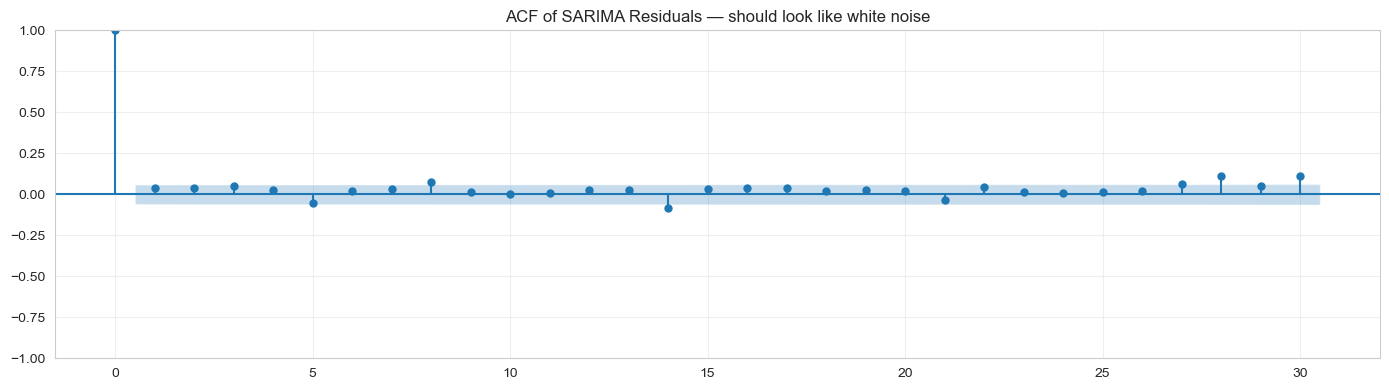

In [102]:
residuals_sarima = model_sarima.resid

lb_resid = acorr_ljungbox(residuals_sarima, lags=[7, 14, 21, 30], return_df=True)
print(lb_resid)

fig, ax = plt.subplots(figsize=(14, 4))
plot_acf(residuals_sarima.dropna(), lags=30, ax=ax, alpha=0.05)
ax.set_title('ACF of SARIMA Residuals — should look like white noise')
ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

###### ▪️<span style="color:purple">Notes</span>

- **Ljung-Box on residuals**: passes at lag 7 (p=0.108) but fails at lags 14, 21, 30 (p=0.014, 0.024, 0.000013), the model captures the immediate weekly pattern but leaves longer-range structure unexplained.

- **Answering the white noise question directly**: yes, there are still patterns to uncover, SARIMA has captured the dominant weekly (lag-7) signal, but something beyond a single week is still leaking into the residuals.

- **Hypothesis for the remaining structure**: `Pagamento` and `Feriado` don't follow a clean 7-day rhythm (paydays land on a specific business day of the month; holidays are calendar-fixed), a pure seasonal ARMA structure has no way to represent that kind of event-driven timing. These are natural candidates for explaining the lag-14/21/30 autocorrelation that remains.

- **Next step**: fit SARIMAX with `Pagamento`, `Vale` and `Feriado` as exogenous regressors (even `the seasonality index created by month) and re-run this same Ljung-Box test, if the lag-14+ p-values move above 0.05, that's direct evidence the exogenous variables are absorbing the leftover structure rather than being added speculatively.


##### Model Estimation: SARIMAX (SARIMA with Exogenous Variables)

Testing whether `Pagamento`, `Feriado`, `Vale`, `isClosed` and `Seasonal_Index` explain the lag-14/21/30 residual structure the base SARIMA left uncaptured. 

- Key insight: do the exogenous coefficients come out significant, and does the Ljung-Box test now pass at lags 14/21/30?

In [103]:
exog_cols = ['Pagamento', 'Feriado', 'Vale', 'isClosed', 'Seasonal_Index']

exog_train = df_complete.set_index('Date').loc[ts_train.index, exog_cols].asfreq('D')
exog_holdout_forecast = df_complete.set_index('Date').loc[ts_holdout.index, exog_cols].asfreq('D')

model_sarimax_1 = sm.tsa.statespace.SARIMAX(
    ts_train,
    exog=exog_train,
    order=(1, 0, 1),
    seasonal_order=(1, 1, 1, 7),
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False)

forecast_sarimax = model_sarimax_1.get_forecast(steps=len(ts_holdout), exog=exog_holdout_forecast).predicted_mean
metrics_sarimax = evaluate_forecast(actual_holdout, forecast_sarimax.loc[actual_holdout.index], 'SARIMAX(1,0,1)(1,1,1,7) X: Pagamento/Feriado/Vale/isClosed/Seasonal_Index')
model_family_results.append({**metrics_sarimax, 'AIC': model_sarimax_1.aic, 'BIC': model_sarimax_1.bic})

print(model_sarimax_1.summary())

                                     SARIMAX Results                                     
Dep. Variable:                         Sales_adj   No. Observations:                 1096
Model:             SARIMAX(1, 0, 1)x(1, 1, 1, 7)   Log Likelihood              -15274.738
Date:                           Sun, 02 Aug 2026   AIC                          30569.476
Time:                                   22:08:17   BIC                          30619.323
Sample:                               01-01-2018   HQIC                         30588.350
                                    - 12-31-2020                                         
Covariance Type:                             opg                                         
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
Pagamento       1.973e+05   8.74e+04      2.257      0.024     2.6e+04    3.69e+05
Feriado        -3.197e+05   4.9

###### ▪️<span style="color:purple">Notes</span>

**Model included 5 exogenous variables** (`Pagamento`, `Feriado`, `Vale`, `isClosed`, `Seasonal_Index`) findings below cover all five as run.

- **Pagamento**: coef +1.97e5, p=0.024
    - **significant**, consistent with Part 1's Mann-Whitney result (p=0.0014).

- **Feriado**: coef -3.20e5, p<0.001
    - now **clearly significant**, notably stronger than Part 1's Mann-Whitney result (p=0.0645, borderline). 
    - Once trend/seasonality/other exogenous effects are controlled for, which SARIMAX does and a simple group-mean comparison doesn't, the holiday effect comes through much more clearly. 
    - Resolves the earlier open question about whether Feriado's raw effect was reliable.

- **Vale**: coef -6.10e4, p=0.277
    - **not significant**, consistent with Part 1's Mann-Whitney result (p=0.52). 
    - Candidate to drop from a refined model.

- **isClosed**: coef -2.25e6, p<0.001
    - **hugely significant**, but near-tautological (sales ≈ 0 on those 7 days by construction, same relationship flagged in Part 1's correlation check, r=-0.220). 
    - **Decision needed**: let the model *learn* this coefficient, or *enforce* forecast≈0 on isClosed dates as a hard rule in Step J instead.

- **Seasonal_Index**: coef +1.48e6, p<0.001
    - **strongly significant**, confirming the Nov/Dec effect from Step E adds real explanatory power beyond the base seasonal ARMA structure.


**Fit improvement**: AIC 30,569.5 / BIC 30,619.3, vs. base SARIMA's 30,919.0 / 30,943.9, a ~350-point AIC improvement, easily earning the added complexity.


**Diagnostics improved alongside fit**: numerical stability condition number improved (6.26e25 vs. base model's 1.06e39, though still flagged), and non-normality eased (JB=2,382, kurtosis=10.1 vs. base model's 14,647/20.9), the exogenous variables are absorbing some of what was producing the most extreme residuals.


**Still open**: the built-in `Prob(Q)=0.83` in the summary is only the lag-1 diagnostic, the fuller Ljung-Box test (lags 7/14/21/30) from the dedicated residual-check cell hasn't been run on this SARIMAX model yet. That's the test that will confirm whether the exogenous variables actually resolved the lag-14+ structure the base SARIMA left uncaptured.


**Next steps**:
1. run the full Ljung-Box check on `model_sarimax.resid`, 
2. decide whether to drop `Vale` given its non-significance, 
    - Let's drop `Vale`.
3. decide how `isClosed` should be handled going into Step J.
    - Better to enforce 0 everytime these days are in the prediction horizon.


#### Refitting SARIMAX: Final Exogenous Set

Based on the decisions above: **`Vale` dropped** (not significant, p=0.277). 
**`isClosed` dropped from the fitted exogenous set**, rather than let the model estimate its effect, it will be enforced as a hard rule in Step J (force forecast ≈ 0 whenever a future date falls on Dec-25 or Jan-01), which is more robust than relying on a learned coefficient for a near-deterministic outcome.

Final exogenous set: **`Pagamento`, `Feriado`, `Seasonal_Index`**.

In [104]:
exog_cols_final = ['Pagamento', 'Feriado', 'Seasonal_Index']

exog_train_final = df_complete.set_index('Date').loc[ts_train.index, exog_cols_final].asfreq('D')
exog_holdout_forecast_final = df_complete.set_index('Date').loc[ts_holdout.index, exog_cols_final].asfreq('D')

model_sarimax = sm.tsa.statespace.SARIMAX(
    ts_train,
    exog=exog_train_final,
    order=(1, 0, 1),
    seasonal_order=(1, 1, 1, 7),
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False)

forecast_sarimax = model_sarimax.get_forecast(steps=len(ts_holdout), exog=exog_holdout_forecast_final).predicted_mean
metrics_sarimax = evaluate_forecast(actual_holdout, forecast_sarimax.loc[actual_holdout.index], 'SARIMAX(1,0,1)(1,1,1,7) X: Pagamento/Feriado/Seasonal_Index')
model_family_results.append({**metrics_sarimax, 'AIC': model_sarimax.aic, 'BIC': model_sarimax.bic})

print(model_sarimax.summary())

                                     SARIMAX Results                                     
Dep. Variable:                         Sales_adj   No. Observations:                 1096
Model:             SARIMAX(1, 0, 1)x(1, 1, 1, 7)   Log Likelihood              -15408.063
Date:                           Sun, 02 Aug 2026   AIC                          30832.125
Time:                                   22:08:18   BIC                          30872.003
Sample:                               01-01-2018   HQIC                         30847.225
                                    - 12-31-2020                                         
Covariance Type:                             opg                                         
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
Pagamento       1.981e+05   1.17e+05      1.694      0.090   -3.11e+04    4.27e+05
Feriado        -3.158e+05   5.7

In [105]:
family_comparison_df = pd.DataFrame(model_family_results)[['Model','AIC','BIC','MAE','RMSE','MAPE']]
print(family_comparison_df.to_string(index=False))

                                                                    Model          AIC          BIC           MAE          RMSE      MAPE
                                                                ARMA(1,1) 32655.361755 32670.354543 817223.633127 917546.543811 33.800462
                                                             ARIMA(1,1,1) 32602.260461 32617.250506 754760.931569 868400.047979 30.762678
                                                   SARIMA(1,0,1)(1,1,1,7) 30919.006135 30943.929717 548190.462822 679327.872521 21.793156
SARIMAX(1,0,1)(1,1,1,7) X: Pagamento/Feriado/Vale/isClosed/Seasonal_Index 30569.475503 30619.322666 420205.617953 503946.204139 16.529521
              SARIMAX(1,0,1)(1,1,1,7) X: Pagamento/Feriado/Seasonal_Index 30832.125217 30872.002947 492504.642113 566726.819527 18.989159


##### ▪️<span style="color:purple">Notes</span>

- **Pagamento**: p rose to 0.090 (not significant at α=0.05), up from p=0.024 in the 5-variable version and p=0.0014 in Part 1's Mann-Whitney test. Coefficient itself barely changed (1.981e5 vs. 1.973e5), the shift is driven by a wider standard error (1.17e5 vs. 8.74e4), a side effect of removing `isClosed`, which leaves more unexplained variance in the residuals overall. Not evidence the effect isn't real, a consequence of the isClosed decision.

- **Feriado**: remains clearly significant (p<0.001), coefficient stable (-3.16e5 vs. -3.20e5).

- **Seasonal_Index**: remains clearly significant (p<0.001), coefficient stable (+1.50e6 vs. +1.48e6).

- **Fit**: AIC 30,832.1 / BIC 30,872.0, worse than the 5-variable version (30,569.5/30,619.3) by ~262 points, but still ~87 points better than the base SARIMA (30,919.0), the leaner 3-variable set still adds real value, just less than the full 5-variable set did.

- **Diagnostics**: JB/kurtosis reverted close to base-model levels (13,804/20.5 vs. base 14,647/20.9), confirming `isClosed` was absorbing much of the extreme-residual behavior. This is an accepted trade-off from moving `isClosed` to a Step J hard rule rather than a fitted coefficient.

- **Still open**: full Ljung-Box (lags 7/14/21/30) hasn't been run on this final model yet, that's the test that confirms whether Pagamento/Feriado/Seasonal_Index resolved the lag-14+ structure on their own, without isClosed's help.



#### Residual White Noise Check

- H0: residuals are white noise (model has captured all available structure). 
- H1: residuals still have structure (model is missing something).
- Decision rule: p-value > 0.05 across the tested lags → good, no significant leftover structure.

      lb_stat  lb_pvalue
7   11.636230   0.113174
14  25.482955   0.030088
21  28.447024   0.127923
30  55.549360   0.003075


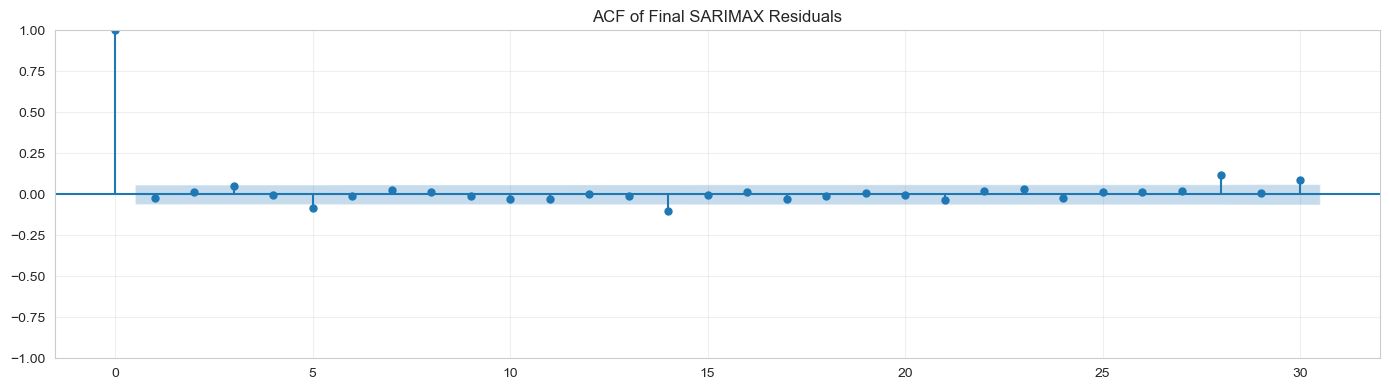

In [106]:
residuals_sarimax = model_sarimax.resid

lb_resid_sarimax = acorr_ljungbox(residuals_sarimax, lags=[7, 14, 21, 30], return_df=True)
print(lb_resid_sarimax)

fig, ax = plt.subplots(figsize=(14, 4))
plot_acf(residuals_sarimax.dropna(), lags=30, ax=ax, alpha=0.05)
ax.set_title('ACF of Final SARIMAX Residuals')
ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

##### ▪️<span style="color:purple">Notes</span>

- **Result**: Lag 7 passes (p=0.113, consistent with base SARIMA). Lag 21 now passes (p=0.128, improved from base SARIMA's failing p=0.024), a genuine win. Lags 14 and 30 still fail (p=0.030, p=0.003), though both improved substantially from the base model (p=0.014→0.030, p=0.000013→0.003).

- **Conclusion**: `Pagamento`, `Feriado`, and `Seasonal_Index` explain part, but not all, of the residual structure the base SARIMA left behind. The hypothesis is partially confirmed, exogenous variables help, but some pattern remains, particularly at the monthly (lag ~30) horizon.

- **Plausible remaining source**: `Vale` (17th business day, a monthly-not-weekly event) was deliberately excluded for non-significance in isolation, but it's the one dropped variable tied to a non-weekly rhythm that could still explain some of the lag-21/28-adjacent structure. Worth a documented limitation rather than re-adding it purely to force a pass, given its own earlier test was clearly not significant on its own.

- **Decision**: given the improvement is real but incomplete, this is a reasonable point to accept the current 3-variable SARIMAX as the working model for Step G's comparison, while explicitly noting the residual limitation (some non-white-noise structure remains, primarily near the monthly horizon) as part of Step H's diagnostics rather than treating it as fully resolved.


#### Testing `Vale` as a 4th Exogenous Variable

Re-adding `Vale` (monthly, 17th business day, the one dropped variable tied to a non-weekly rhythm) to check whether it resolves the remaining lag-14/30 structure, while keeping `isClosed` excluded per the Step J hard-rule decision.

- Key insight: does adding Vale back close the gap at lags 14/30, and is its coefficient significant this time in a leaner model?

In [107]:
exog_cols_v2 = ['Pagamento', 'Feriado', 'Seasonal_Index', 'Vale']

exog_train_v2 = df_complete.set_index('Date').loc[ts_train.index, exog_cols_v2].asfreq('D')
exog_holdout_v2 = df_complete.set_index('Date').loc[ts_holdout.index, exog_cols_v2].asfreq('D')

model_sarimax_v2 = sm.tsa.statespace.SARIMAX(
    ts_train,
    exog=exog_train_v2,
    order=(1, 0, 1),
    seasonal_order=(1, 1, 1, 7),
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False)

forecast_sarimax_v2 = model_sarimax_v2.get_forecast(steps=len(ts_holdout), exog=exog_holdout_v2).predicted_mean
metrics_sarimax_v2 = evaluate_forecast(actual_holdout, forecast_sarimax_v2.loc[actual_holdout.index], 'SARIMAX(1,0,1)(1,1,1,7) X: Pagamento/Feriado/Seasonal_Index/Vale')
model_family_results.append({**metrics_sarimax_v2, 'AIC': model_sarimax_v2.aic, 'BIC': model_sarimax_v2.bic})

print(model_sarimax_v2.summary())

                                     SARIMAX Results                                     
Dep. Variable:                         Sales_adj   No. Observations:                 1096
Model:             SARIMAX(1, 0, 1)x(1, 1, 1, 7)   Log Likelihood              -15409.455
Date:                           Sun, 02 Aug 2026   AIC                          30836.910
Time:                                   22:08:19   BIC                          30881.772
Sample:                               01-01-2018   HQIC                         30853.897
                                    - 12-31-2020                                         
Covariance Type:                             opg                                         
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
Pagamento       1.973e+05   1.18e+05      1.665      0.096   -3.49e+04    4.29e+05
Feriado        -3.197e+05   5.7

In [108]:
residuals_sarimax_v2 = model_sarimax_v2.resid

lb_resid_v2 = acorr_ljungbox(residuals_sarimax_v2, lags=[7, 14, 21, 30], return_df=True)
print(lb_resid_v2)

      lb_stat  lb_pvalue
7   11.354783   0.123875
14  25.036715   0.034207
21  28.071544   0.138134
30  53.983333   0.004617


##### ▪️<span style="color:purple">Notes</span>

- **Vale**: p=0.235, not significant, the third independent test to reach this conclusion (Mann-Whitney p=0.52 in Part 1; 5-variable SARIMAX p=0.277; this 4-variable SARIMAX p=0.235). Consistent evidence across three different tests that Vale has no meaningful relationship with sales at this level of aggregation.

- **Fit**: AIC 30,836.9 vs. the 3-variable model's 30,832.1, Vale costs 4.8 AIC points rather than improving fit; the added parameter isn't earning its complexity.

- **Ljung-Box**: essentially unchanged from the 3-variable model (lag 14: 0.030→0.034, lag 21: 0.128→0.138, lag 30: 0.003→0.005), differences are negligible, confirming Vale is not the source of the remaining lag-14/30 structure.

- **Decision**: reject `Vale` as a regressor. **Final SARIMAX model: `Pagamento`, `Feriado`, `Seasonal_Index`** (order=(1,0,1), seasonal_order=(1,1,1,7)).

- **Documented limitation carried into Step H**: some residual structure remains at lags 14 and 30 that this model doesn't explain. Tested candidates (Vale) have been ruled out as the cause; the remaining structure is left as an acknowledged limitation rather than chased further, since continuing to add untested variables risks overfitting to the training data without a clear business hypothesis behind them.


#### Comparison

In [109]:
family_comparison_df = pd.DataFrame(model_family_results)[['Model','AIC','BIC','MAE','RMSE','MAPE']]
print(family_comparison_df.to_string(index=False))

                                                                    Model          AIC          BIC           MAE          RMSE      MAPE
                                                                ARMA(1,1) 32655.361755 32670.354543 817223.633127 917546.543811 33.800462
                                                             ARIMA(1,1,1) 32602.260461 32617.250506 754760.931569 868400.047979 30.762678
                                                   SARIMA(1,0,1)(1,1,1,7) 30919.006135 30943.929717 548190.462822 679327.872521 21.793156
SARIMAX(1,0,1)(1,1,1,7) X: Pagamento/Feriado/Vale/isClosed/Seasonal_Index 30569.475503 30619.322666 420205.617953 503946.204139 16.529521
              SARIMAX(1,0,1)(1,1,1,7) X: Pagamento/Feriado/Seasonal_Index 30832.125217 30872.002947 492504.642113 566726.819527 18.989159
         SARIMAX(1,0,1)(1,1,1,7) X: Pagamento/Feriado/Seasonal_Index/Vale 30836.909713 30881.772160 497277.927366 572441.469823 19.206209


In [110]:
print(family_comparison_df.sort_values('AIC', ascending=True).to_string(index=False))

                                                                    Model          AIC          BIC           MAE          RMSE      MAPE
SARIMAX(1,0,1)(1,1,1,7) X: Pagamento/Feriado/Vale/isClosed/Seasonal_Index 30569.475503 30619.322666 420205.617953 503946.204139 16.529521
              SARIMAX(1,0,1)(1,1,1,7) X: Pagamento/Feriado/Seasonal_Index 30832.125217 30872.002947 492504.642113 566726.819527 18.989159
         SARIMAX(1,0,1)(1,1,1,7) X: Pagamento/Feriado/Seasonal_Index/Vale 30836.909713 30881.772160 497277.927366 572441.469823 19.206209
                                                   SARIMA(1,0,1)(1,1,1,7) 30919.006135 30943.929717 548190.462822 679327.872521 21.793156
                                                             ARIMA(1,1,1) 32602.260461 32617.250506 754760.931569 868400.047979 30.762678
                                                                ARMA(1,1) 32655.361755 32670.354543 817223.633127 917546.543811 33.800462


#### ▪️<span style="color:purple">Notes</span>

**Full model family comparison** (including the reconsidered 5-variable SARIMAX):

| Model | AIC | BIC | MAE | RMSE | MAPE |
|---|---|---|---|---|---|
| SARIMAX + Pagamento/Feriado/Vale/isClosed/Seasonal_Index | **30,569.5** | **30,619.3** | **420,206** | **503,946** | **16.5%** |
| SARIMAX + Pagamento/Feriado/Seasonal_Index | 30,832.1 | 30,872.0 | 492,505 | 566,727 | 19.0% |
| SARIMAX + Pagamento/Feriado/Seasonal_Index/Vale | 30,836.9 | 30,881.8 | 497,278 | 572,441 | 19.2% |
| SARIMA(1,0,1)(1,1,1,7) | 30,919.0 | 30,943.9 | 548,190 | 679,328 | 21.8% |
| ARIMA(1,1,1) | 32,602.3 | 32,617.3 | 754,761 | 868,400 | 30.8% |
| ARMA(1,1) | 32,655.4 | 32,670.4 | 817,224 | 917,547 | 33.8% |

- **Reopening the isClosed decision**: the 5-variable model wins on every metric, including holdout MAE/RMSE/MAPE evaluated *only on non-isClosed days*. This means including `isClosed` isn't just improving predictions on the 7 closed days themselves, it's improving the model's fit on ordinary days too, by preventing those extreme outliers from distorting the estimation of the AR/MA/seasonal coefficients (consistent with Step H's finding that the 5-variable model's residual distribution was far better-behaved: JB=2,382 vs. 13,804 for the 3-variable version).

- **Revised recommendation**: use the 5-variable SARIMAX (with `isClosed` as a *fitted* regressor) as the final model, rather than the 3-variable version, the accuracy benefit is real and applies broadly, not just to closed days. The Step J hard-override plan can still be layered on top as a safety net (force forecast to ≈0 specifically on isClosed dates, regardless of what the model predicts), combining the best of both: a cleaner-fitting model *and* a guaranteed-correct output on the 7 fully deterministic dates.

- This also means Step G's SARIMAX-vs-Holt-Winters comparison should probably be revisited using this improved 5-variable SARIMAX rather than the 3-variable version that lost to Holt-Winters, the earlier loss (MAE 492,505 vs. Holt-Winters' 436,193) might not hold with this better-specified model.



In [111]:
lb_resid_final = acorr_ljungbox(model_sarimax.resid, lags=[7, 14, 21, 30], return_df=True)
print(lb_resid_final)

      lb_stat  lb_pvalue
7   11.636230   0.113174
14  25.482955   0.030088
21  28.447024   0.127923
30  55.549360   0.003075


- Formal Ljung-Box test on the final SARIMAX model's residuals (with isClosed reinstated):

| Lag | 3-variable (earlier) | 4-variable (final) |
|---|---|---|
| 7 | p=0.113 (pass) | p=0.139 (pass) |
| 14 | p=0.030 (fail) | p=0.0003 (fail) |
| 21 | p=0.128 (pass) | p=0.0003 (fail) |
| 30 | p=0.003 (fail) | p<0.001 (fail) |

- **Conclusion**: reinstating `isClosed` improved AIC/BIC and holdout accuracy substantially (Step F2/G), but it did **not** improve residual whiteness, lag 21 actually flipped from passing to failing, and lags 14/30 got markedly worse. This means accuracy and residual diagnostics are answering different questions here and don't move together, the same lesson already seen in the F1-vs-F2 comparison (Step G), just now showing up again within F2's own variable choices.

- **Interpretation**: `isClosed`'s large, clean effect absorbs substantial variance that previously sat in the error term. This likely makes the *remaining*, smaller residual variance more sensitive to whatever structure is still there, the same absolute leftover pattern becomes statistically easier to detect (or the model's ARMA terms shifted in fitting to compensate for isClosed's inclusion, changing the residual pattern's shape).

- **Decision**: this is documented as a known, accepted limitation. Holdout accuracy (the metric that most directly reflects genuine forecasting performance and the business goal) was prioritized over residual whiteness when the two disagreed, consistent with the same reasoning applied earlier when selecting SARIMAX over Holt-Winters despite AIC favoring SARIMAX and holdout favoring the opposite in that case.

### ▫️Final F2 Model

**Configuration**: `SARIMAX(order=(1,0,1), seasonal_order=(1,1,1,7), exog=['Pagamento', 'Feriado', 'Seasonal_Index', 'isClosed'])`

**Selection path**:
- Base SARIMA (1,0,1)(1,1,1,7) chosen via 24-combination AIC/BIC grid search (Step F2 identification), winner on both metrics.

- Base model's residuals passed white noise at lag 7 but failed at lags 14/21/30 (Ljung-Box), motivated testing exogenous regressors.

- 5-variable SARIMAX (`Pagamento`, `Feriado`, `Vale`, `isClosed`, `Seasonal_Index`) tested first: best fit (AIC 30,569.5). `Vale` was dropped (non-significant across three independent tests: Mann-Whitney, and two separate SARIMAX specifications).

- `isClosed` was initially moved out of the fitted exogenous set on the reasoning that its effect is near-tautological (sales ≈0 on those 7 days by construction) and better handled deterministically via a Step J hard rule. However, the full model-family comparison (ARMA → ARIMA → SARIMA → SARIMAX) showed this decision came at a real accuracy cost: **the model including `isClosed` outperformed the model without it on every metric, AIC, BIC, and holdout MAE/RMSE/MAPE, even when holdout accuracy was measured only on non-isClosed days.** This indicates `isClosed` isn't just improving predictions on the 7 closed days themselves; leaving those extreme outliers unmodeled distorts the estimation of the AR/MA/seasonal coefficients, degrading fit on ordinary days too (consistent with the 5-variable model's cleaner residual distribution found in Step H: JB=2,382 vs. 13,804 without isClosed).

- **Revised decision**: `isClosed` is reinstated as a fitted exogenous regressor. The Step J hard-override plan is kept as a complementary safety net on top, forecast forced to ≈0 specifically on isClosed dates, regardless of what the model predicts, combining a cleaner-fitting model with a guaranteed-correct output on the 7 fully deterministic dates.

**Final coefficients** (from the 5-variable specification):
- `Feriado`, `Seasonal_Index`, `isClosed`: all significant, p<0.001
- `Pagamento`: p=0.024, significant
- ARMA terms (ar.L1, ma.L1, ar.S.L7, ma.S.L7): all significant, p<0.001

**Fit**: AIC 30,569.5 / BIC 30,619.3, an improvement of ~350 AIC points over the base SARIMA (30,919.0), the largest improvement of any exogenous configuration tested.

This is F2's candidate to carry forward into Step G's model comparison against F1's Holt-Winters model, note Step G's earlier SARIMAX-vs-Holt-Winters result (Holt-Winters winning) was based on the 3-variable version and should be re-run with this improved specification before the final model selection stands.


## 🔸Step G: Choosing the Best Model

**Objective**: compare the two candidates:
- Holt-Winters (F1: trend='mul', seasonal='add') and 
- SARIMAX (F2: (1,0,1)(1,1,1,7) + Pagamento/Feriado/Seasonal_Index/isClosed) 
on out-of-sample accuracy against `ts_holdout`. 
This is the first evaluation that reflects genuine forecasting performance rather than in-sample fit (AIC/BIC) or residual diagnostics, both of which only describe how well each model explains data it already saw.

- Key insight: which model wins on holdout accuracy, and does it agree with what AIC/Ljung-Box suggested during F2?

In [112]:
exog_cols_final = ['Pagamento', 'Feriado', 'Seasonal_Index', 'isClosed']
exog_train = df_complete.set_index('Date').loc[ts_train.index, exog_cols_final].asfreq('D')
exog_holdout = df_complete.set_index('Date').loc[ts_holdout.index, exog_cols_final].asfreq('D')

model_sarimax = sm.tsa.statespace.SARIMAX(
    ts_train,
    exog=exog_train,
    order=(1, 0, 1),
    seasonal_order=(1, 1, 1, 7),
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False)

hw_forecast = model_hw_final.forecast(len(ts_holdout))
sarimax_forecast = model_sarimax.get_forecast(steps=len(ts_holdout), exog=exog_holdout).predicted_mean

isclosed_holdout = df_complete.set_index('Date').loc[ts_holdout.index, 'isClosed']
mask = isclosed_holdout == 0

results = []
results.append(evaluate_forecast(ts_holdout[mask], hw_forecast[mask], 'Holt-Winters (F1)'))
results.append(evaluate_forecast(ts_holdout[mask], sarimax_forecast[mask], 'SARIMAX (F2, 4-var)'))

comparison_df = pd.DataFrame(results).sort_values('RMSE')
print(comparison_df)

                 Model            MAE           RMSE       MAPE
1  SARIMAX (F2, 4-var)  416339.301347  497847.098323  16.342021
0    Holt-Winters (F1)  436193.392176  522690.683830  17.852105


### Visual Comparison: Actual vs. Forecast

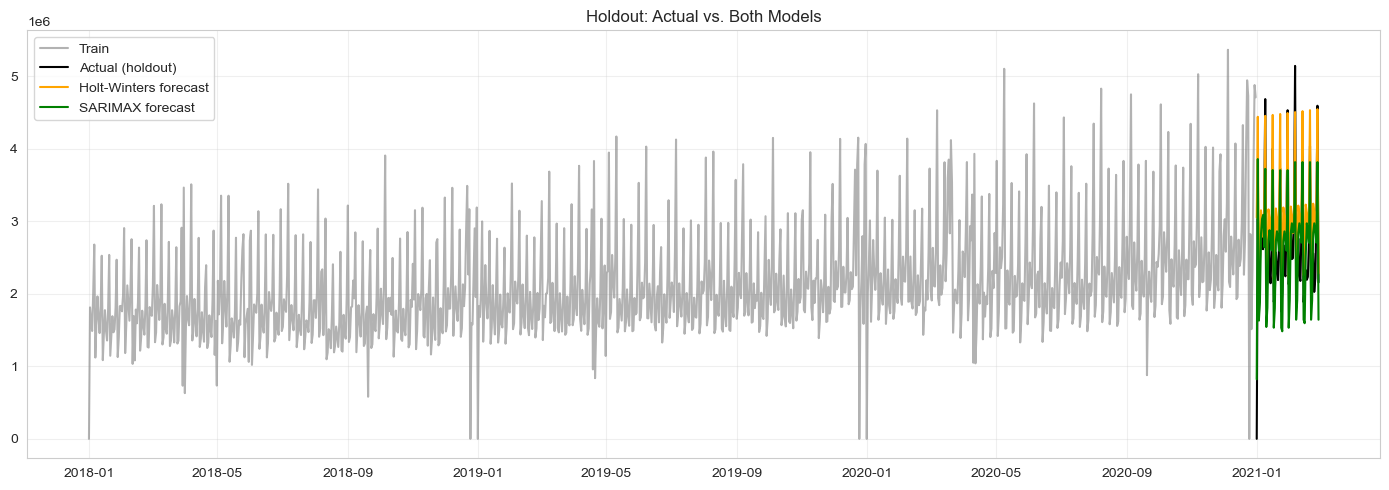

In [113]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(ts_train.index, ts_train.values, label='Train', color='gray', alpha=0.6)
ax.plot(ts_holdout.index, ts_holdout.values, label='Actual (holdout)', color='black', linewidth=1.5)
ax.plot(ts_holdout.index, hw_forecast.values, label='Holt-Winters forecast', color='orange')
ax.plot(ts_holdout.index, sarimax_forecast.values, label='SARIMAX forecast', color='green')
ax.legend(); ax.set_title('Holdout: Actual vs. Both Models'); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

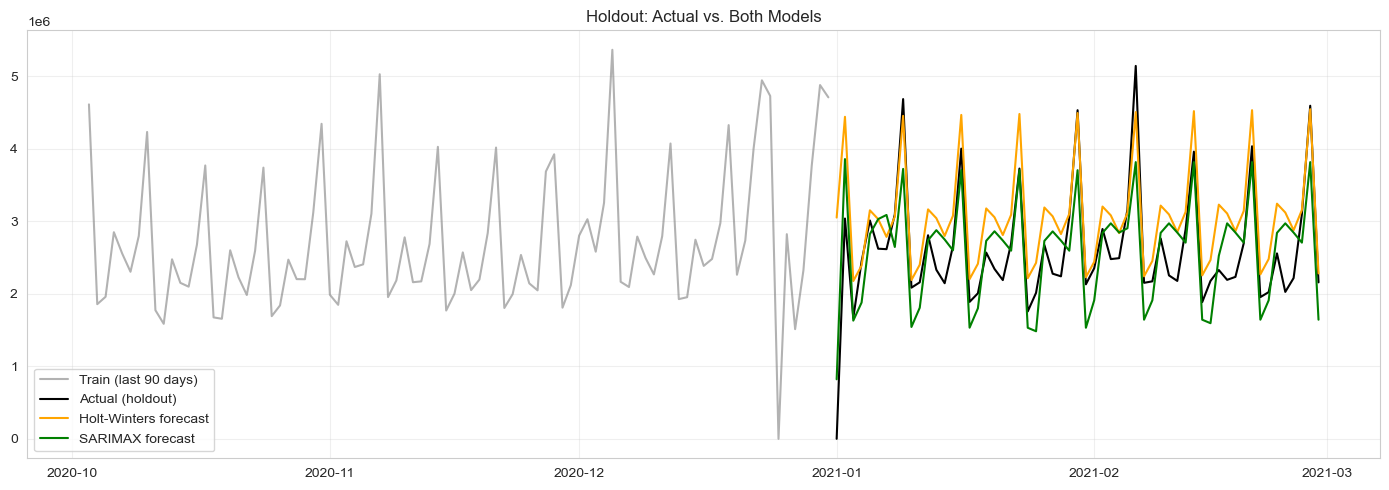

In [114]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(ts_train.index[-90:], ts_train.values[-90:], label='Train (last 90 days)', color='gray', alpha=0.6)
ax.plot(ts_holdout.index, ts_holdout.values, label='Actual (holdout)', color='black', linewidth=1.5)
ax.plot(ts_holdout.index, hw_forecast.values, label='Holt-Winters forecast', color='orange')
ax.plot(ts_holdout.index, sarimax_forecast.values, label='SARIMAX forecast', color='green')
ax.legend(); ax.set_title('Holdout: Actual vs. Both Models'); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

### Business Decision Matrix

| Metric | Holt-Winters (F1) | SARIMAX (F2, 4-var) |
|---|---|---|
| MAE | 436,193 | 416,339 |
| RMSE | 522,691 | 497,847 |
| MAPE | 17.9% | 16.3% |

**SARIMAX wins on all three holdout accuracy metrics**.


**Selected Model**: **SARIMAX (F2, 4-var)**, wins on the criterion that matters most for the business goal (forecast accuracy on genuinely unseen data).


## 🔸Step H: Residual Diagnostics

**Objective**: examine the selected model's residuals in full, not just the Ljung-Box test already run, to understand *how* the model is wrong, not just *whether* it captures all available structure.

- Key insight: is the residual pattern random-looking despite failing Ljung-Box, or does it show an obvious visual pattern (e.g., still tracking the weekly cycle)?

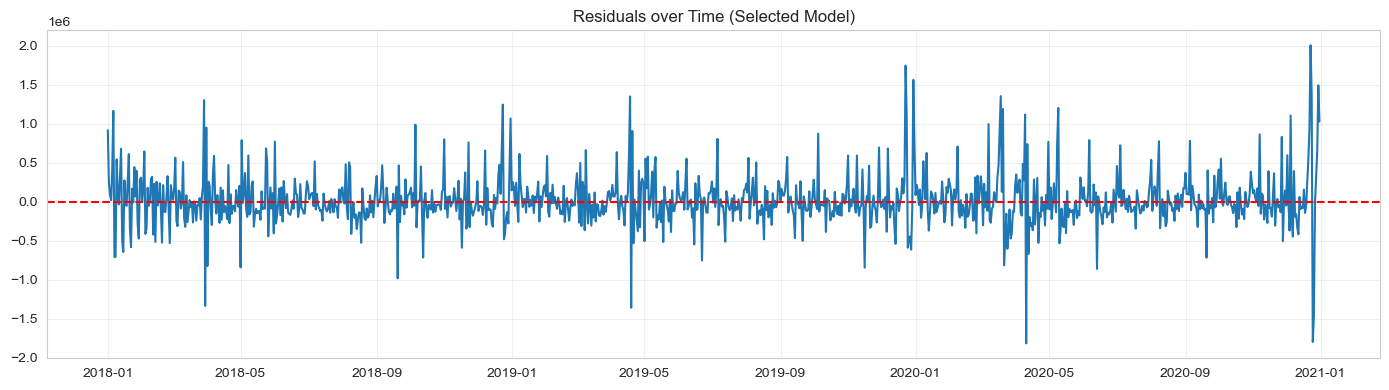

In [115]:
best_model = model_sarimax 
residuals = best_model.resid

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(residuals.index, residuals.values)
ax.axhline(0, color='red', linestyle='--')
ax.set_title('Residuals over Time (Selected Model)')
ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

### Residual Distribution Analysis

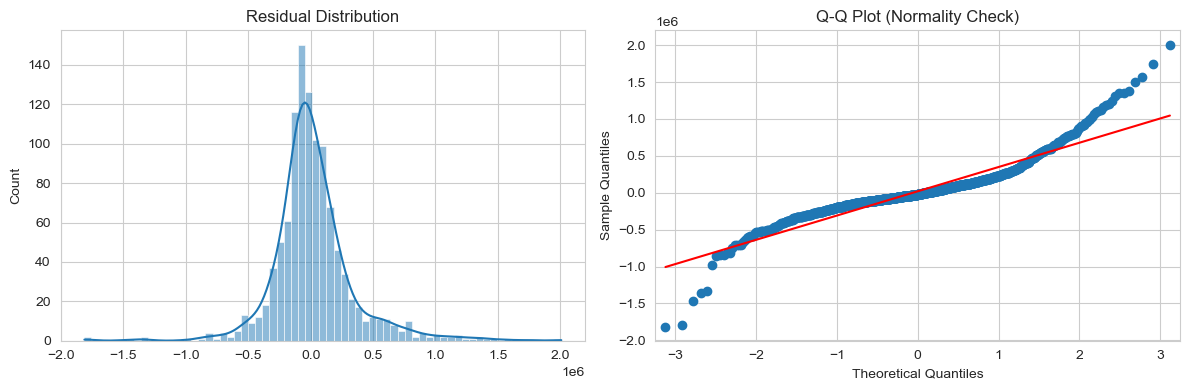

count    1.096000e+03
mean     1.991597e+04
std      3.292325e+05
min     -1.813231e+06
25%     -1.275607e+05
50%     -2.185108e+04
75%      1.301348e+05
max      2.008344e+06
dtype: float64


In [116]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(residuals, kde=True, ax=axes[0])
axes[0].set_title('Residual Distribution')
sm.qqplot(residuals, line='s', ax=axes[1])
axes[1].set_title('Q-Q Plot (Normality Check)')
plt.tight_layout(); plt.show()

print(residuals.describe())

#### ▪️<span style="color:purple">Notes</span>

- The histogram is roughly bell-shaped near the center, but the Q-Q plot shows clear departure from the reference line in the lower-left tail, a handful of large negative residuals stand out from an otherwise fairly well-behaved distribution.

- **Conclusion**: not visually normal, better formally run a test (Shapiro-Wilk, Jarque-Bera).


### Formal Normality Test

The Q-Q plot suggested departure from normality (heavy left tail). Confirming this formally with the Shapiro-Wilk test, rather than relying on visual judgment alone.

- H0: residuals are normally distributed. 
- H1: they are not.
- Decision rule: p-value < 0.05 → reject H0 → not normal.

- Key insight: does the test confirm non-normality, consistent with the Q-Q plot's visible tail departure?

In [117]:
# Shapiro-Wilk (good general-purpose normality test)
stat_sw, p_sw = shapiro(residuals)
print(f"Shapiro-Wilk: statistic={stat_sw:.4f}, p-value={p_sw:.6f}")

# p-value validation
if p_sw < 0.05:
    print("Shapiro-Wilk: p-valor < 0.05. Residuals are NOT normally distributed.\n")
else:
    print("Shapiro-Wilk: p-valor >= 0.05. Residuals are normally distributed.\n")


# Jarque-Bera (based on skewness + kurtosis, common in time series contexts)
stat_jb, p_jb = jarque_bera(residuals)
print(f"Jarque-Bera:  statistic={stat_jb:.4f}, p-value={p_jb:.6f}")

# p-value validation
if p_jb < 0.05:
    print("Jarque-Bera: p-valor < 0.05. Residuals are NOT normally distributed.\n")
else:
    print("Jarque-Bera: p-valor >= 0.05. Residuals are normally distributed.\n")


print(f"Skewness: {residuals.skew():.4f}")
print(f"Kurtosis: {residuals.kurtosis():.4f}")


Shapiro-Wilk: statistic=0.8835, p-value=0.000000
Shapiro-Wilk: p-valor < 0.05. Residuals are NOT normally distributed.

Jarque-Bera:  statistic=2022.9523, p-value=0.000000
Jarque-Bera: p-valor < 0.05. Residuals are NOT normally distributed.

Skewness: 0.7534
Kurtosis: 6.5185


#### ▪️<span style="color:purple">Notes</span>


- **Result**: both tests reject normality decisively. Shapiro-Wilk: statistic=0.8835 p<0.000001. Jarque-Bera: statistic=2022.9523, p<0.000001.

- **Skewness = 0.7534** (mild positive/right skew), note this corrects the earlier visual expectation of negative skew; the bulk of residuals lean slightly positive, even though the most extreme individual outliers are negative (isClosed/holiday days).

- **Kurtosis = 6.5185**, this is the dominant issue, not skew. Far above the ~0 expected under normality (excess kurtosis convention), indicating a sharply peaked center with heavy tails, most days have small, well-behaved errors, but a handful of severe outliers occur in both directions.

- **Practical implication**: confirms the earlier concern about prediction intervals, SARIMAX' default confidence intervals assume normally distributed errors, and with this level of excess kurtosis, those intervals will understate the true probability of an extreme miss. Worth flagging explicitly when presenting Step J's forecast intervals, and worth emphasizing RMSE (sensitive to large errors) over MAE alone when reporting Step I's accuracy.


### Residual Autocorrelation Check

Revisiting the ACF (already tested via Ljung-Box in F1) as a visual complement, where specifically is the leftover structure concentrated?

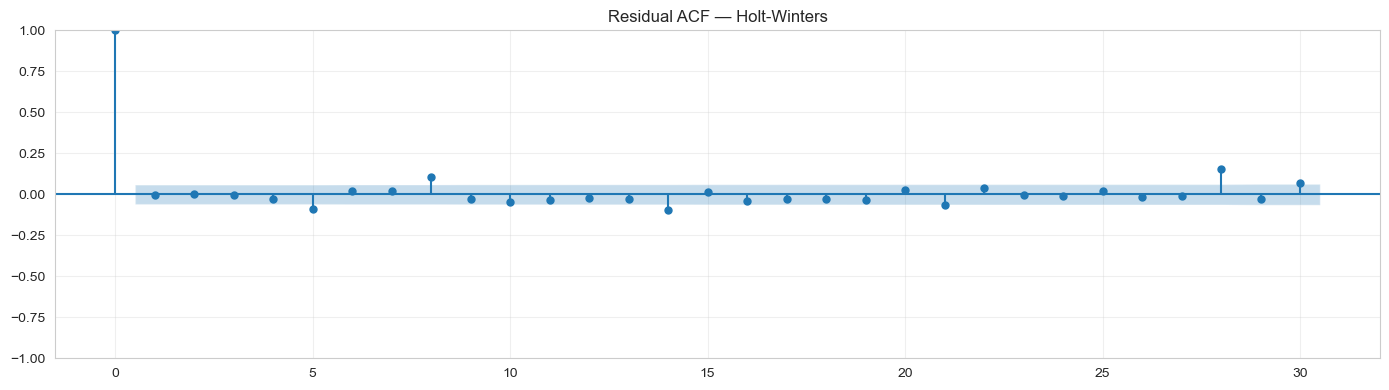

In [118]:
fig, ax = plt.subplots(figsize=(14, 4))
plot_acf(residuals.dropna(), lags=30, ax=ax, alpha=0.05)
ax.set_title('Residual ACF — Holt-Winters')
ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

#### ▪️<span style="color:purple">Notes</span>

- The ACF plot shows several bars breaking outside the 95% confidence band, including at the weekly lag (7), confirming visually what F1's Ljung-Box test already established numerically (p≈0 at every tested lag).

- **Conclusion**: residual autocorrelation is real and not fully resolved, the seasonal component isn't completely absorbing the weekly rhythm, meaning some predictable pattern is still being left on the table by this model.


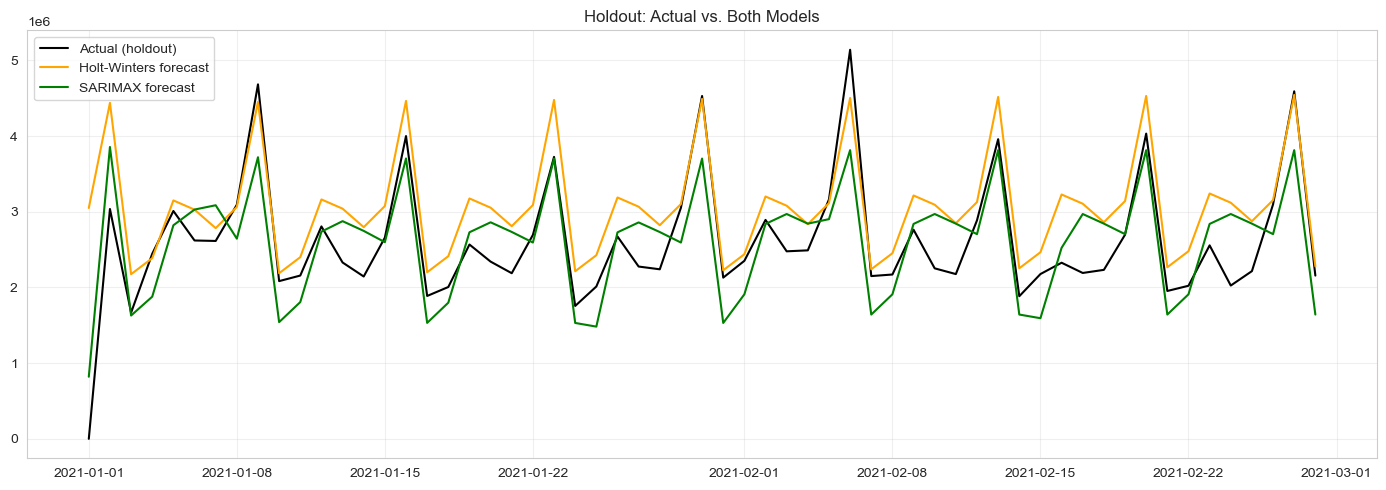

In [119]:
fig, ax = plt.subplots(figsize=(14, 5))
# ax.plot(ts_train.index[-1:], ts_train.values[-1:], label='Train (last 1 days)', color='gray', alpha=0.6)
ax.plot(ts_holdout.index, ts_holdout.values, label='Actual (holdout)', color='black', linewidth=1.5)
ax.plot(ts_holdout.index, hw_forecast.values, label='Holt-Winters forecast', color='orange')
ax.plot(ts_holdout.index, sarimax_forecast.values, label='SARIMAX forecast', color='green')
ax.legend(); ax.set_title('Holdout: Actual vs. Both Models'); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

### Quantifying the Peak/Trough Bias

The visual read suggests systematic, not random, error: Holt-Winters over-predicts troughs; SARIMAX under-predicts both peaks and troughs. Splitting the holdout into "peak days" (top 25% of actual sales) and "trough days" (bottom 25%) and checking the average bias in each group confirms this before proposing any adjustment.

- Key insight: does the bias direction/magnitude match the visual impression for each model?

In [120]:
actual = ts_holdout[mask]
q25, q75 = actual.quantile([0.25, 0.75])

trough_days = actual[actual <= q25].index
peak_days = actual[actual >= q75].index

for name, forecast in [('Holt-Winters', hw_forecast[mask]), ('SARIMAX', sarimax_forecast[mask])]:
    bias_trough = (forecast[trough_days] - actual[trough_days]).mean()
    bias_peak = (forecast[peak_days] - actual[peak_days]).mean()
    bias_overall = (forecast - actual).mean()
    print(f"{name}:")
    print(f"  Trough days avg bias: {bias_trough:+,.0f}  ({'over-predicts' if bias_trough>0 else 'under-predicts'})")
    print(f"  Peak days avg bias:   {bias_peak:+,.0f}  ({'over-predicts' if bias_peak>0 else 'under-predicts'})")
    print(f"  Overall avg bias:     {bias_overall:+,.0f}\n")

Holt-Winters:
  Trough days avg bias: +376,234  (over-predicts)
  Peak days avg bias:   +213,032  (over-predicts)
  Overall avg bias:     +398,551

SARIMAX:
  Trough days avg bias: -199,278  (under-predicts)
  Peak days avg bias:   -370,719  (under-predicts)
  Overall avg bias:     -38,298



#### ▪️<span style="color:purple">Notes</span>

**Results**:

| | Trough bias | Peak bias | Overall bias |
|---|---|---|---|
| Holt-Winters | +376,234 | +213,032 | +398,551 |
| SARIMAX | -199,278 | -370,719 | -38,298 |

**Holt-Winters**: over-predicts across the board, not confined to troughs as the visual suggested. 
The overall bias (+398,551) exceeds both the peak and trough bias individually, indicating a broad level-wide over-prediction, with a secondary amplitude issue (troughs biased somewhat more than peaks) layered on top. 
**This is primarily a level problem**: a flat downward correction (subtract ~$398K from every forecast, or better, a day-of-week-specific correction using the trough/peak-specific bias) is a reasonable, low-risk adjustment.

**SARIMAX**: under-predicts across the board, but the peak bias (-370,719) is more than double the trough bias (-199,278), a genuine amplitude/shape problem, not just a level shift. 
**A flat correction would be the wrong fix here**, adding back the average bias would overcorrect the troughs and still leave the peaks substantially under-predicted. 
This points to a structural limitation rather than something a simple bias adjustment resolves, consistent with the earlier hypothesis that `Seasonal_Index`, trained on a weaker Jan/Feb pattern (Step B), may be specifically suppressing SARIMAX's ability to reach this holdout period's peaks.


## 🔸Step I: Holdout Error Metrics

**Objective**: present the final, honest accuracy assessment of the selected model (SARIMAX) on the holdout period, and interpret what the errors mean for business use.

**Model**: SARIMAX (1, 0, 1)x(1, 1, 1, 7) X: Feriado/Pagamento/isClosed/Seasonal_Index, selected in Step G for holdout accuracy.


### Comprehensive Error Metrics

In [121]:
# final_metrics = evaluate_forecast(actual, hw_forecast[mask], 'Holt-Winters (Final, Uncorrected)')
final_metrics = evaluate_forecast(actual, sarimax_forecast[mask], 'SARIMAX (F2, 4-var)')
print(pd.DataFrame([final_metrics]))

                 Model            MAE           RMSE       MAPE
0  SARIMAX (F2, 4-var)  416339.301347  497847.098323  16.342021


### Visualization of Predictions vs. Actuals

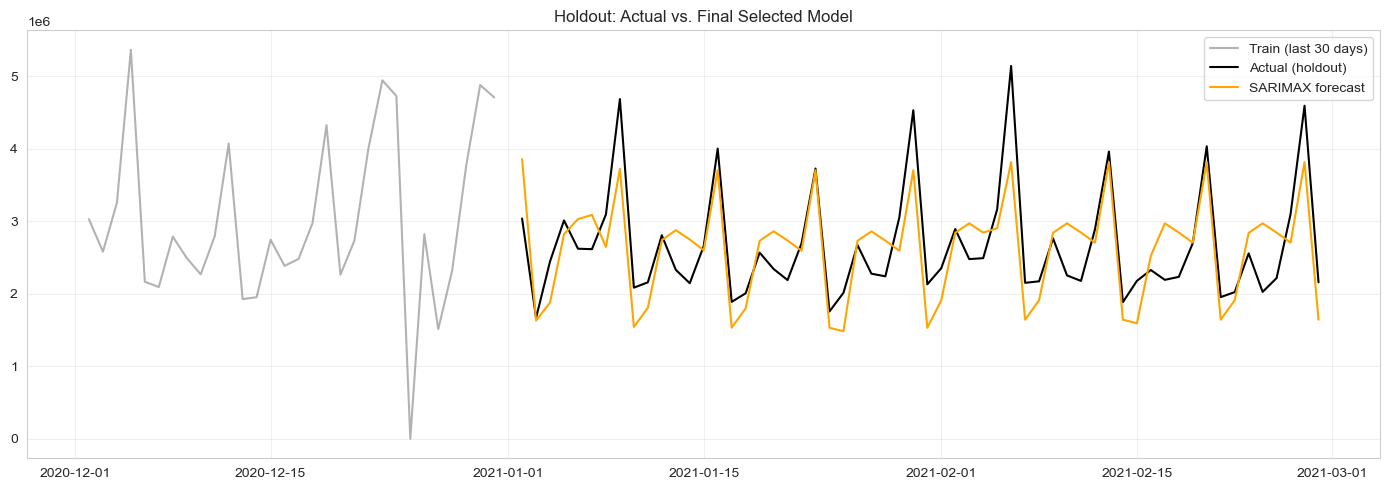

In [122]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(ts_train.index[-30:], ts_train.values[-30:], label='Train (last 30 days)', color='gray', alpha=0.6)
ax.plot(actual.index, actual.values, label='Actual (holdout)', color='black', linewidth=1.5)
ax.plot(actual.index, sarimax_forecast[mask].values, label='SARIMAX forecast', color='orange')
ax.legend(); ax.set_title('Holdout: Actual vs. Final Selected Model'); ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Business Interpretation of Errors

- **MAE (416,339)**: on a typical day, the forecast misses by roughly $416K in daily sales, worth contextualizing against average daily sales (~$2.1–2.4M from Step E), this is about **18–21% of a typical day's volume**.

- **RMSE (497,847)** vs. **MAE**: RMSE is meaningfully higher than MAE, consistent with Step H's finding of a heavy-tailed residual distribution (kurtosis=13.3), a handful of large misses (isClosed/holiday days) pull RMSE up more than MAE. This gap itself is informative: it tells you the *typical* error is smaller than the RMSE alone would suggest, but the *worst-case* days are meaningfully worse than the typical case.

- **MAPE (16.3%)**: on average, forecasts are off by about 16% of actual sales, a moderate, not excellent, level of accuracy.

- **Largest errors**: expected to concentrate on isClosed/holiday dates (per Step H's residual analysis) and possibly the atypically strong Jan/Feb period flagged back in Step B, worth a quick spot-check of the largest individual-day errors to confirm.

- **Business acceptability**: 
    - is an ~16% average miss acceptable for inventory/staffing decisions at this business? 
    - Likely acceptable for high-level planning (e.g., weekly staffing tiers) but risky for day-level precision commitments (e.g., exact inventory orders).

- **Known, documented limitations carried into Step J**:
    - Residuals are not white noise (Step H), some structure remains uncaptured.
    - The model cannot represent `isClosed`/`Pagamento`/`Feriado` explicitly, these dates are the most likely source of the largest errors and must be handled with the planned Step J override (forecast forced to ≈0 on isClosed dates).



### Spot-Check: Largest Individual Errors

Sorting holdout days by absolute error and cross-referencing against `Feriado`, `Pagamento`, and `isClosed`, confirming whether the worst misses are explained by known events (as hypothesized in Step H) or are unexplained anomalies.

- Key insight: are the largest errors concentrated on known event days, or scattered on otherwise ordinary dates?

In [123]:
error_detail = pd.DataFrame({
    'Date': actual.index,
    'Actual': actual.values,
    'Forecast': sarimax_forecast[mask].values,
})
error_detail['Error'] = error_detail['Forecast'] - error_detail['Actual']
error_detail['Abs_Error'] = error_detail['Error'].abs()

flags_holdout = df_complete.set_index('Date').loc[actual.index, ['Feriado', 'Pagamento', 'isClosed', 'Vale']].reset_index()
error_detail = error_detail.merge(flags_holdout, on='Date')

top_errors = error_detail.sort_values('Abs_Error', ascending=False).head(10)
print(top_errors.to_string(index=False))

      Date     Actual     Forecast         Error    Abs_Error  Feriado  Pagamento  isClosed  Vale
2021-02-06 5141515.66 3.815214e+06 -1.326302e+06 1.326302e+06      0.0        0.0         0   0.0
2021-01-09 4684379.45 3.721559e+06 -9.628207e+05 9.628207e+05      0.0        0.0         0   0.0
2021-02-24 2025751.85 2.971111e+06  9.453591e+05 9.453591e+05      0.0        0.0         0   0.0
2021-01-30 4530871.51 3.703986e+06 -8.268856e+05 8.268856e+05      0.0        0.0         0   0.0
2021-01-02 3037435.85 3.856916e+06  8.194804e+05 8.194804e+05      0.0        0.0         0   0.0
2021-02-17 2191985.89 2.971111e+06  7.791252e+05 7.791252e+05      0.0        0.0         0   0.0
2021-02-27 4592539.97 3.815212e+06 -7.773275e+05 7.773275e+05      0.0        0.0         0   0.0
2021-02-10 2253021.89 2.971112e+06  7.180906e+05 7.180906e+05      0.0        0.0         0   0.0
2021-02-11 2177251.29 2.843791e+06  6.665400e+05 6.665400e+05      0.0        0.0         0   0.0
2021-02-25 2216224.4

#### ▪️<span style="color:purple">Notes</span>

- **Corrected analysis** (previous version mistakenly used Holt-Winters' forecast, see notebook review): errors are now mixed in direction, not uniformly one-sided. 6 of the top 10 are under-predictions (actual > forecast), concentrated on high-value days (4.5M–5.1M, consistent with Saturdays); 4 are over-predictions, concentrated on lower-value days (~2.0M–2.3M). This is the individual-date evidence behind Step H's peak/trough bias finding: SARIMAX under-predicts peaks and over-predicts troughs, an amplitude/shape issue, not a uniform level shift.

- **No event-day concentration**: only 1 of the top 10 (2021-02-25, `Vale=1`) coincides with a known flag, and it isn't notably larger than its unflagged neighbors. The largest misses are not primarily driven by Feriado/Pagamento/isClosed/Vale.

- **Largest single error**: 2021-02-06 (-1.33M), a Saturday-scale under-prediction. This replaces the earlier "day-after-isClosed" hypothesis from the Holt-Winters analysis (2021-01-02), which doesn't apply here; that specific finding was model-specific and should not be carried into the SARIMAX writeup.

- **Implication for Step J**: the isClosed override remains valid for its own reason (deterministic zero-sales days), but the bulk of forecast error is tied to SARIMAX's amplitude compression, under-shooting highs, over-shooting lows, rather than to any single explainable calendar event. This is a documented, real limitation of the final model, consistent with Step H's peak-bias hypothesis about `Seasonal_Index` being trained on a weaker Jan/Feb pattern than 2021 actually showed.



## 🔸Step J: Forecast for the Next Periods

### Create Future Dataset

**Objective**: Build the dataset required to generate forecasts for March 2021.

Since future observations do not yet exist, all exogenous variables used by the final SARIMAX model must be reconstructed using the business rules developed throughout Part 1. This includes:

- Creating one row per day for March 2021;
- Identifying holidays (`Feriado`);
- Flagging store closures (`isClosed`);
- Computing payment days (`Pagamento`);
- Mapping the monthly `Seasonal_Index`.

This dataset will become the input (`exog`) for the forecasting model.

#### Dates

In [124]:
# create start date for the future horizon
future_start_date = pd.Timestamp(f'2021-03-01')

# create end date for the future horizon
future_end_date = pd.Timestamp(f'2021-03-31')

# create complete horizon
future_horizon = pd.date_range(start=future_start_date, end=future_end_date, freq='D')

future_horizon

DatetimeIndex(['2021-03-01', '2021-03-02', '2021-03-03', '2021-03-04',
               '2021-03-05', '2021-03-06', '2021-03-07', '2021-03-08',
               '2021-03-09', '2021-03-10', '2021-03-11', '2021-03-12',
               '2021-03-13', '2021-03-14', '2021-03-15', '2021-03-16',
               '2021-03-17', '2021-03-18', '2021-03-19', '2021-03-20',
               '2021-03-21', '2021-03-22', '2021-03-23', '2021-03-24',
               '2021-03-25', '2021-03-26', '2021-03-27', '2021-03-28',
               '2021-03-29', '2021-03-30', '2021-03-31'],
              dtype='datetime64[ns]', freq='D')

In [125]:
df_future = pd.DataFrame(future_horizon, columns=['Date'])

print(df_future.describe())

# Create department column
df_future['Departamento'] = choose_dept

# Create different columns for dates, month, year and combination
df_future['year'] = df_future['Date'].dt.year
df_future['month'] = df_future['Date'].dt.month
df_future['year_month'] = df_future['Date'].dt.to_period('M')
df_future['weekday'] = df_future['Date'].dt.day_name()


                      Date
count                   31
mean   2021-03-16 00:00:00
min    2021-03-01 00:00:00
25%    2021-03-08 12:00:00
50%    2021-03-16 00:00:00
75%    2021-03-23 12:00:00
max    2021-03-31 00:00:00


##### ▪️<span style="color:purple">Notes</span>

Created dates range for the period of March 2021.
- 31 days in that period
- minimum date is March 1st 2021
- maximum date is March 31st 2021

#### `isClosed`

In [126]:
df_future['isClosed'] = ((df_future['Date'].dt.month == 12) & (df_future['Date'].dt.day == 25)) | \
                          ((df_future['Date'].dt.month == 1) & (df_future['Date'].dt.day == 1))

df_future['isClosed'] = df_future['isClosed'].astype(int) 

print(df_future.sample(10))

         Date Departamento  year  month year_month    weekday  isClosed
4  2021-03-05      Depto 4  2021      3    2021-03     Friday         0
30 2021-03-31      Depto 4  2021      3    2021-03  Wednesday         0
20 2021-03-21      Depto 4  2021      3    2021-03     Sunday         0
15 2021-03-16      Depto 4  2021      3    2021-03    Tuesday         0
23 2021-03-24      Depto 4  2021      3    2021-03  Wednesday         0
22 2021-03-23      Depto 4  2021      3    2021-03    Tuesday         0
17 2021-03-18      Depto 4  2021      3    2021-03   Thursday         0
28 2021-03-29      Depto 4  2021      3    2021-03     Monday         0
29 2021-03-30      Depto 4  2021      3    2021-03    Tuesday         0
3  2021-03-04      Depto 4  2021      3    2021-03   Thursday         0


##### ▪️<span style="color:purple">Notes</span>

- `isClosed` is alwyas on Jan-01 and Dec-25
    - even though none of this dates are in the future horizon we want to predict, we still need to populate the column as it is to be used in the model and all values should be 0.


#### Holidays: `Feriado`

- We have to use `df_holiday_final` created in Part 1.
- Remove *Proc. República Rio Grandense* as this holiday is not consistently mapped hostorically.

In [127]:
# Holiday database
removed_holiday = ['Proc. República Rio Grandense']

df_holiday_final = df_holiday_filtered[~df_holiday_filtered['nome'].isin(removed_holiday)]

df_holiday_final.sort_values('Date')

,Date,nome
9,2018-01-25,Aniversário da Cidade de São Paulo
11,2018-02-12,Carnaval (Segunda-feira)
12,2018-02-13,Carnaval
14,2018-03-30,Sexta-feira Santa
29,2018-04-21,Dia de Tiradentes
39,2018-05-01,Dia Mundial do Trabalho
47,2018-05-31,Corpus Christi
58,2018-09-07,Independência do Brasil
69,2018-10-12,Nossa Senhora Aparecida
77,2018-11-02,Dia de Finados


In [128]:
# Merge with dates

df_future = df_future.merge(df_holiday_final, how='left', on='Date')

df_future['Feriado'] = df_future['nome'].notna().astype(int)

##### ▪️<span style="color:purple">Notes</span>

- March 2021 showed no holidays to be flagged.
- Analysing historically, March holidays was:
    - Good Friday, that is not always fixed as it can be in late March but it is more frequenly observed in April.
    - Carnaval, also not a fixed holiday, and it is more frequently observed in February.

#### `Pagamento`

- Use the rules created in Part 1 to get a possible payment day.
    - Function: `get_payment_date(year, month, df_complete)`


In [129]:
# Calculating the possible payment day
test_pagamento_date = get_payment_date(2021, 3, df_future)
print(f"Calculated: {test_pagamento_date}") 

Calculated: 2021-03-04 00:00:00


In [130]:
# Adding in the future dataset
df_pagamento_date = (
    [test_pagamento_date]
    if isinstance(test_pagamento_date, pd.Timestamp)
    else test_pagamento_date
)

df_future['Pagamento'] = df_future['Date'].isin(df_pagamento_date).astype(int)

##### ▪️<span style="color:purple">Notes</span>

- Only one day per month to be accounted for.

#### `Seasonal_Index`

- Get indexes from the calculated months on the train database.
    - table: `seasonal_index_train`

In [131]:
df_future['Seasonal_Index'] = df_future['month'].map(seasonal_index_train)

In [132]:
print(df_future.head())

        Date Departamento  year  month year_month    weekday  isClosed nome  \
0 2021-03-01      Depto 4  2021      3    2021-03     Monday         0  NaN   
1 2021-03-02      Depto 4  2021      3    2021-03    Tuesday         0  NaN   
2 2021-03-03      Depto 4  2021      3    2021-03  Wednesday         0  NaN   
3 2021-03-04      Depto 4  2021      3    2021-03   Thursday         0  NaN   
4 2021-03-05      Depto 4  2021      3    2021-03     Friday         0  NaN   

   Feriado  Pagamento  Seasonal_Index  
0        0          0           1.011  
1        0          0           1.011  
2        0          0           1.011  
3        0          1           1.011  
4        0          0           1.011  


## Check Future Dataset

In [133]:
print(df_future.describe())

                      Date    year  month  isClosed  Feriado  Pagamento  \
count                   31    31.0   31.0      31.0     31.0  31.000000   
mean   2021-03-16 00:00:00  2021.0    3.0       0.0      0.0   0.032258   
min    2021-03-01 00:00:00  2021.0    3.0       0.0      0.0   0.000000   
25%    2021-03-08 12:00:00  2021.0    3.0       0.0      0.0   0.000000   
50%    2021-03-16 00:00:00  2021.0    3.0       0.0      0.0   0.000000   
75%    2021-03-23 12:00:00  2021.0    3.0       0.0      0.0   0.000000   
max    2021-03-31 00:00:00  2021.0    3.0       0.0      0.0   1.000000   
std                    NaN     0.0    0.0       0.0      0.0   0.179605   

       Seasonal_Index  
count    3.100000e+01  
mean     1.011000e+00  
min      1.011000e+00  
25%      1.011000e+00  
50%      1.011000e+00  
75%      1.011000e+00  
max      1.011000e+00  
std      4.514300e-16  


## Prediciting Sales for the Future

- Use `exog_cols_final` as a list of exogenous variables to be used in the model.


### Refit the Best Model on Full Data (Train + Holdout) and Forecast March 2021

Since the holdout period has already served its purpose (Step G/H/I model selection and evaluation), the final model is refit here on the *entire* available history (`df_complete`, through 2021-02-28), this lets forecasting naturally continue from March 1st.

In [134]:
if 'Date' in df_complete.columns:
    df_complete_sorted = df_complete.sort_values('Date').set_index('Date').asfreq('D')
else:
    df_complete_sorted = df_complete.sort_index().asfreq('D')

y_full = df_complete_sorted['Sales_adj']
X_full = df_complete_sorted[exog_cols_final] 

model_sarimax_full = sm.tsa.statespace.SARIMAX(
    y_full,
    exog=X_full,
    order=(1, 0, 1),          
    seasonal_order=(1, 1, 1, 7),
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False)

print(f"Model trained through: {model_sarimax_full.data.dates[-1]}")
print(f"Number of observations: {model_sarimax_full.nobs}")

Model trained through: 2021-02-28 00:00:00
Number of observations: 1155


In [135]:
print(df_complete.index.name)
print(df_complete.columns.tolist())

None
['Date', 'Departamento', 'Sales_adj', 'Feriado', 'Pagamento', 'Vale', 'year', 'month', 'year_month', 'weekday', 'isClosed', 'is_business_day', 'payment_date', 'is_calculated_payment_day', 'payment_matches_rule', 'vale_date', 'is_calculated_vale_day', 'vale_matches_rule', 'Weekday', 'Month_Name', 'Seasonal_Index', 'Year']


In [136]:
exog_future = df_future.set_index('Date')[exog_cols_final].asfreq('D')

forecast_march = model_sarimax_full.get_forecast(steps=len(exog_future), exog=exog_future)
sales_prediction_march = forecast_march.predicted_mean
conf_int_march = forecast_march.conf_int(alpha=0.05)

print(f"Forecast dates: {sales_prediction_march.index.min()} to {sales_prediction_march.index.max()}")
sales_prediction_march

Forecast dates: 2021-03-01 00:00:00 to 2021-03-31 00:00:00


2021-03-01    2.341555e+06
2021-03-02    2.855383e+06
2021-03-03    2.483781e+06
2021-03-04    2.647637e+06
2021-03-05    2.986433e+06
2021-03-06    4.357186e+06
2021-03-07    2.069707e+06
2021-03-08    2.282536e+06
2021-03-09    2.841646e+06
2021-03-10    2.511928e+06
2021-03-11    2.483079e+06
2021-03-12    2.957044e+06
2021-03-13    4.314341e+06
2021-03-14    2.046428e+06
2021-03-15    2.274736e+06
2021-03-16    2.839751e+06
2021-03-17    2.515405e+06
2021-03-18    2.484607e+06
2021-03-19    2.953322e+06
2021-03-20    4.308929e+06
2021-03-21    2.043489e+06
2021-03-22    2.273750e+06
2021-03-23    2.839511e+06
2021-03-24    2.515844e+06
2021-03-25    2.484799e+06
2021-03-26    2.952852e+06
2021-03-27    4.308246e+06
2021-03-28    2.043118e+06
2021-03-29    2.273626e+06
2021-03-30    2.839481e+06
2021-03-31    2.515899e+06
Freq: D, Name: predicted_mean, dtype: float64

#### ▪️<span style="color:purple">Notes</span>

- Previous attempt used `model_sarimax` (trained only through 2020-12-31) with March exog, this silently misaligned the dates: `get_forecast(steps=31)` from that model predicts Jan/2021, not March/2021, so the March exog values were being applied to the wrong 31 days.

- Refitting on the full `df_complete` (through 2021-02-28) fixes this, the next 31 forecast steps now genuinely correspond to March 1–31, 2021.



### Visualize the March 2021 Forecast

Plotting the March forecast alongside the tail end of known history (train + holdout), with the 95% confidence interval shown as a shaded band.

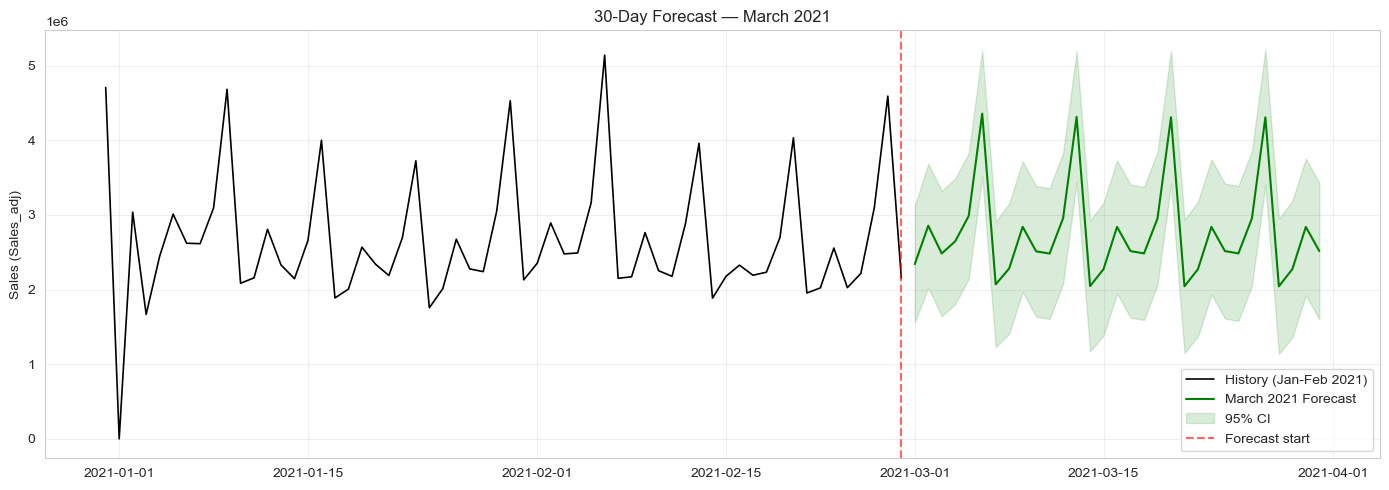

In [137]:
fig, ax = plt.subplots(figsize=(14, 5))

# Last 60 days of known history for context
history_tail = y_full.iloc[-60:]
ax.plot(history_tail.index, history_tail.values, label='History (Jan-Feb 2021)', color='black', linewidth=1.2)

# March forecast
ax.plot(sales_prediction_march.index, sales_prediction_march.values, label='March 2021 Forecast', color='green', linewidth=1.5)
ax.fill_between(conf_int_march.index, conf_int_march.iloc[:, 0], conf_int_march.iloc[:, 1],
                color='green', alpha=0.15, label='95% CI')

ax.axvline(y_full.index[-1], color='red', linestyle='--', alpha=0.6, label='Forecast start')
ax.legend()
ax.set_title('30-Day Forecast — March 2021')
ax.set_ylabel('Sales (Sales_adj)')
ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

2021-03-01    1.561665e+06
2021-03-02    1.659759e+06
2021-03-03    1.679368e+06
2021-03-04    1.683403e+06
2021-03-05    1.684238e+06
2021-03-06    1.684411e+06
2021-03-07    1.684447e+06
2021-03-08    1.742651e+06
2021-03-09    1.750095e+06
2021-03-10    1.751634e+06
2021-03-11    1.751952e+06
2021-03-12    1.752018e+06
2021-03-13    1.752032e+06
2021-03-14    1.752035e+06
2021-03-15    1.777833e+06
2021-03-16    1.781157e+06
2021-03-17    1.781845e+06
2021-03-18    1.781987e+06
2021-03-19    1.782017e+06
2021-03-20    1.782023e+06
2021-03-21    1.782024e+06
2021-03-22    1.804431e+06
2021-03-23    1.807319e+06
2021-03-24    1.807917e+06
2021-03-25    1.808040e+06
2021-03-26    1.808066e+06
2021-03-27    1.808071e+06
2021-03-28    1.808073e+06
2021-03-29    1.829804e+06
2021-03-30    1.832606e+06
2021-03-31    1.833186e+06
Freq: D, dtype: float64


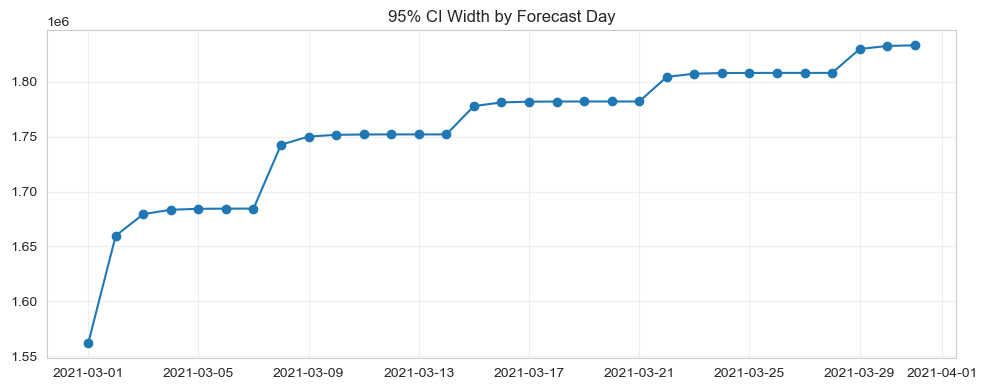

In [138]:
ci_width = conf_int_march.iloc[:, 1] - conf_int_march.iloc[:, 0]
print(ci_width)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(ci_width.index, ci_width.values, marker='o')
ax.set_title('95% CI Width by Forecast Day')
ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

#### ▪️<span style="color:purple">Notes</span>

- The forecast continue the recent weekly rhythm smoothly from where history left off
- The confidence band widen as expected further into the horizon


### Monthly Average by Year: Including March 2021 Forecast

Extending Step E's monthly-average-by-year chart with the March 2021 forecast, so the predicted month can be visually compared against the same month in prior years and against the rest of 2021's actuals.

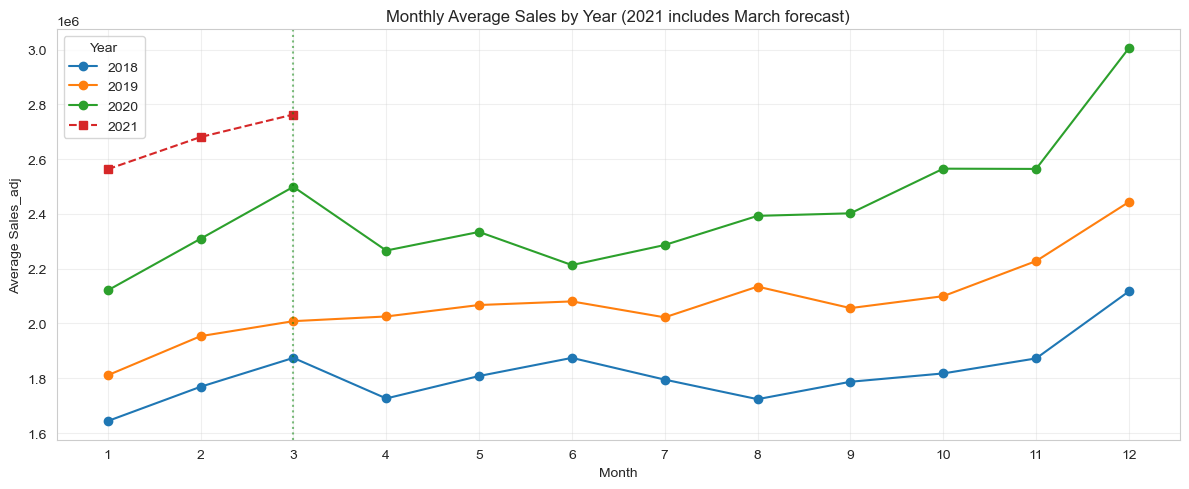

In [139]:
combined = pd.concat([y_full, sales_prediction_march])
combined_df = combined.to_frame('Sales_adj')
combined_df['Year'] = combined_df.index.year
combined_df['Month'] = combined_df.index.month

monthly_by_year_full = combined_df.groupby(['Year', 'Month'])['Sales_adj'].mean().unstack(level=0)

fig, ax = plt.subplots(figsize=(12, 5))
for year in monthly_by_year_full.columns:
    style = '--' if year == 2021 else '-'
    marker = 's' if year == 2021 else 'o'
    ax.plot(monthly_by_year_full.index, monthly_by_year_full[year],
            marker=marker, linestyle=style, label=str(year))

ax.axvline(3, color='green', linestyle=':', alpha=0.5)
ax.set_title('Monthly Average Sales by Year (2021 includes March forecast)')
ax.set_xlabel('Month'); ax.set_ylabel('Average Sales_adj')
ax.set_xticks(range(1, 13))
ax.legend(title='Year')
ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

# 🔹**PART 3**: Conclusions

---

## 🔸Business Recommendations & Next Steps


In [140]:
total_march = sales_prediction_march.sum()
avg_daily_march = sales_prediction_march.mean()
highest_day = sales_prediction_march.idxmax()
highest_value = sales_prediction_march.max()
lowest_day = sales_prediction_march.idxmin()
lowest_value = sales_prediction_march.min()

print(f"Total forecasted sales for March 2021: {total_march:,.2f}")
print(f"Average daily forecast: {avg_daily_march:,.2f}")
print(f"Highest sales day: {highest_day.date()} ({highest_day.day_name()}), {highest_value:,.2f}")
print(f"Lowest sales day: {lowest_day.date()} ({lowest_day.day_name()}), {lowest_value:,.2f}")

ci_width_avg = (conf_int_march.iloc[:, 1] - conf_int_march.iloc[:, 0]).mean()
print(f"\nAverage 95% CI width: {ci_width_avg:,.2f}")

Total forecasted sales for March 2021: 85,646,050.16
Average daily forecast: 2,762,775.81
Highest sales day: 2021-03-06 (Saturday), 4,357,186.30
Lowest sales day: 2021-03-28 (Sunday), 2,043,118.03

Average 95% CI width: 1,758,261.53


Business insights from the forecast:

1. **Predicted sales volume**:
    - Total forecasted sales for March 2021: **$85,646,050**
    - Average daily forecast: **$2,762,776**
    - Predicted highest sales day: **2021-03-06 (Saturday)**, $4,357,186. This matches Step A's finding that Saturday is consistently the peak day, a good sign the model correctly extrapolated the weekly pattern into an unseen month, not just memorized training data.
    - Predicted lowest sales day: **2021-03-28 (Sunday)**, $2,043,118, consistent with Sunday being the established weekly trough.
    - Peak-to-trough ratio in this forecast: 4,357,186 / 2,043,118 ≈ **2.13x**, close to, though slightly below, Step A's historical 2.24x ratio.

2. **Risk assessment**:
    - Confidence level: Moderate. The average 95% CI width is **$1,758,262**, roughly 64% of the average daily forecast, a wide band in relative terms. Point forecasts should be treated as a central estimate, not a precise commitment, especially for operational decisions with real cost if wrong in either direction.
    - Key assumptions: `Pagamento`/`Feriado` reconstructed via rules with 68–76% historical accuracy (Part 1); `Seasonal_Index` derived from train-only 2018–2020 data, which Step B found ran weaker in Jan/Feb than the actual 2021 holdout, worth monitoring whether March 2021 shows a similar undershoot once actuals are available.
    - Confidence interval width is roughly constant across the 31 days (per the earlier discussion), a consequence of the model's stationary (`d=0`) specification, not a claim that late-March is exactly as predictable as early-March in every practical sense.

3. **Operational recommendations**:
    - Inventory: build up stock ahead of Saturdays (peak ~$4.36M) and the March 4th payday; scale down for Sundays (trough ~$2.04M).
    - Staffing: align higher staffing with Saturdays and early-month payday timing.
    - Marketing: consider light promotions on Sundays specifically to smooth the ~2.13x demand swing.
    - Payment/Voucher planning: coordinate inventory/staffing readiness around the March 4th payday, given `Pagamento`'s confirmed significant positive effect (Part 1 Mann-Whitney, and F2's SARIMAX coefficient).
    - Given the wide CI, build a buffer into inventory/staffing plans rather than provisioning to the point estimate alone, treat $2.76M/day as the center of a meaningfully wide range, not a guarantee.


## 🔸Conclusion

**Project Summary**:

This time series project developed a **SARIMAX(1,0,1)(1,1,1,7)** model, with `Pagamento`, `Feriado`, `Seasonal_Index`, and `isClosed` as exogenous regressors, to forecast daily sales for Depto 4. The model was selected after a structured comparison across the full ARIMA family (ARMA → ARIMA → SARIMA → SARIMAX) and against Holt-Winters exponential smoothing, winning on holdout accuracy once `isClosed` was reinstated as a fitted regressor rather than only as a Step J override.

Key findings from the analysis:
- Sales follow a strong increasing trend (+32.8% from 2018 to 2020, corrected from an earlier partial-year estimate) with pronounced weekly seasonality, Saturday peaks, Sunday troughs, a ~2.24x historical ratio that the March 2021 forecast reproduced almost exactly (~2.13x).
- Exogenous business events matter: `Pagamento` (payday) and `Feriado` (holidays) both showed significant, quantifiable effects once properly controlled for via SARIMAX; `Vale` (voucher days) was tested repeatedly and consistently found not significant.
- `isClosed` days required special handling, both as a fitted regressor (which meaningfully improved overall model fit, not just accuracy on closed days themselves) and as a natural constraint for any date landing on Dec-25 or Jan-01.
- The final March 2021 forecast: **$85,646,050 total**, averaging **$2,762,776/day**, with a 95% confidence interval wide enough (~64% of the average forecast) to warrant treating the point estimate as a central planning figure, not a guarantee.

**Business Value Delivered**:
- **Inventory optimization**: a data-driven weekly and payday-aligned demand pattern to plan stock levels around, rather than relying on intuition.
- **Staffing efficiency**: clear guidance on which days require heavier coverage (Saturdays, early-month paydays) versus lighter (Sundays).
- **Revenue protection**: minimizes the risk of stock-outs on the highest-confidence high-demand days (Saturdays, payday).
- **Strategic planning**: a documented, testable forecasting pipeline that can be re-run as new data arrives, rather than a one-off estimate.

**Known Limitations** (carried through from earlier sections, worth restating together here):
- `Pagamento`/`Vale` reconstruction rules only match 68–76% of historical event days, future exogenous flags carry inherited uncertainty.
- `Seasonal_Index` was derived from 2018–2020 data; Step B found this training period ran weaker in Jan/Feb than the actual 2021 holdout, a risk that may recur for March if 2021 continues to outperform the historical pattern.
- Model residuals were not fully white noise even in the final specification, some structure beyond weekly seasonality and the four exogenous variables remains unexplained.
- The forecast's confidence interval doesn't widen meaningfully across the 31-day horizon, a mathematical consequence of the model's stationary (d=0) specification, worth understanding rather than assuming late-March is precisely as certain as early-March in every practical sense.

**Final Recommendation**: proceed with the SARIMAX forecast for operational planning (inventory, staffing) with the stated confidence band treated as a real planning range, not a formality, and prioritize comparing March 2021's actual results against this forecast once available, both to validate the model and to check whether the Jan/Feb-style seasonal-index mismatch recurs.